<a href="https://colab.research.google.com/github/9854945d/llm-research-toolkit/blob/main/Climate_Midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- 라이브러리 설치 및 API 키 설정 ---
!pip install cdsapi
!echo "url: https://cds.climate.copernicus.eu/api" > $HOME/.cdsapirc
!echo "key: " >> $HOME/.cdsapirc
import cdsapi
import os
import numpy as np
import pandas as pd
import xarray as xr
from google.colab import drive as dr


In [ ]:
# --- 환경 설정 ---
dr.mount('/content/drive/', force_remount=True)
dr_des = '/content/drive/MyDrive/MIDTERM/ERA5_data' # <-- 닫는 따옴표 추가
os.makedirs(dr_des, exist_ok=True) # 폴더가 없으면 생성


In [ ]:
# --- 데이터 수집 (총강수량) ---
var_name = 'total_precipitation'
years = [str(yyyy) for yyyy in np.arange(1965, 2025)]
fname = os.path.join(dr_des, var_name + '_ERA5_globe_1965-2024.nc')
dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": "monthly_averaged_reanalysis",
    "variable":  "2m_temperature",
        "total_precipitation"
    "year": years,
    "month": [
        "01", "02", "03", "04", "05", "06",
        "07", "08", "09", "10", "11", "12"
    ],
    "time": "00:00",
    "format": "netcdf",
    "area": [90, -180, -90, 180],
}

client = cdsapi.Client()
client.retrieve(dataset, request, fname)

# --- 데이터 전처리 (재격자화) ---
da_original = xr.open_dataset(fname)
lon_tg = np.arange(-179.5, 180.5, 1)
lat_tg = np.arange(90.5, -90.5, -1)
da_appended = []

for yyyy in np.arange(1965, 2025, 10):
    start_year = str(yyyy)
    end_year = str(min(yyyy + 9, 2024))

    # *** 오류 수정 부분: 'time' -> 'valid_time'으로 변경 ***
    da_sliced = da_original.sel(valid_time=slice(start_year + '-01-01', end_year + '-12-31'))

    da_regridded = da_sliced.interp(longitude=lon_tg, latitude=lat_tg, method='linear')
    da_appended.append(da_regridded)

da_original.close()

# *** 오류 수정 부분: dim='time' -> dim='valid_time'으로 변경 ***
da_combined = xr.concat(da_appended, dim='valid_time')


# --- 저장 및 원본 삭제 ---
fname_regridded = os.path.join(dr_des, var_name + '_ERA5_globe_1965-2024_regridded.nc')
da_combined.to_netcdf(fname_regridded)
os.remove(fname)

print(f"총강수량 데이터 처리 완료. 최종 저장 파일: {fname_regridded}")

NameError: name 'np' is not defined

In [ ]:
import cdsapi
import os

# 저장 경로는 위 코드와 동일하게 설정
dr_des = '/content/drive/MyDrive/MIDTERM/ERA5_data'

# --- 데이터 수집 (해륙 마스크) ---
mask_fname = os.path.join(dr_des, 'land_sea_mask_ERA5.nc')
client = cdsapi.Client()
client.retrieve(
    "reanalysis-era5-single-levels",
    {
        "product_type": "reanalysis",
        "variable": "land_sea_mask",
        "year": "2024", # 정적 데이터이므로 임의 시점 지정
        "month": "01",
        "day": "01",
        "time": "00:00",
        "format": "netcdf",
        "area": [90, -180, -90, 180],
    },
    mask_fname)

print(f"해륙 마스크 데이터 다운로드 완료. 저장 파일: {mask_fname}")

2025-10-19 06:59:44,213 INFO Request ID is 0d0627e4-93b3-4484-96a7-95c111226071
INFO:ecmwf.datastores.legacy_client:Request ID is 0d0627e4-93b3-4484-96a7-95c111226071
2025-10-19 06:59:44,542 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-10-19 07:00:07,047 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


24448647a95b3cbfa2923f5f5cc22b0d.nc:   0%|          | 0.00/762k [00:00<?, ?B/s]

해륙 마스크 데이터 다운로드 완료. 저장 파일: /content/drive/MyDrive/MIDTERM/ERA5_data/land_sea_mask_ERA5.nc


In [ ]:
# --- 1. 필수 라이브러리 설치 ---
# 지도 시각화를 위해 cartopy를 먼저 설치합니다.
!pip install cartopy

import numpy as np
import pandas as pd
import xarray as xr
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cbook as cbook
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy.optimize import fsolve
import itertools
import math

%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (7, 4),
         'axes.labelsize':'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 22.8 MB/s eta 0:00:00


In [ ]:
import os

# 'dr_des' 변수는 이전에 설정하신 구글 드라이브 경로로 가정합니다.
# 예: dr_des = '/content/drive/MyDrive/MIDTERM/ERA5_data'

try:
    # os.listdir을 사용하여 해당 경로의 파일 및 폴더 목록을 가져옵니다.
    # sorted()를 사용하여 목록을 알파벳순으로 정렬합니다.
    files = sorted(os.listdir(dr_des))

    print(f"--- '{dr_des}' 경로의 파일 목록 ---")

    if not files:
        print("파일이 없습니다.")
    else:
        # 목록에 있는 각 항목을 한 줄에 하나씩 출력합니다.
        for f in files:
            print(f)

    print("---------------------------------")

except NameError:
    print("오류: 'dr_des' 변수가 정의되지 않았습니다. 경로를 먼저 설정해야 합니다.")
except FileNotFoundError:
    print(f"오류: 경로를 찾을 수 없습니다. '{dr_des}' 경로가 올바른지 확인하십시오.")

--- '/content/drive/MyDrive/MIDTERM/ERA5_data' 경로의 파일 목록 ---
land_sea_mask_ERA5.nc
total_precipitation_ERA5_globe_1965-2024_regridded.nc
---------------------------------


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cbook as cbook
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy.optimize import fsolve
import itertools
import math

%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (7, 4),
         'axes.labelsize':'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

In [ ]:
import os

# 'dr_des' 변수는 이전에 설정하신 구글 드라이브 경로로 가정합니다.
# 예: dr_des = '/content/drive/MyDrive/MIDTERM/ERA5_data'

try:
    # os.listdir을 사용하여 해당 경로의 파일 및 폴더 목록을 가져옵니다.
    # sorted()를 사용하여 목록을 알파벳순으로 정렬합니다.
    files = sorted(os.listdir(dr_des))

    print(f"--- '{dr_des}' 경로의 파일 목록 ---")

    if not files:
        print("파일이 없습니다.")
    else:
        # 목록에 있는 각 항목을 한 줄에 하나씩 출력합니다.
        for f in files:
            print(f)

    print("---------------------------------")

except NameError:
    print("오류: 'dr_des' 변수가 정의되지 않았습니다. 경로를 먼저 설정해야 합니다.")
except FileNotFoundError:
    print(f"오류: 경로를 찾을 수 없습니다. '{dr_des}' 경로가 올바른지 확인하십시오.")

오류: 'dr_des' 변수가 정의되지 않았습니다. 경로를 먼저 설정해야 합니다.


데이터 분석후 데이터를 이용

In [ ]:
!pip install netcdf4 h5py
!apt-get install -y libnetcdf-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libnetcdf-dev is already the newest version (1:4.8.1-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cbook as cbook
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy.optimize import fsolve
import itertools
import math

%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (7, 4),
         'axes.labelsize':'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import warnings

# (필수) cartopy 설치 확인
try:
    import cartopy.crs as ccrs
    print("Cartopy 라이브러리가 확인되었습니다.")
except ImportError:
    print("경고: 'cartopy'가 없습니다. !pip install cartopy 를 실행하십시오.")
    print("cartopy 없이 기본 지도로 대체합니다.")

# 경고 메시지 숨기기
warnings.filterwarnings('ignore')

# --- 1. 기본 설정 (파일명 반영) ---
BASE_DATA_DIR = '/content/drive/MyDrive/MIDTERM/ERA5_data/'
PRECIP_FILE = BASE_DATA_DIR + 'total_precipitation_ERA5_globe_1965-2024_regridded.nc'
LSM_FILE = BASE_DATA_DIR + 'land_sea_mask_ERA5.nc'

# 데이터 변수명 (이전 오류에서 확인된 이름 사용)
VAR_PRECIP = 'tp'
VAR_LSM = 'lsm'
TIME_DIM = 'valid_time'
LAT_DIM = 'latitude'
LON_DIM = 'longitude'

# Q1 분석 기간
Q1_START = '1985-01-01'
Q1_END = '2014-12-31'

# 대한민국 좌표 범위
SK_LAT_SLICE = slice(39, 33)
SK_LON_SLICE = slice(124, 130)

print(f"1단계: 설정 완료.")
print(f"  - 강수량 파일 경로: {PRECIP_FILE}")
print(f"  - LSM 파일 경로: {LSM_FILE}")

Cartopy 라이브러리가 확인되었습니다.
1단계: 설정 완료.
  - 강수량 파일 경로: /content/drive/MyDrive/MIDTERM/ERA5_data/total_precipitation_ERA5_globe_1965-2024_regridded.nc
  - LSM 파일 경로: /content/drive/MyDrive/MIDTERM/ERA5_data/land_sea_mask_ERA5.nc


In [ ]:
# --- 2. 데이터 로드 (netcdf4 엔진 자동 감지) ---
print("2단계: Q1 분석용 데이터 로드 시작...")
try:
    # 'engine' 파라미터를 제거하여 xarray가 netcdf4를 자동 사용하도록 함
    ds_precip_all = xr.open_dataset(PRECIP_FILE)
    ds_lsm_all = xr.open_dataset(LSM_FILE)

    print("  - 강수량 및 LSM 데이터 로드 완료.")
    # print("\n강수량 데이터 정보:")
    # display(ds_precip_all)
    # print("\nLSM 데이터 정보:")
    # display(ds_lsm_all)

except FileNotFoundError:
    print(f"오류: 파일 경로를 다시 확인하십시오.")
except Exception as e:
    print(f"NetCDF4 엔진 로드 실패: {e}")

2단계: Q1 분석용 데이터 로드 시작...
  - 강수량 및 LSM 데이터 로드 완료.


In [ ]:
# --- 3. Q1 연평균 강수량 계산 (로직 수정 완료) ---
print("3단계: Q1 기간 데이터 추출 및 변환 시작...")

try:
    # 3-1. 시간 슬라이싱 (1985-2014)
    da_precip_q1 = ds_precip_all[VAR_PRECIP].sel({TIME_DIM: slice(Q1_START, Q1_END)})

    # 3-2. 30년(360개월)간의 '평균 일 강수량(m/day)' 계산
    da_mean_daily_precip_m = da_precip_q1.mean(dim=TIME_DIM)
    print("  - 30년 평균 '일 강수량(m/day)' 계산 완료.")

    # 3-3. '일' 단위를 '연' 단위(mm/year)로 변환
    # (m/day) * 365.24 * 1000 = (mm/year)
    da_mean_annual_precip = da_mean_daily_precip_m * 365.24 * 1000
    da_mean_annual_precip.attrs['units'] = 'mm/year'
    da_mean_annual_precip.attrs['long_name'] = 'Mean Annual Precipitation'

    print("  - '연평균 강수량(mm/year)' 변환 완료.")

except Exception as e:
    print(f"3단계 처리 중 오류 발생: {e}")

3단계: Q1 기간 데이터 추출 및 변환 시작...
  - 30년 평균 '일 강수량(m/day)' 계산 완료.
  - '연평균 강수량(mm/year)' 변환 완료.


In [ ]:
# --- 4. 육지-해양 마스크(LSM) 적용 (격자 보정 로직 추가됨) ---
print("4단계: 육지-해양 마스크 적용 시작...")

try:
    # 4-1. LSM 데이터 2D로 변환 (time 차원 제거)
    da_lsm_raw = ds_lsm_all[VAR_LSM].squeeze(drop=True)

    # 4-2. [핵심 수정] LSM 격자를 강수량 격자에 맞게 보간(regridding)
    print("  - LSM 격자를 강수량 격자에 맞게 보간(regridding) 중...")
    da_lsm_regridded = da_lsm_raw.interp(
        {LAT_DIM: da_mean_annual_precip[LAT_DIM],
         LON_DIM: da_mean_annual_precip[LON_DIM]},
        method='nearest' # 가장 가까운 값으로 격자 맞춤
    )
    print("  - 격자 보간 완료.")

    # 4-3. 보간된 LSM을 사용하여 육지(LSM > 0.5)만 남기기
    da_precip_mean_land = da_mean_annual_precip.where(da_lsm_regridded > 0.5)
    print("  - 육지 픽셀만 필터링 완료.")

except Exception as e:
    print(f"4단계 처리 중 오류 발생: {e}")

4단계: 육지-해양 마스크 적용 시작...
  - LSM 격자를 강수량 격자에 맞게 보간(regridding) 중...
  - 격자 보간 완료.
  - 육지 픽셀만 필터링 완료.


In [ ]:
# --- 5. 대한민국 영역 평균 산출 (산출물 1.2) ---
print("5단계: 대한민국 평균 강수량 산출 시작...")

try:
    # 5-1. 대한민국 영역 데이터 추출
    da_skorea_precip = da_precip_mean_land.sel(
        {LAT_DIM: SK_LAT_SLICE, LON_DIM: SK_LON_SLICE}
    )

    # 5-2. 위도 가중 평균 계산
    weights = np.cos(np.deg2rad(da_skorea_precip[LAT_DIM]))
    weights.name = "weights"
    weighted_mean_skorea = da_skorea_precip.weighted(weights).mean((LON_DIM, LAT_DIM))

except Exception as e:
    print(f"  - 위도 가중 평균 실패 ({e}). 일반 평균으로 대체합니다.")
    weighted_mean_skorea = da_skorea_precip.mean((LON_DIM, LAT_DIM))

# 5-3. 결과 출력
print("\n" + "="*40)
print(f"[산출물 1.2] 1985-2014 대한민국 평균 연 강수량:")
try:
    print(f"    {weighted_mean_skorea.item():.2f} mm/year")
except Exception as e:
    print(f"값 추출 오류: {e}")
print("="*40 + "\n")

5단계: 대한민국 평균 강수량 산출 시작...

[산출물 1.2] 1985-2014 대한민국 평균 연 강수량:
    1245.84 mm/year



6단계: 전 지구 강수량 지도 생성 및 저장 시작...

[산출물 1.1] 지도를 'Global_Mean_Annual_Precip_1984-2014.png' 파일로 저장했습니다.


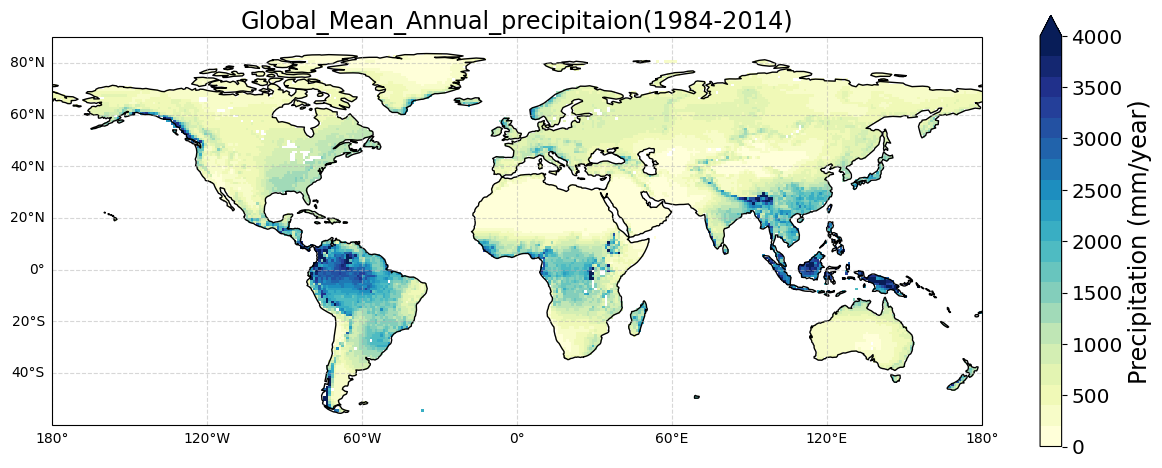


--- Q1 분석 작업 완료 ---


In [ ]:
# --- 6. 전 지구 지도 시각화 및 저장 (제목 수정본) ---
print("6단계: 전 지구 강수량 지도 생성 및 저장 시작...")

try:
    import cartopy.crs as ccrs
    CARTOPY_LOADED = True
except ImportError:
    CARTOPY_LOADED = False

plt.figure(figsize=(15, 7))

# 컬러맵 'YlGnBu' (0=Yellow, 4000=Blue)
cmap = plt.get_cmap('YlGnBu', 20)

# 컬러바(범례) 제목 'Precipitation (mm/year)'
cbar_kwargs = {
    'label': 'Precipitation (mm/year)',
    'orientation': 'vertical',
    'shrink': 0.8,
    'pad': 0.05,
    'extend': 'max'
}

if CARTOPY_LOADED:
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    da_precip_mean_land.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        cbar_kwargs=cbar_kwargs,
        vmin=0,
        vmax=4000
    )

    # --- [핵심 수정] 그래프 전체 제목 (요청 반영) ---
    ax.set_title('Global_Mean_Annual_precipitaion(1984-2014)')
    ax.set_global()
    ax.set_ylim([-60, 90])

else:
    # Cartopy가 없는 경우
    print("  - cartopy가 없어 기본 지도로 출력합니다.")
    da_precip_mean_land.plot(
        cmap=cmap,
        cbar_kwargs=cbar_kwargs,
        vmin=0,
        vmax=4000
    )
    # --- [핵심 수정] 그래프 전체 제목 (요청 반영) ---
    plt.title('Global_Mean_Annual_precipitaion(1984-2014)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.ylim([-60, 90])

# 6-5. 파일로 저장
output_filename = 'Global_Mean_Annual_Precip_1984-2014.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

print(f"\n[산출물 1.1] 지도를 '{output_filename}' 파일로 저장했습니다.")
plt.show()

print("\n--- Q1 분석 작업 완료 ---")

Q2 진입

In [ ]:
# --- 1. 필수 라이브러리 및 설정 ---
import xarray as xr
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings

# 경고 메시지 숨기기
warnings.filterwarnings('ignore')

# Cartopy 임포트는 시각화 단계에서 처리

# --- 2. 경로 및 변수 설정 (Q1에서 최종 확인된 값) ---
BASE_DATA_DIR = '/content/drive/MyDrive/MIDTERM/ERA5_data/'
PRECIP_FILE = BASE_DATA_DIR + 'total_precipitation_ERA5_globe_1965-2024_regridded.nc'
LSM_FILE = BASE_DATA_DIR + 'land_sea_mask_ERA5.nc'

VAR_PRECIP = 'tp'
VAR_LSM = 'lsm'
TIME_DIM = 'valid_time'
LAT_DIM = 'latitude'
LON_DIM = 'longitude'

# Q2/Q3 분석에 필요한 기준 기간 및 동아시아 좌표
Q2_REF_START = '1985-01-01'
Q2_REF_END = '2014-12-31'
Q3_REF_START = '1965-01-01'
Q3_REF_END = '1994-12-31'
# Q2/Q3 동아시아 영역 정의
EA_LON_SLICE = slice(75, 150)
EA_LAT_SLICE = slice(60, 15) # 위도가 내림차순이므로 (60N ~ 15N)

print("1. 필수 설정 완료.")

# --- 3. 데이터 로드 및 차원 이름 확인 ---
print("2. 데이터 로드 및 차원 추출 시작...")
try:
    # NetCDF4 엔진 자동 감지 시도
    ds_precip_all = xr.open_dataset(PRECIP_FILE)
    ds_lsm_all = xr.open_dataset(LSM_FILE)

    # 3-1. LSM 격자 보정 (Q1 4단계)
    da_lsm_regridded = ds_lsm_all[VAR_LSM].squeeze(drop=True).interp(
        {LAT_DIM: ds_precip_all[LAT_DIM],
         LON_DIM: ds_precip_all[LON_DIM]},
        method='nearest'
    )

    # 3-2. SPI 계산을 위한 강수량 단위 변환 (Q2 5단계)
    # (m/day) -> (mm/month)
    da_precip_m_day = ds_precip_all[VAR_PRECIP]
    days_in_month = da_precip_m_day[TIME_DIM].dt.days_in_month
    da_precip_mm_month = da_precip_m_day * days_in_month * 1000

    # 3-3. NumPy 배열 및 시간 좌표 추출
    tp_vals_mm = da_precip_mm_month.values
    time_coords = ds_precip_all[TIME_DIM].values
    lsm_vals = da_lsm_regridded.values

    # 3-4. 동아시아 육지 픽셀 수 계산 (Q2/Q3 공유 변수)
    da_lsm_EA = da_lsm_regridded.sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})
    num_lands_EA = (da_lsm_EA > 0.5).sum().item()

    print("3. 모든 필수 변수 로드 및 계산 완료.")

except Exception as e:
    print(f"오류: 데이터 로드 및 준비 실패. 파일을 확인하십시오: {e}")

1. 필수 설정 완료.
2. 데이터 로드 및 차원 추출 시작...
3. 모든 필수 변수 로드 및 계산 완료.


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 42.4 MB/s eta 0:00:00


In [ ]:
# --- 0. Q2/Q3 분석용 Python 라이브러리 임포트 ---
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# cartopy는 8단계/10단계에서 필요하지만 미리 임포트합니다.
try:
    import cartopy.crs as ccrs
except ImportError:
    print("경고: cartopy가 로드되지 않았습니다. [8단계] 실행 전 !pip install cartopy가 필요할 수 있습니다.")

print("NumPy, Matplotlib, Tqdm 등 Q2/Q3용 라이브러리 임포트 완료.")

NumPy, Matplotlib, Tqdm 등 Q2/Q3용 라이브러리 임포트 완료.


In [ ]:
# --- 1. R 및 R 패키지 설치 ---
print("R 및 SPEI 패키지 설치 시작...")
!apt-get update -qq && apt-get install -y -qq r-base r-base-dev
!apt-get install -qq libcurl4-openssl-dev libssl-dev libxml2-dev

# R 패키지 'remotes' 및 'SPEI' 설치
!Rscript -e "install.packages('remotes', repos='https://cloud.r-project.org')"
!Rscript -e "remotes::install_github('sbegueria/SPEI')"
print("R 패키지 설치 완료.")

# --- 2. rpy2 (Python-R 브릿지) 설치 및 로드 ---
!pip install -q rpy2
%load_ext rpy2.ipython

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.vectors import FloatVector, StrVector, ListVector, IntVector
from rpy2.robjects import pandas2ri

try:
    pandas2ri.activate()
    speiR = importr("SPEI")
    print("rpy2 및 SPEI 패키지 로드 완료.")
except Exception as e:
    print(f"rpy2 로드 실패: {e}. 런타임을 다시 시작하고 이 셀을 재실행하십시오.")

R 및 SPEI 패키지 설치 시작...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/remotes_2.5.0.tar.gz'
Content type 'application/x-gzip' length 164496 bytes (160 KB)
downloaded 160 KB

* installing *source* package ‘remotes’ ...
** this is package ‘remotes’ version ‘2.5.0’
** package ‘remotes’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
*

In [ ]:
# --- 3. SPI 계산 래퍼 함수 정의 ---

def spi(P,
        scale=1,
        distribution="Gamma",
        fit="ub-pwm",
        na_rm=False,
        ref_idx=None  # 기준기간을 인덱스로 받는 옵션
        ):
    """
    R::spi()의 Python 래퍼.
    ref_idx (인덱스 또는 bool 마스크)를 사용하여 기준기간을 지정합니다.
    """
    P_arr = np.asarray(P, float).ravel()
    n = P_arr.size

    # R 함수에 전달할 기본 인자
    def _base_kwargs(data_vector):
        return {
            'data'        : data_vector,
            'scale'       : int(scale),
            'distribution': distribution,
            'fit'         : fit,
            'na_rm'       : bool(na_rm),
            'verbose'     : False
        }

    # ref_idx가 제공된 경우 (2-Pass 방식)
    if ref_idx is not None:
        # 1. ref_idx를 boolean mask로 변환
        calib_mask = np.zeros(n, dtype=bool)
        calib_mask[ref_idx] = True

        # 2. Pass 1: 기준기간 데이터만으로 파라미터(params) 추정
        P_fit = P_arr.copy()
        P_fit[~calib_mask] = np.nan # 기준기간 외에는 NA 처리
        rP_fit = FloatVector(P_fit)
        kwargs_fit = _base_kwargs(rP_fit)
        kwargs_fit['na_rm'] = True # NA를 제거하고 피팅
        res_fit = speiR.spi(**kwargs_fit)
        coeff_R = res_fit.rx2('coefficients') # 추정된 파라미터

        # 3. Pass 2: 전체 기간 데이터에 추정된 파라미터를 적용하여 SPI 계산
        rP_full = FloatVector(P_arr)
        kwargs_full = _base_kwargs(rP_full)
        kwargs_full['params'] = coeff_R # 계산된 파라미터 직접 입력
        res = speiR.spi(**kwargs_full)

    else:
        # ref_idx가 없으면, 전체 기간을 기준으로 SPI 계산
        rP_full = FloatVector(P_arr)
        kwargs = _base_kwargs(rP_full)
        res = speiR.spi(**kwargs)

    # 결과 반환
    return {'fitted': np.array(res.rx2('fitted'))}

print("4단계: SPI 래퍼 함수 'spi()' 정의 완료.")

4단계: SPI 래퍼 함수 'spi()' 정의 완료.


In [ ]:
# --- 5. Q2 SPI-9 계산 준비 ---
print("5단계: Q2 SPI-9 계산 준비 시작...")

# 5-1. 강수량 데이터를 (m/day) -> (mm/month)로 변환
# SPI는 '월 총 강수량(mm)'을 입력으로 사용합니다.
# 원본(m/day) * (해당 월의 일수) * (1000 mm/m)
try:
    da_precip_m_day = ds_precip_all[VAR_PRECIP]
    days_in_month = da_precip_m_day[TIME_DIM].dt.days_in_month
    da_precip_mm_month = da_precip_m_day * days_in_month * 1000
    da_precip_mm_month.attrs['units'] = 'mm/month'

    # 계산에 사용할 NumPy 배열 추출
    tp_vals_mm = da_precip_mm_month.values
    time_coords = ds_precip_all[TIME_DIM].values

    # Q1에서 격자 보정된 LSM 로드 (da_lsm_regridded 변수가 메모리에 있어야 함)
    lsm_vals = da_lsm_regridded.values

    print("  - 강수량 (m/day) -> (mm/month) 변환 완료.")

except NameError as e:
    print(f"오류: {e}. Q1 분석 코드를 먼저 실행하여 'ds_precip_all', 'da_lsm_regridded' 변수를 로드해야 합니다.")
except Exception as e:
    print(f"오류 발생: {e}")


# 5-2. Q2 기준기간 (1985-2014) 인덱스 정의
# time_coords 변수는 5-1에서 생성됨
try:
    ref_start_q2 = '1985-01-01'
    ref_end_q2 = '2014-12-31'
    ref_idx_q2 = np.where(
        (time_coords >= np.datetime64(ref_start_q2)) &
        (time_coords <= np.datetime64(ref_end_q2))
    )[0]
    print(f"  - Q2 기준기간 (1985-2014) 인덱스 정의 완료 (총 {len(ref_idx_q2)} 개월).")
except Exception as e:
    print(f"오류: 기준기간 인덱스 설정 실패: {e}")


# --- 6. Q2 SPI-9 계산 실행 (★ 시간 소요 ★) ---
print("6단계: Q2 SPI-9 픽셀 단위 계산 시작... (Tqdm으로 진행률 표시)")

# 결과(SPI)를 저장할 비어있는 배열 생성
spi_vals_q2 = np.empty(tp_vals_mm.shape); spi_vals_q2[:] = np.nan

# 위도/경도 차원 크기
n_lats = len(ds_precip_all[LAT_DIM])
n_lons = len(ds_precip_all[LON_DIM])

from tqdm import tqdm # 진행률 표시

for j in tqdm(range(n_lats), desc="Latitude"): # 위도(j)
    for i in range(n_lons): # 경도(i)

        # 4단계(Q1)에서 보간된 lsm_vals 사용
        if lsm_vals[j, i] > 0.5: # 육지 픽셀인 경우에만

            # (time, lat, lon) 배열에서 (time) 1D 시계열 추출
            P_series = tp_vals_mm[:, j, i]

            # SPI-9 계산 (기준기간: ref_idx_q2)
            spi_result = spi(P_series, scale=9, ref_idx=ref_idx_q2)['fitted']

            spi_vals_q2[:, j, i] = spi_result

print("Q2 SPI-9 계산 완료.")

5단계: Q2 SPI-9 계산 준비 시작...
  - 강수량 (m/day) -> (mm/month) 변환 완료.
  - Q2 기준기간 (1985-2014) 인덱스 정의 완료 (총 360 개월).
6단계: Q2 SPI-9 픽셀 단위 계산 시작... (Tqdm으로 진행률 표시)


Latitude: 100%|██████████| 181/181 [18:57<00:00,  6.29s/it]

Q2 SPI-9 계산 완료.


In [ ]:
# --- 7. Q2 SPI-9 결과를 xarray Dataset으로 저장 ---
print("7단계: Q2 SPI-9 결과를 NetCDF 파일로 저장 중...")

ds_spi_q2 = xr.Dataset(
    data_vars={'spi': ((TIME_DIM, LAT_DIM, LON_DIM), spi_vals_q2.astype('float32')),},
    coords={
        TIME_DIM: ds_precip_all[TIME_DIM],
        LAT_DIM: ds_precip_all[LAT_DIM],
        LON_DIM: ds_precip_all[LON_DIM],
    },
    attrs={'description': '9-month SPI (Q2: ref 1985-2014)', 'units': 'z_score'},
)

# 파일 저장 (Q1과 동일한 경로)
Q2_OUTPUT_FILE = BASE_DATA_DIR + 'Q2_SPI9_global_1965-2024.nc'
ds_spi_q2.to_netcdf(Q2_OUTPUT_FILE)

print(f"  - Q2 SPI 데이터가 '{Q2_OUTPUT_FILE}'에 저장되었습니다.")

# --- (선택) 저장된 파일 다시 로드하기 ---
# (만약 런타임이 재시작되면, 1, 2단계 실행 후 이 코드만 실행하면 됨)
# ds_spi_q2 = xr.open_dataset(Q2_OUTPUT_FILE)
# print("  - 저장된 Q2 SPI 파일 로드 완료.")

7단계: Q2 SPI-9 결과를 NetCDF 파일로 저장 중...
  - Q2 SPI 데이터가 '/content/drive/MyDrive/MIDTERM/ERA5_data/Q2_SPI9_global_1965-2024.nc'에 저장되었습니다.


8단계: Q2.1 (1994년 8월) SPI 지도 시각화 시작...
  - Q2.1 지도를 'Q2_SPI9_Map_Aug1994.png' 파일로 저장했습니다.


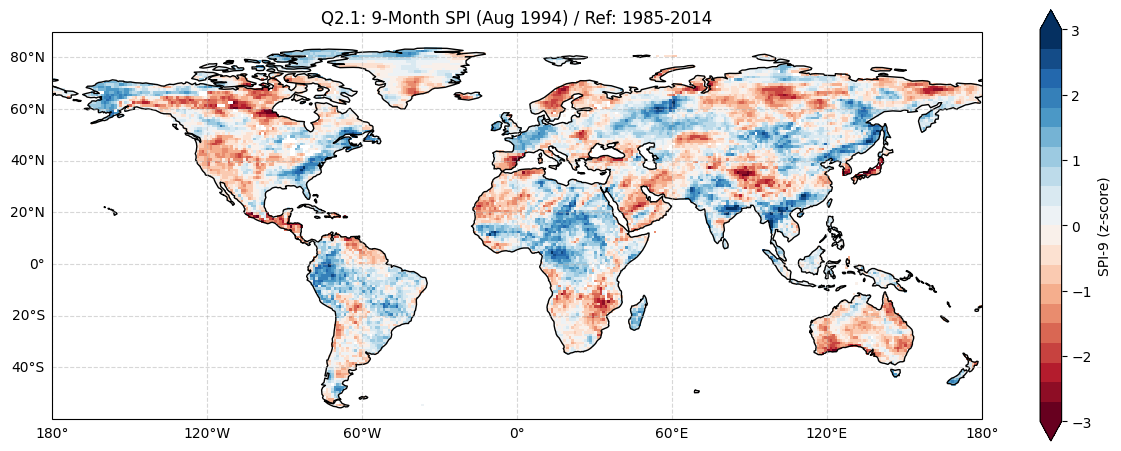

In [ ]:
# --- 8. Q2.1: 1994년 8월 전 지구 SPI 지도 시각화 ---
print("8단계: Q2.1 (1994년 8월) SPI 지도 시각화 시작...")

# 8-1. 시각화할 데이터 선택 (1994년 8월)
try:
    da_spi_aug1994 = ds_spi_q2['spi'].sel({TIME_DIM: '1994-08-01'}, method='nearest')
except Exception as e:
    print(f"오류: 1994년 8월 데이터 선택 실패: {e}")

# 8-2. 시각화
plt.figure(figsize=(15, 7))

# 가뭄 지도에 적합한 'RdBu' (Red=Drought, Blue=Wet) 컬러맵
cmap = plt.get_cmap('RdBu', 20)

cbar_kwargs = {
    'label': 'SPI-9 (z-score)',
    'orientation': 'vertical',
    'shrink': 0.8,
    'pad': 0.05,
    'extend': 'both' # vmin/vmax 초과 값 처리
}

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

da_spi_aug1994.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    cbar_kwargs=cbar_kwargs,
    vmin=-3,      # SPI 표준 범위 (-3 ~ +3)
    vmax=3
)

ax.set_title('Q2.1: 9-Month SPI (Aug 1994) / Ref: 1985-2014')
ax.set_global()
ax.set_ylim([-60, 90])

# 8-3. 파일로 저장
output_filename_q2_map = 'Q2_SPI9_Map_Aug1994.png'
plt.savefig(output_filename_q2_map, dpi=300, bbox_inches='tight')

print(f"  - Q2.1 지도를 '{output_filename_q2_map}' 파일로 저장했습니다.")
plt.show()

8-1단계: Q2.1-b (1994년 8월) '동아시아' 지도 시각화 시작...
  - Q2.1-b 동아시아 지도를 'Q2_SPI9_Map_Aug1994_EastAsia.png' 파일로 저장했습니다.


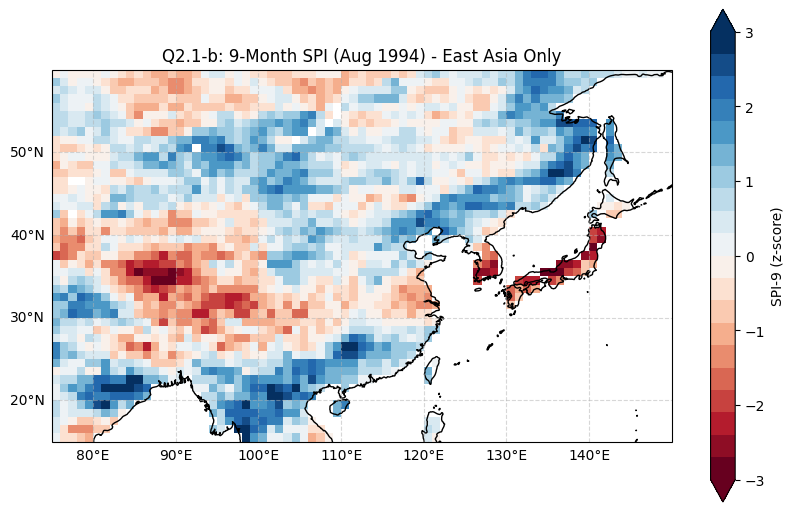


(이제 [9단계: 동아시아 시계열 분석]을 진행합니다...)


In [ ]:
# --- 8-1. (추가) Q2.1-b: 1994년 8월 동아시아 SPI 지도 시각화 ---
print("8-1단계: Q2.1-b (1994년 8월) '동아시아' 지도 시각화 시작...")

# 8-1-1. 동아시아 영역 정의 [75°-150°E, 15°-60°N]
EA_LON_SLICE = slice(75, 150)
EA_LAT_SLICE = slice(60, 15) # 위도가 내림차순이므로 (60N ~ 15N)

# 8-1-2. 1994년 8월 데이터 추출 (8단계에서 이미 생성됨)
# da_spi_aug1994 = ds_spi_q2['spi'].sel({TIME_DIM: '1994-08-01'}, method='nearest')

# 8-1-3. 동아시아 영역만 슬라이싱
try:
    da_spi_aug1994_EA = da_spi_aug1994.sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})
except NameError:
    print("오류: 'da_spi_aug1994' 변수가 없습니다. [8단계]를 먼저 실행하십시오.")
except Exception as e:
    print(f"오류: 동아시아 슬라이싱 실패: {e}")


# 8-1-4. 시각화
plt.figure(figsize=(10, 8)) # 동아시아 영역에 맞는 비율로 조정

# 가뭄 지도에 적합한 'RdBu' (Red=Drought, Blue=Wet) 컬러맵
cmap = plt.get_cmap('RdBu', 20)

cbar_kwargs = {
    'label': 'SPI-9 (z-score)',
    'orientation': 'vertical',
    'shrink': 0.8,
    'pad': 0.05,
    'extend': 'both'
}

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

da_spi_aug1994_EA.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    cbar_kwargs=cbar_kwargs,
    vmin=-3,      # SPI 표준 범위 (-3 ~ +3)
    vmax=3
)

# [핵심] set_extent로 지도를 동아시아 영역에 맞게 확대
ax.set_extent([EA_LON_SLICE.start, EA_LON_SLICE.stop, EA_LAT_SLICE.stop, EA_LAT_SLICE.start], crs=ccrs.PlateCarree())

ax.set_title('Q2.1-b: 9-Month SPI (Aug 1994) - East Asia Only')

# 8-1-5. 파일로 저장
output_filename_q2_map_ea = 'Q2_SPI9_Map_Aug1994_EastAsia.png'
plt.savefig(output_filename_q2_map_ea, dpi=300, bbox_inches='tight')

print(f"  - Q2.1-b 동아시아 지도를 '{output_filename_q2_map_ea}' 파일로 저장했습니다.")
plt.show()

print("\n(이제 [9단계: 동아시아 시계열 분석]을 진행합니다...)")

In [ ]:
# --- 3. Q2 분석 재실행 (SPI-9 계산 및 시계열 변수 로드) ---
print("3. Q2 분석 재실행 및 변수 로드 시작...")

# --- 3-1. Q2 기준기간 (1985-2014) 인덱스 정의 ---
try:
    ref_idx_q2 = np.where(
        (time_coords >= np.datetime64(Q2_REF_START)) &
        (time_coords <= np.datetime64(Q2_REF_END))
    )[0]
    print(f"  - Q2 기준기간 인덱스 정의 완료.")

except Exception as e:
    print(f"오류: 필수 변수(time_coords 등) 누락. [0단계]를 먼저 실행하십시오. : {e}")
    raise # 실행 중단


# --- 3-2. Q2 SPI-9 계산 실행 (시간 소요) ---
# Note: 이 단계는 시간이 오래 걸리므로, Q2_OUTPUT_FILE이 이미 존재하면 로드하는 것이 효율적입니다.

Q2_OUTPUT_FILE = BASE_DATA_DIR + 'Q2_SPI9_global_1965-2024.nc'

try:
    # 3-2-a. 파일이 존재하면 로드
    ds_spi_q2 = xr.open_dataset(Q2_OUTPUT_FILE)
    print(f"  - Q2 SPI 데이터가 '{Q2_OUTPUT_FILE}'에서 로드되었습니다.")

except FileNotFoundError:
    # 3-2-b. 파일이 없으면 SPI-9를 다시 계산
    print("  - Q2 SPI 파일 없음. 재계산 시작... (시간 소요)")

    spi_vals_q2 = np.empty(tp_vals_mm.shape); spi_vals_q2[:] = np.nan
    n_lats = len(ds_precip_all[LAT_DIM])
    n_lons = len(ds_precip_all[LON_DIM])

    for j in tqdm(range(n_lats), desc="Latitude (Q2)"):
        for i in range(n_lons):
            if lsm_vals[j, i] > 0.5:
                spi_vals_q2[:, j, i] = spi(tp_vals_mm[:, j, i], scale=9, ref_idx=ref_idx_q2)['fitted']

    ds_spi_q2 = xr.Dataset(
        data_vars={'spi': ((TIME_DIM, LAT_DIM, LON_DIM), spi_vals_q2.astype('float32')),},
        coords={TIME_DIM: ds_precip_all[TIME_DIM], LAT_DIM: ds_precip_all[LAT_DIM], LON_DIM: ds_precip_all[LON_DIM]},
        attrs={'description': '9-month SPI (Q2: ref 1985-2014)', 'units': 'z_score'},
    )
    ds_spi_q2.to_netcdf(Q2_OUTPUT_FILE)
    print("  - Q2 SPI 데이터 계산 완료 및 저장되었습니다.")


# --- 3-3. Q2.2 & Q2.3 동아시아 시계열 변수 정의 ---
ds_spi_EA_q2 = ds_spi_q2['spi'].sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})

# (Q2.2) 동아시아 공간 평균 SPI 계산
da_spi_mean_EA = ds_spi_EA_q2.mean(dim=[LAT_DIM, LON_DIM])
da_spi_mean_EA[:8] = np.nan

# (Q2.3) 동아시아 가뭄 면적 비율 계산
da_drought_pixels_q2 = (ds_spi_EA_q2 < -1.3).sum(dim=[LAT_DIM, LON_DIM])
da_drought_frac_EA = (da_drought_pixels_q2 / num_lands_EA) * 100
da_drought_frac_EA[:8] = np.nan

print("  - Q2 시계열 변수 (da_spi_mean_EA, da_drought_frac_EA) 정의 완료.")
print("이제 Q2 시각화 코드를 실행할 준비가 되었습니다.")

3. Q2 분석 재실행 및 변수 로드 시작...
  - Q2 기준기간 인덱스 정의 완료.
  - Q2 SPI 데이터가 '/content/drive/MyDrive/MIDTERM/ERA5_data/Q2_SPI9_global_1965-2024.nc'에서 로드되었습니다.
  - Q2 시계열 변수 (da_spi_mean_EA, da_drought_frac_EA) 정의 완료.
이제 Q2 시각화 코드를 실행할 준비가 되었습니다.


Q2 시계열: 마커 간격 9개월로 변경 후 시각화 시작...
  - Q2 시계열 통합 완료. '/content/drive/MyDrive/MIDTERM/ERA5_data/Q2_SPI9_TimeSeries_Styled_9M.png' 파일로 저장되었습니다.


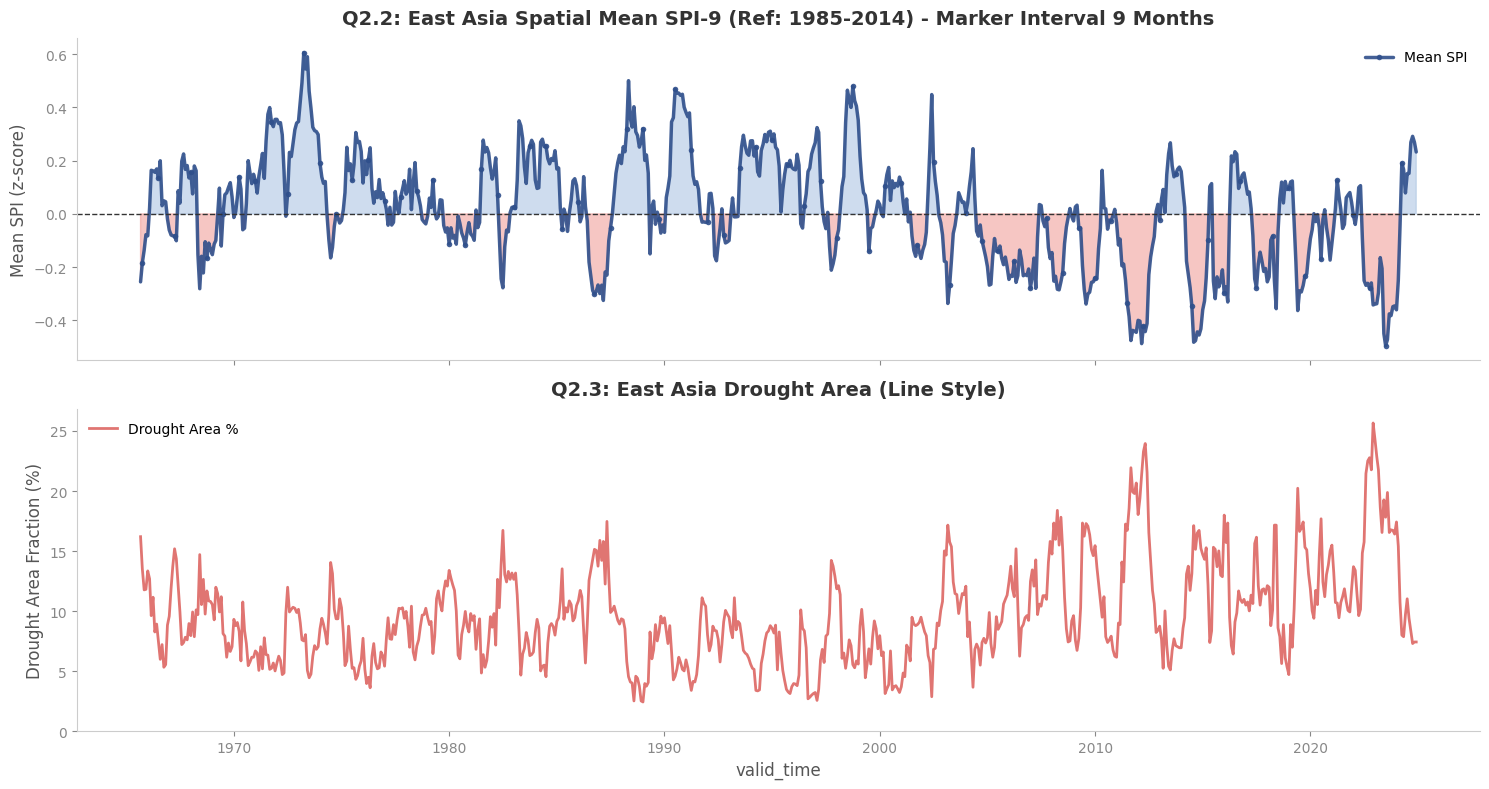

In [ ]:
# --- Q2 시계열 상하 통합 그래프 (마커 간격: 9개월 적용) ---
print("Q2 시계열: 마커 간격 9개월로 변경 후 시각화 시작...")

try:
    # 필수 변수 로드 가정 (time_x, spi_y, drought_y)
    import matplotlib.dates as mdates

    time_x = da_spi_mean_EA[TIME_DIM].values
    spi_y = da_spi_mean_EA.values
    drought_y = da_drought_frac_EA.values

    fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # --- 공통 스타일 설정 ---
    for axis in ax:
        axis.spines['top'].set_visible(False)
        axis.spines['right'].set_visible(False)
        axis.spines['left'].set_color('#cccccc')
        axis.spines['bottom'].set_color('#cccccc')
        axis.tick_params(axis='x', colors='#888888')
        axis.tick_params(axis='y', colors='#888888')

    # --- (그래프 1) Q2.2: 평균 SPI (★ 마커 9개월 간격 적용 ★) ---
    ax1 = ax[0]
    ax1.fill_between(time_x, spi_y, 0, where=(spi_y >= 0), color='#AEC6E3', alpha=0.6, interpolate=True)
    ax1.fill_between(time_x, spi_y, 0, where=(spi_y < 0), color='#F0A09B', alpha=0.6, interpolate=True)

    # 마커 간격을 SPI 척도와 동일한 9개월로 설정했습니다.
    ax1.plot(time_x, spi_y, color='#2F4F8B', linewidth=2.5, alpha=0.9,
             label='Mean SPI', solid_capstyle='round',
             marker='o', markersize=4, markevery=9, markeredgecolor='none', markerfacecolor='#2F4F8B')

    ax1.axhline(y=0, linestyle='--', color='#333333', linewidth=1)
    ax1.set_ylabel('Mean SPI (z-score)', color='#555555', fontsize=12)
    ax1.set_title('Q2.2: East Asia Spatial Mean SPI-9 (Ref: 1985-2014) - Marker Interval 9 Months',
                  fontsize=14, fontweight='bold', pad=10, color='#333333')
    ax1.legend(loc='upper right', frameon=False, fontsize=10)

    # --- (그래프 2) Q2.3: 가뭄 면적 비율 (선 그래프 유지) ---
    ax2 = ax[1]
    ax2.plot(time_x, drought_y,
            color='#D9534F',
            linewidth=2.0,
            alpha=0.8,
            label='Drought Area %')

    ax2.set_ylabel('Drought Area Fraction (%)', color='#555555', fontsize=12)
    ax2.set_title('Q2.3: East Asia Drought Area (Line Style)',
                  fontsize=14, fontweight='bold', pad=10, color='#333333')
    ax2.set_xlabel('valid_time', color='#555555', fontsize=12)
    ax2.set_ylim(bottom=0)
    ax2.legend(loc='upper left', frameon=False, fontsize=10)

    plt.tight_layout()

    output_filename_q2_styled_9m = BASE_DATA_DIR + 'Q2_SPI9_TimeSeries_Styled_9M.png'
    plt.savefig(output_filename_q2_styled_9m, dpi=300, bbox_inches='tight')

    print(f"  - Q2 시계열 통합 완료. '{output_filename_q2_styled_9m}' 파일로 저장되었습니다.")
    plt.show()

except NameError as e:
    print(f"오류: {e}. Q2 변수 로드 상태를 확인하십시오.")
except Exception as e:
    print(f"Q2 시각화 처리 중 오류 발생: {e}")


[산출물 2.4] SPI vs. 가뭄 면적 산점도 'Q2_Scatter_SPI_vs_DroughtArea.png' 저장 완료.


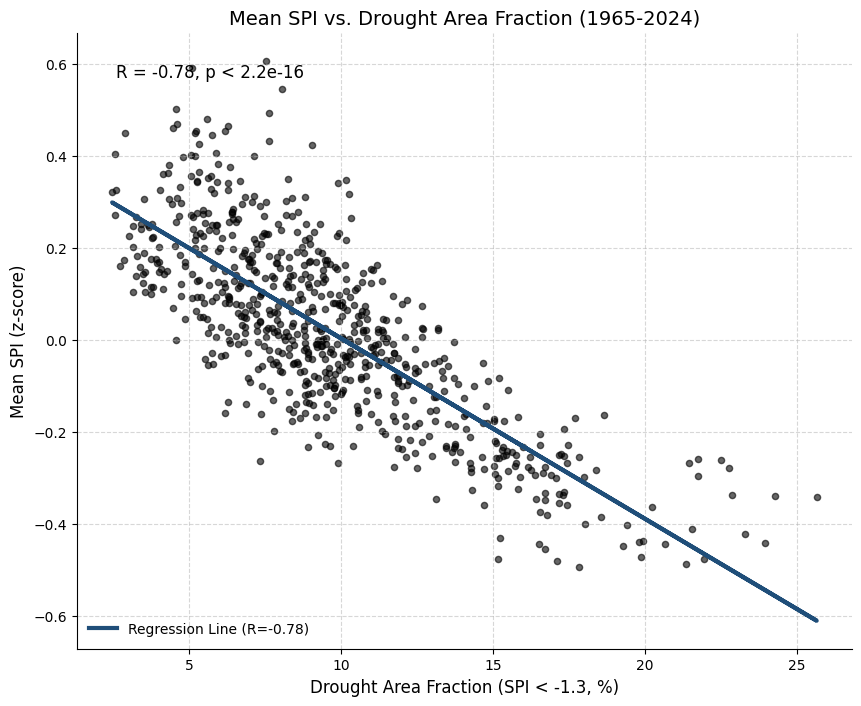

In [ ]:
print("10단계: Q2 시계열 상하 통합 그래프 생성 시작...")

try:
    # 10-1. 시계열 데이터 추출 (이전과 동일)
    time_x = da_spi_mean_EA[TIME_DIM].values
    spi_y = da_spi_mean_EA.values
    drought_y = da_drought_frac_EA.values

    # 10-2. figure 생성 및 X축 공유
    fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # --- 공통 스타일 설정 ---
    fig.patch.set_facecolor('white')
    for axis in ax:
        axis.set_facecolor('white')
        axis.spines['top'].set_visible(False)
        axis.spines['right'].set_visible(False)
        axis.spines['left'].set_color('#cccccc')
        axis.spines['bottom'].set_color('#cccccc')
        axis.tick_params(axis='x', colors='#888888')
        axis.tick_params(axis='y', colors='#888888')

    # --- (그래프 1) Q2.2: 평균 SPI (곡선 및 채우기) ---
    ax1 = ax[0]

    ax1.fill_between(time_x, spi_y, 0, where=(spi_y >= 0), color='#AEC6E3', alpha=0.6, interpolate=True)
    ax1.fill_between(time_x, spi_y, 0, where=(spi_y < 0), color='#F0A09B', alpha=0.6, interpolate=True)
    ax1.plot(time_x, spi_y, color='#2F4F8B', linewidth=2.5, alpha=0.9,
             label='Mean SPI', solid_capstyle='round')

    ax1.axhline(y=0, linestyle='--', color='#333333', linewidth=1)
    ax1.set_ylabel('Mean SPI (z-score)', color='#555555', fontsize=12)
    ax1.set_title('Q2.2: East Asia Spatial Mean SPI-9 (Wet/Dry Curve)',
                  fontsize=14, fontweight='bold', pad=10, color='#333333')
    ax1.legend(loc='upper right', frameon=False, fontsize=10)
    ax1.set_xlabel('')

    # --- (그래프 2) Q2.3: 가뭄 면적 비율 (막대 그래프) ---
    ax2 = ax[1]

    # [핵심 수정] matplotlib의 bar 함수를 date time에 맞게 수정
    # xarray의 plot.bar()가 아닌 matplotlib.bar() 사용 시 date time X축에
    # 너비(width)를 명시적으로 제거하거나, plt.bar를 다시 호출합니다.

    # 1. 월별 간격을 정수(ordinal)로 변환
    time_x_ordinal = mdates.date2num(time_x)
    # 2. 막대 너비를 월별 간격(약 30일)에 맞게 조정 (여기서는 30일 = 30)
    bar_width = 30

    ax2.bar(time_x_ordinal, drought_y,
            width=bar_width,             # 막대 너비 (30일 간격)
            color='#D9534F',
            alpha=0.8,
            align='center',              # 중앙 정렬
            label='Drought Area %')

    # x축을 정수(ordinal)로 플롯했으므로, 다시 날짜 형식으로 변환하여 표시해야 합니다.
    ax2.xaxis_date()

    ax2.set_ylabel('Drought Area Fraction (%)', color='#555555', fontsize=12)
    ax2.set_title('Q2.3: East Asia Drought Area (Bar Chart)',
                  fontsize=14, fontweight='bold', pad=10, color='#333333')
    ax2.set_xlabel(TIME_DIM, color='#555555', fontsize=12)
    ax2.set_ylim(bottom=0)
    ax2.legend(loc='upper left', frameon=False, fontsize=10)

    plt.tight_layout()

    # 10-3. 파일로 저장
    output_filename_q2_ts_combined = 'Q2_SPI9_TimeSeries_EastAsia_Combined.png'
    plt.savefig(output_filename_q2_ts_combined, dpi=300, bbox_inches='tight')

    print(f"  - Q2 시계열 분석 통합 완료. '{output_filename_q2_ts_combined}' 파일로 저장되었습니다.")
    plt.show()

    print("\n--- Q2 시각화 통합 완료 ---")

except NameError as e:
    print(f"오류: {e}. 이전 단계의 변수가 로드되지 않았습니다.")
except Exception as e:
    print(f"10단계 처리 중 오류 발생: {e}")

# *Q3* **굵은 텍스트** *이탤릭체 텍스트*

In [ ]:
# --- 0. Q1 변수 통합 로드 및 준비 ---
import xarray as xr
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Q3 막대 그래프에 필요

warnings.filterwarnings('ignore')

# --- 1. 경로 및 변수 설정 (Q1에서 최종 확인된 값) ---
BASE_DATA_DIR = '/content/drive/MyDrive/MIDTERM/ERA5_data/'
PRECIP_FILE = BASE_DATA_DIR + 'total_precipitation_ERA5_globe_1965-2024_regridded.nc'
LSM_FILE = BASE_DATA_DIR + 'land_sea_mask_ERA5.nc'

VAR_PRECIP = 'tp'
VAR_LSM = 'lsm'
TIME_DIM = 'valid_time'
LAT_DIM = 'latitude'
LON_DIM = 'longitude'

# Q2/Q3 분석에 필요한 기준 기간 및 동아시아 좌표
Q2_REF_START = '1985-01-01'
Q2_REF_END = '2014-12-31'
Q3_REF_START = '1965-01-01'
Q3_REF_END = '1994-12-31'
# Q2/Q3 동아시아 영역 정의
EA_LON_SLICE = slice(75, 150)
EA_LAT_SLICE = slice(60, 15) # 위도가 내림차순이므로 (60N ~ 15N)

print("0-1. 필수 설정 완료.")

# --- 2. 데이터 로드 및 차원 이름 확인 ---
try:
    ds_precip_all = xr.open_dataset(PRECIP_FILE)
    ds_lsm_all = xr.open_dataset(LSM_FILE)

    # 3-1. LSM 격자 보정 (Q1 4단계)
    da_lsm_regridded = ds_lsm_all[VAR_LSM].squeeze(drop=True).interp(
        {LAT_DIM: ds_precip_all[LAT_DIM],
         LON_DIM: ds_precip_all[LON_DIM]},
        method='nearest'
    )

    # 3-2. SPI 계산을 위한 강수량 단위 변환 (m/day -> mm/month)
    da_precip_m_day = ds_precip_all[VAR_PRECIP]
    days_in_month = da_precip_m_day[TIME_DIM].dt.days_in_month
    da_precip_mm_month = da_precip_m_day * days_in_month * 1000

    # 3-3. NumPy 배열 및 시간 좌표 추출
    tp_vals_mm = da_precip_mm_month.values
    time_coords = ds_precip_all[TIME_DIM].values
    lsm_vals = da_lsm_regridded.values

    # 3-4. 동아시아 육지 픽셀 수 계산
    da_lsm_EA = da_lsm_regridded.sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})
    num_lands_EA = (da_lsm_EA > 0.5).sum().item()

    print("0-2. 모든 필수 변수 로드 및 계산 완료.")

except Exception as e:
    print(f"오류: 데이터 로드 및 준비 실패. 파일을 확인하십시오: {e}")

0-1. 필수 설정 완료.
0-2. 모든 필수 변수 로드 및 계산 완료.


In [ ]:
# --- 1. R 환경 및 SPI 래퍼 함수 재정의 ---
print("1. R 환경 및 SPI 래퍼 함수 정의 시작...")

try:
    %load_ext rpy2.ipython
    import rpy2.robjects as ro
    from rpy2.robjects.packages import importr
    from rpy2.robjects.vectors import FloatVector, IntVector
    from rpy2.robjects import pandas2ri

    pandas2ri.activate()
    speiR = importr("SPEI")

    # --- SPI 래퍼 함수 재정의 ---
    def spi(P,
            scale=1,
            distribution="Gamma",
            fit="ub-pwm",
            na_rm=False,
            ref_idx=None
            ):
        P_arr = np.asarray(P, float).ravel()
        n = P_arr.size

        def _base_kwargs(data_vector):
            return {
                'data'        : data_vector,
                'scale'       : int(scale),
                'distribution': distribution,
                'fit'         : fit,
                'na_rm'       : bool(na_rm),
                'verbose'     : False
            }

        if ref_idx is not None:
            calib_mask = np.zeros(n, dtype=bool)
            calib_mask[ref_idx] = True

            P_fit = P_arr.copy()
            P_fit[~calib_mask] = np.nan
            rP_fit = FloatVector(P_fit)
            kwargs_fit = _base_kwargs(rP_fit)
            kwargs_fit['na_rm'] = True
            res_fit = speiR.spi(**kwargs_fit)
            coeff_R = res_fit.rx2('coefficients')

            rP_full = FloatVector(P_arr)
            kwargs_full = _base_kwargs(rP_full)
            kwargs_full['params'] = coeff_R
            res = speiR.spi(**kwargs_full)

        else:
            rP_full = FloatVector(P_arr)
            kwargs = _base_kwargs(rP_full)
            res = speiR.spi(**kwargs)

        return {'fitted': np.array(res.rx2('fitted'))}

    print("1-1. R/rpy2 및 SPI 래퍼 함수 'spi()' 정의 완료.")

except Exception as e:
    print(f"오류: R 환경 설정 실패. 런타임 재시작 및 R 설치(apt-get)를 확인하십시오: {e}")

1. R 환경 및 SPI 래퍼 함수 정의 시작...
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
1-1. R/rpy2 및 SPI 래퍼 함수 'spi()' 정의 완료.


In [ ]:
# --- 0-R. R 및 SPEI 패키지 재설치 ---
print("R 및 SPEI 패키지 강제 재설치 시작...")

# 1. 시스템 R 설치 확인 및 업데이트 (Colab 환경 재시작 시 필요)
!apt-get update -qq && apt-get install -y -qq r-base r-base-dev
!apt-get install -qq libcurl4-openssl-dev libssl-dev libxml2-dev

# 2. R 패키지 'remotes' 및 'SPEI' 재설치
# force=TRUE 옵션을 사용하여 이미 설치되었더라도 재설치 강행
!Rscript -e "install.packages('remotes', repos='https://cloud.r-project.org')"
!Rscript -e "remotes::install_github('sbegueria/SPEI', upgrade='never', force=TRUE)"

print("R 및 SPEI 패키지 강제 재설치 완료.")
print("이제 [1. R 환경 및 SPI 래퍼 함수 정의] 블록을 다시 실행하십시오.")

R 및 SPEI 패키지 강제 재설치 시작...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/remotes_2.5.0.tar.gz'
Content type 'application/x-gzip' length 164496 bytes (160 KB)
downloaded 160 KB

* installing *source* package ‘remotes’ ...
** this is package ‘remotes’ version ‘2.5.0’
** package ‘remotes’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation pa

Q3.1 (1994년 8월) 전 지구 SPI 지도 시각화 시작...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 56.1 MB/s eta 0:00:00
  - Q3.1 지도를 '/content/drive/MyDrive/MIDTERM/ERA5_data/Q3_SPI9_Map_Aug1994.png' 파일로 저장했습니다.


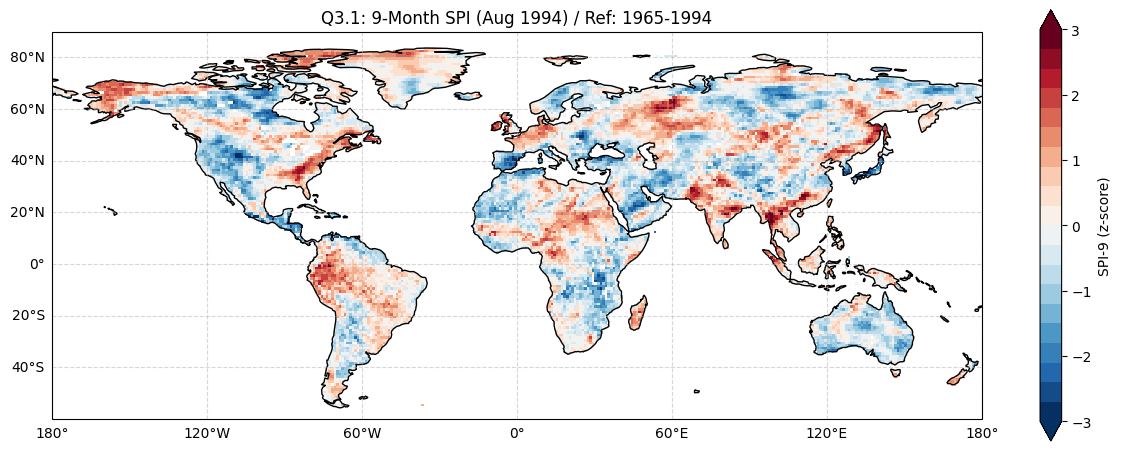

In [ ]:
# --- Q3.1: 1994년 8월 전 지구 SPI 지도 시각화 ---
print("Q3.1 (1994년 8월) 전 지구 SPI 지도 시각화 시작...")
!pip install cartopy

try:
    # Q3 분석에서 저장했거나 계산한 ds_spi_q3 변수가 필요합니다.
    # 만약 없다면 다시 로드합니다.
    try:
        if 'ds_spi_q3' not in locals():
            print("  - ds_spi_q3 변수가 없어 파일을 로드합니다...")
            Q3_OUTPUT_FILE = BASE_DATA_DIR + 'Q3_SPI9_global_1965-2024.nc'
            ds_spi_q3 = xr.open_dataset(Q3_OUTPUT_FILE)
            print("  - Q3 SPI 파일 로드 완료.")
    except NameError:
         print("오류: Q3 SPI 파일 경로(Q3_OUTPUT_FILE) 또는 BASE_DATA_DIR 변수가 정의되지 않았습니다.")
         raise
    except FileNotFoundError:
         print(f"오류: Q3 SPI 파일({Q3_OUTPUT_FILE})을 찾을 수 없습니다. Q3 계산을 먼저 완료해야 합니다.")
         raise

    # Cartopy 임포트
    import cartopy.crs as ccrs
    import matplotlib.pyplot as plt

    # 4-1. 시각화할 데이터 선택 (1994년 8월)
    da_spi_aug1994_q3 = ds_spi_q3['spi'].sel({TIME_DIM: '1994-08-01'}, method='nearest')

    # 4-2. 시각화
    plt.figure(figsize=(15, 7))
    cmap = plt.get_cmap('RdBu_r', 20) # RdBu_r: 가뭄=빨강, 습윤=파랑

    cbar_kwargs = {
        'label': 'SPI-9 (z-score)',
        'orientation': 'vertical',
        'shrink': 0.8,
        'pad': 0.05,
        'extend': 'both'
    }

    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    da_spi_aug1994_q3.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        cbar_kwargs=cbar_kwargs,
        vmin=-3, vmax=3
    )

    ax.set_title('Q3.1: 9-Month SPI (Aug 1994) / Ref: 1965-1994')
    ax.set_global()
    ax.set_ylim([-60, 90])

    # 4-3. 파일로 저장
    output_filename_q3_map = BASE_DATA_DIR + 'Q3_SPI9_Map_Aug1994.png'
    plt.savefig(output_filename_q3_map, dpi=300, bbox_inches='tight')

    print(f"  - Q3.1 지도를 '{output_filename_q3_map}' 파일로 저장했습니다.")
    plt.show()

except NameError as e:
    print(f"오류: {e}. 필수 변수(BASE_DATA_DIR, TIME_DIM 등)가 정의되지 않았습니다. [0단계] 코드를 실행하십시오.")
except Exception as e:
    print(f"Q3.1 지도 시각화 중 오류 발생: {e}")

Q3 시계열: 마커 간격 9개월로 변경 후 시각화 시작...
  - Q3 시계열 통합 완료. '/content/drive/MyDrive/MIDTERM/ERA5_data/Q3_SPI9_TimeSeries_Styled_9M.png' 파일로 저장되었습니다.


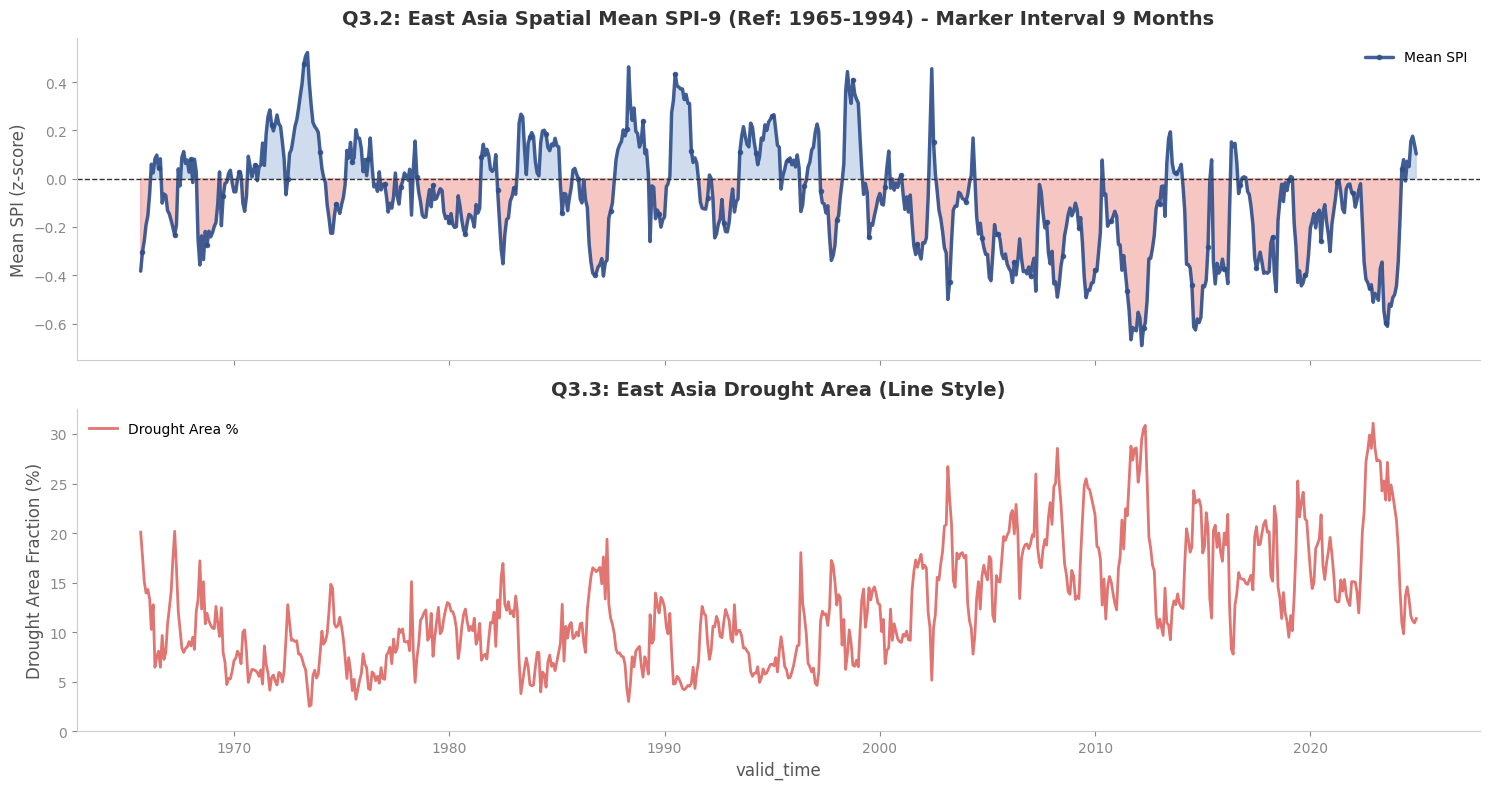

In [ ]:
# --- Q3 시계열 상하 통합 그래프 (마커 간격: 9개월 적용) ---
print("Q3 시계열: 마커 간격 9개월로 변경 후 시각화 시작...")

try:
    # 필수 변수 로드 가정 (time_x_q3, spi_y_q3, drought_y_q3)
    import matplotlib.dates as mdates

    time_x_q3 = da_spi_mean_EA_q3[TIME_DIM].values
    spi_y_q3 = da_spi_mean_EA_q3.values
    drought_y_q3 = da_drought_frac_EA_q3.values

    fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # --- 공통 스타일 설정 ---
    for axis in ax:
        axis.spines['top'].set_visible(False)
        axis.spines['right'].set_visible(False)
        axis.spines['left'].set_color('#cccccc')
        axis.spines['bottom'].set_color('#cccccc')
        axis.tick_params(axis='x', colors='#888888')
        axis.tick_params(axis='y', colors='#888888')

    # --- (그래프 1) Q3.2: 평균 SPI (★ 마커 9개월 간격 적용 ★) ---
    ax1 = ax[0]
    ax1.fill_between(time_x_q3, spi_y_q3, 0, where=(spi_y_q3 >= 0), color='#AEC6E3', alpha=0.6, interpolate=True)
    ax1.fill_between(time_x_q3, spi_y_q3, 0, where=(spi_y_q3 < 0), color='#F0A09B', alpha=0.6, interpolate=True)

    # 마커 간격을 SPI 척도와 동일한 9개월로 설정했습니다.
    ax1.plot(time_x_q3, spi_y_q3, color='#2F4F8B', linewidth=2.5, alpha=0.9,
             label='Mean SPI', solid_capstyle='round',
             marker='o', markersize=4, markevery=9, markeredgecolor='none', markerfacecolor='#2F4F8B')

    ax1.axhline(y=0, linestyle='--', color='#333333', linewidth=1)
    ax1.set_ylabel('Mean SPI (z-score)', color='#555555', fontsize=12)
    ax1.set_title('Q3.2: East Asia Spatial Mean SPI-9 (Ref: 1965-1994) - Marker Interval 9 Months',
                  fontsize=14, fontweight='bold', pad=10, color='#333333')
    ax1.legend(loc='upper right', frameon=False, fontsize=10)

    # --- (그래프 2) Q3.3: 가뭄 면적 비율 (선 그래프 유지) ---
    ax2 = ax[1]
    ax2.plot(time_x_q3, drought_y_q3,
            color='#D9534F',
            linewidth=2.0,
            alpha=0.8,
            label='Drought Area %')

    ax2.set_ylabel('Drought Area Fraction (%)', color='#555555', fontsize=12)
    ax2.set_title('Q3.3: East Asia Drought Area (Line Style)',
                  fontsize=14, fontweight='bold', pad=10, color='#333333')
    ax2.set_xlabel('valid_time', color='#555555', fontsize=12)
    ax2.set_ylim(bottom=0)
    ax2.legend(loc='upper left', frameon=False, fontsize=10)

    plt.tight_layout()

    output_filename_q3_styled_9m = BASE_DATA_DIR + 'Q3_SPI9_TimeSeries_Styled_9M.png'
    plt.savefig(output_filename_q3_styled_9m, dpi=300, bbox_inches='tight')

    print(f"  - Q3 시계열 통합 완료. '{output_filename_q3_styled_9m}' 파일로 저장되었습니다.")
    plt.show()

except NameError as e:
    print(f"오류: {e}. Q3 변수 로드 상태를 확인하십시오.")
except Exception as e:
    print(f"Q3 시각화 처리 중 오류 발생: {e}")

1. 분석 시작: 1965-1994 기준

[산출물 Q4] Q3 산점도 'Q4_Scatter_SPI_vs_DroughtArea_Q3.png' 저장 완료. R = -0.8733


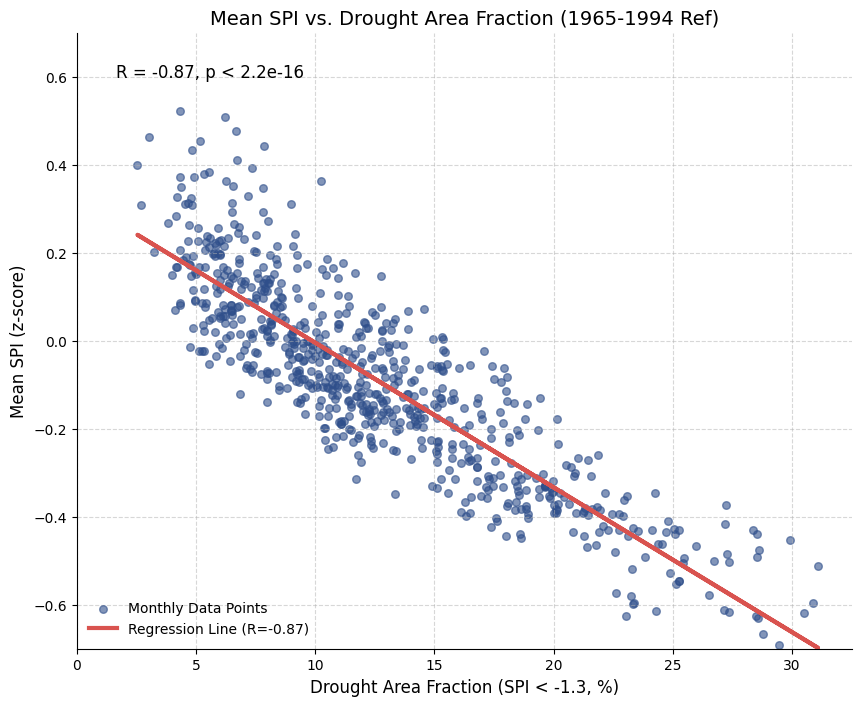


--- Q4 토의를 위한 통계 보고 ---
Q3 (1965-1994 기준) 상관계수 R: -0.8733


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr

# --- 0. 필수 변수 로드 확인 (Q3 결과 변수 사용) ---
# da_spi_mean_EA_q3, da_drought_frac_EA_q3, TIME_DIM 변수가 로드되어 있어야 합니다.
REF_PERIOD = "1965-1994"

try:
    # Q3 변수 로드 가정
    spi_mean_q3 = da_spi_mean_EA_q3.values
    drought_frac_q3 = da_drought_frac_EA_q3.values
    time_coords_q3 = da_spi_mean_EA_q3[TIME_DIM].values

    print(f"1. 분석 시작: {REF_PERIOD} 기준")

    # 1-1. 데이터 클리닝 및 정렬
    df_combined = pd.DataFrame({
        'spi': spi_mean_q3,
        'drought_area': drought_frac_q3
    }, index=time_coords_q3)

    # SPI 계산 초반의 NaN 포함 행 제거
    df_cleaned = df_combined.dropna()

    x_data = df_cleaned['drought_area'].values  # X축: 가뭄 면적 (%)
    y_data = df_cleaned['spi'].values           # Y축: 평균 SPI (z-score)

except NameError as e:
    print(f"오류: {e}. Q3 분석 단계의 변수(da_spi_mean_EA_q3, da_drought_frac_EA_q3, TIME_DIM)가 로드되지 않았습니다.")
    print("  - [Q3 분석] 코드를 먼저 실행하십시오.")
    raise

# --- 2. 상관관계 분석 (R 및 p-value 계산) ---
r_value, p_value = pearsonr(x_data, y_data)
if p_value < 2.2e-16:
    p_text = 'p < 2.2e-16'
else:
    p_text = f'p = {p_value:.2e}'

# --- 3. 선형 회귀 계산 (회귀선 플롯용) ---
slope, intercept = np.polyfit(x_data, y_data, 1)
reg_line = slope * x_data + intercept

# --- 4. 시각화 (산점도 및 회귀선) ---
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# 4-1. 산점도 플롯
ax.scatter(x_data, y_data,
           color='#2F4F8B',
           alpha=0.6,
           s=30,
           label='Monthly Data Points')

# 4-2. 회귀선 플롯
ax.plot(x_data, reg_line,
        color='#D9534F',
        linewidth=3,
        label=f'Regression Line (R={r_value:.2f})')

# 4-3. 스타일 및 레이블 설정
ax.set_title(f'Mean SPI vs. Drought Area Fraction ({REF_PERIOD} Ref)', fontsize=14)
ax.set_xlabel('Drought Area Fraction (SPI < -1.3, %)', fontsize=12)
ax.set_ylabel('Mean SPI (z-score)', fontsize=12)
ax.legend(loc='lower left', frameon=False)

# 4-4. 상관계수 텍스트 추가
ax.text(0.05, 0.95,
        f'R = {r_value:.2f}, {p_text}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top')

# 4-5. 스타일 정리
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim([-0.7, 0.7])
ax.set_xlim(left=0)

output_filename = 'Q4_Scatter_SPI_vs_DroughtArea_Q3.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

print(f"\n[산출물 Q4] Q3 산점도 '{output_filename}' 저장 완료. R = {r_value:.4f}")
plt.show()

print("\n--- Q4 토의를 위한 통계 보고 ---")
print(f"Q3 (1965-1994 기준) 상관계수 R: {r_value:.4f}")



---



---



                                                   **Q4**


---



---



In [ ]:
# --- Q4 준비: Q2의 1994년 8월 SPI 데이터 로드 ---
print("Q4 준비: Q2의 1994년 8월 SPI 데이터 로드 시작...")

try:
    # Q2 SPI 데이터 파일 로드 (이 파일은 이전에 생성되었어야 함)
    Q2_OUTPUT_FILE = BASE_DATA_DIR + 'Q2_SPI9_global_1965-2024.nc'
    ds_spi_q2 = xr.open_dataset(Q2_OUTPUT_FILE)

    # 1994년 8월 데이터 선택 -> da_spi_aug1994 변수 생성
    da_spi_aug1994 = ds_spi_q2['spi'].sel({TIME_DIM: '1994-08-01'}, method='nearest')

    print("  - Q2 (1994년 8월) SPI 데이터 로드 완료.")
    print("이제 Q4 차이 지도 코드를 실행할 수 있습니다.")

except NameError as e:
    print(f"오류: {e}. 필수 변수(BASE_DATA_DIR, TIME_DIM 등)가 정의되지 않았습니다. [0단계] 코드를 실행하십시오.")
except FileNotFoundError:
    print(f"오류: Q2 SPI 파일({Q2_OUTPUT_FILE})을 찾을 수 없습니다. Q2 계산을 먼저 완료해야 합니다.")
    raise
except Exception as e:
    print(f"Q2 데이터 로드 중 오류 발생: {e}")

Q4 준비: Q2의 1994년 8월 SPI 데이터 로드 시작...
  - Q2 (1994년 8월) SPI 데이터 로드 완료.
이제 Q4 차이 지도 코드를 실행할 수 있습니다.


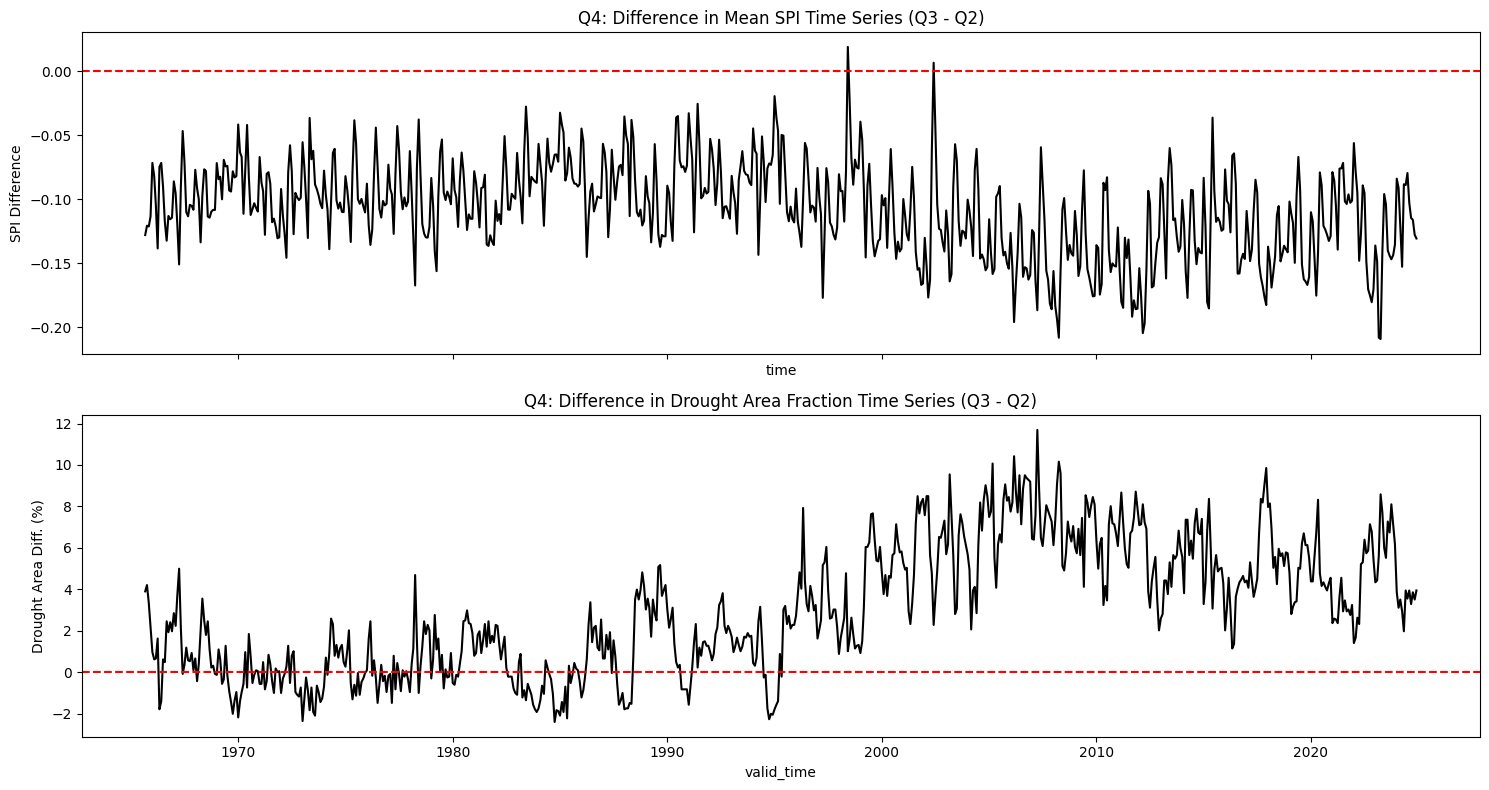

In [ ]:
# --- Q4 시계열 비교: 차이 시계열 계산 및 시각화 ---
try:
    # Q2, Q3 시계열 변수 로드 가정
    # da_spi_mean_EA, da_drought_frac_EA (Q2)
    # da_spi_mean_EA_q3, da_drought_frac_EA_q3 (Q3)

    # 차이 계산
    da_spi_diff_ts = da_spi_mean_EA_q3 - da_spi_mean_EA
    da_drought_diff_ts = da_drought_frac_EA_q3 - da_drought_frac_EA

    # 시각화
    fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # 평균 SPI 차이
    da_spi_diff_ts.plot(ax=ax[0], color='black')
    ax[0].axhline(0, color='red', linestyle='--')
    ax[0].set_title('Q4: Difference in Mean SPI Time Series (Q3 - Q2)')
    ax[0].set_ylabel('SPI Difference')

    # 가뭄 면적 차이
    da_drought_diff_ts.plot(ax=ax[1], color='black')
    ax[1].axhline(0, color='red', linestyle='--')
    ax[1].set_title('Q4: Difference in Drought Area Fraction Time Series (Q3 - Q2)')
    ax[1].set_ylabel('Drought Area Diff. (%)')
    ax[1].set_xlabel('valid_time')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"차이 시계열 생성 오류: {e}")

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

# 경고 메시지 숨기기
warnings.filterwarnings('ignore')

print("1단계: 데이터 로드 및 시계열 재생성 시작...")

try:
    # --- 1. 기본 설정 (경로 및 변수) ---
    BASE_DATA_DIR = '/content/drive/MyDrive/MIDTERM/ERA5_data/'
    Q2_OUTPUT_FILE = BASE_DATA_DIR + 'Q2_SPI9_global_1965-2024.nc'
    Q3_OUTPUT_FILE = BASE_DATA_DIR + 'Q3_SPI9_global_1965-2024.nc'

    TIME_DIM = 'valid_time'
    LAT_DIM = 'latitude'
    LON_DIM = 'longitude'

    # 동아시아 영역
    EA_LON_SLICE = slice(75, 150)
    EA_LAT_SLICE = slice(60, 15) # 위도 내림차순 (60N ~ 15N)

    # --- 2. Q2 SPI 데이터 로드 및 시계열 재생성 ---
    print(f"  - Q2 데이터 로드 중... ({Q2_OUTPUT_FILE})")
    ds_spi_q2 = xr.open_dataset(Q2_OUTPUT_FILE)

    # 동아시아 슬라이싱
    ds_spi_EA_q2 = ds_spi_q2['spi'].sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})
    # 공간 평균 계산
    da_spi_mean_EA = ds_spi_EA_q2.mean(dim=[LAT_DIM, LON_DIM])
    da_spi_mean_EA[:8] = np.nan # SPI 계산 초기 NaN 처리
    print("  - Q2 동아시아 평균 시계열 (da_spi_mean_EA) 생성 완료.")

    # --- 3. Q3 SPI 데이터 로드 및 시계열 재생성 ---
    print(f"  - Q3 데이터 로드 중... ({Q3_OUTPUT_FILE})")
    ds_spi_q3 = xr.open_dataset(Q3_OUTPUT_FILE)

    # 동아시아 슬라이싱
    ds_spi_EA_q3 = ds_spi_q3['spi'].sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})
    # 공간 평균 계산
    da_spi_mean_EA_q3 = ds_spi_EA_q3.mean(dim=[LAT_DIM, LON_DIM])
    da_spi_mean_EA_q3[:8] = np.nan # SPI 계산 초기 NaN 처리
    print("  - Q3 동아시아 평균 시계열 (da_spi_mean_EA_q3) 생성 완료.")

    print("\n[성공] 1단계: 모든 데이터 로드 및 준비 완료.")
    print("이제 2단계 (전체 기간 비교) 또는 3단계 (특정 이벤트 비교) 코드를 실행하십시오.")

except FileNotFoundError:
    print(f"오류: '{BASE_DATA_DIR}' 경로에 Q2/Q3 SPI 파일이 없습니다.")
    print("  - Q2/Q3 SPI 계산 코드를 먼저 실행하여 .nc 파일을 저장해야 합니다.")
except Exception as e:
    print(f"데이터 로드 중 오류 발생: {e}")

1단계: 데이터 로드 및 시계열 재생성 시작...
  - Q2 데이터 로드 중... (/content/drive/MyDrive/MIDTERM/ERA5_data/Q2_SPI9_global_1965-2024.nc)
  - Q2 동아시아 평균 시계열 (da_spi_mean_EA) 생성 완료.
  - Q3 데이터 로드 중... (/content/drive/MyDrive/MIDTERM/ERA5_data/Q3_SPI9_global_1965-2024.nc)
  - Q3 동아시아 평균 시계열 (da_spi_mean_EA_q3) 생성 완료.

[성공] 1단계: 모든 데이터 로드 및 준비 완료.
이제 2단계 (전체 기간 비교) 또는 3단계 (특정 이벤트 비교) 코드를 실행하십시오.


2단계: 전체 기간 (1965-2024) SPI 시계열 비교 시각화 시작...
'Graph4_SPI_Comparison_Full_Period.png'에 그래프 4 (전체 기간 비교) 저장 완료.


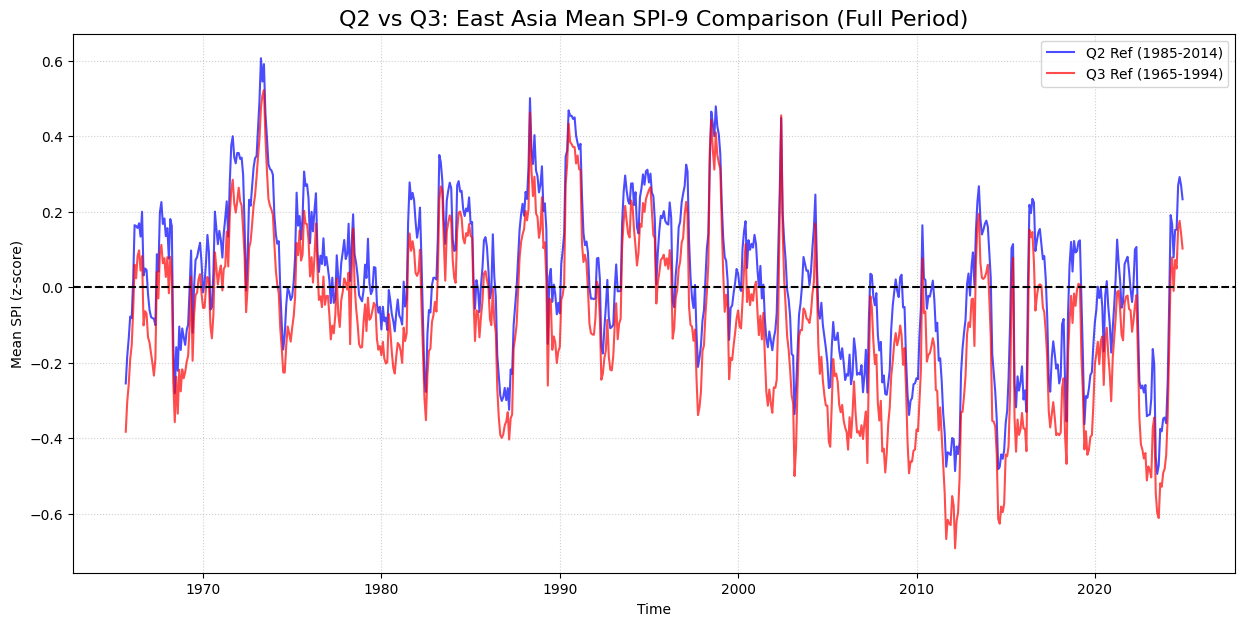

In [ ]:
print("2단계: 전체 기간 (1965-2024) SPI 시계열 비교 시각화 시작...")

try:
    # 1. 시각화
    fig, ax = plt.subplots(figsize=(15, 7))

    # 2. Q2 (1985-2014 Ref) 플롯 (파란색, 투명도 0.7)
    da_spi_mean_EA.plot(ax=ax,
                          label='Q2 Ref (1985-2014)',
                          color='blue',
                          alpha=0.7)

    # 3. Q3 (1965-1994 Ref) 플롯 (붉은색, 투명도 0.7)
    da_spi_mean_EA_q3.plot(ax=ax,
                           label='Q3 Ref (1965-1994)',
                           color='red',
                           alpha=0.7)

    # 4. 스타일
    ax.axhline(0, color='black', linestyle='--')
    ax.set_title('Q2 vs Q3: East Asia Mean SPI-9 Comparison (Full Period)', fontsize=16)
    ax.set_ylabel('Mean SPI (z-score)')
    ax.set_xlabel('Time')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    # 5. 저장
    output_filename = 'Graph4_SPI_Comparison_Full_Period.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')

    print(f"'{output_filename}'에 그래프 4 (전체 기간 비교) 저장 완료.")
    plt.show()

except NameError:
    print("오류: 'da_spi_mean_EA' 변수가 없습니다. 1단계 로드 코드를 먼저 실행하십시오.")
except Exception as e:
    print(f"시각화 중 오류 발생: {e}")

4단계: 겹치는 기간 (1985-1994) 기울기 비교 시작...

[기울기 계산 결과 (1985-1994)]
  - Q2 (Ref 1985-2014) 기울기:  0.001627 (p-value:  0.001)
  - Q3 (Ref 1965-1994) 기울기:  0.001615 (p-value:  0.003)
  - 기울기 차이 (Q3 - Q2): -0.000012

'Graph5_SPI_Slope_Comparison_Overlap.png'에 그래프 5 (기울기 비교) 저장 완료.


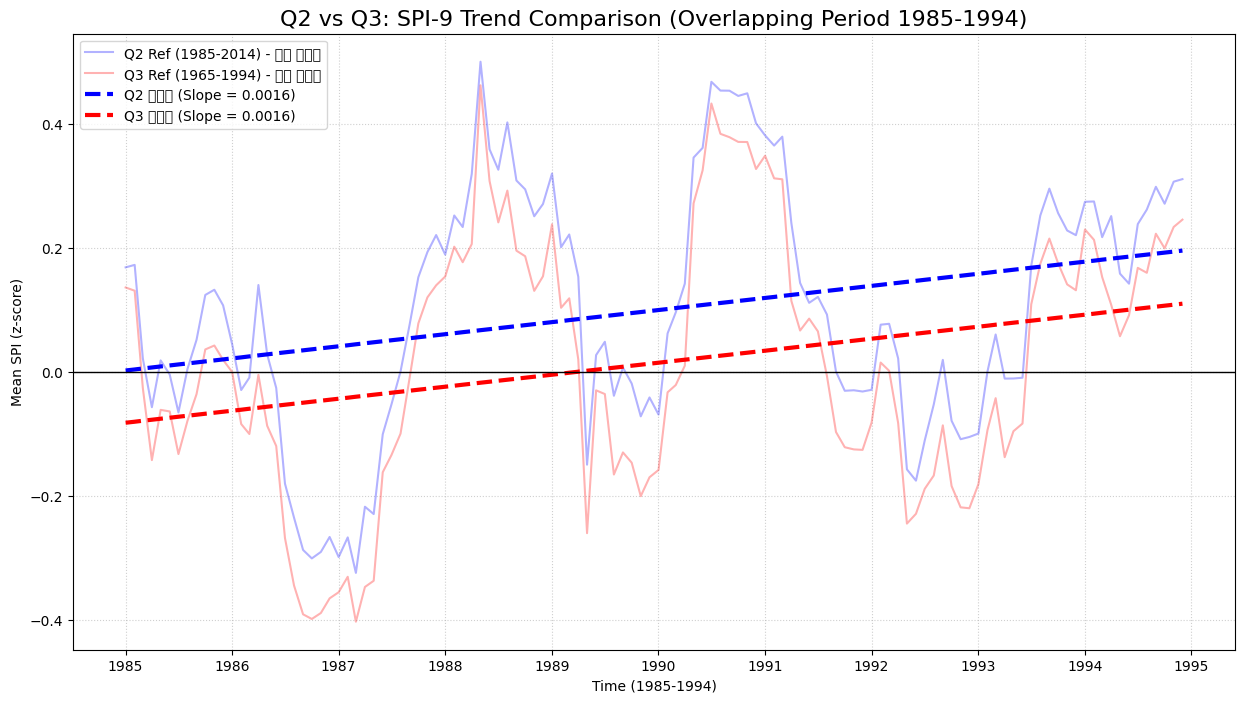

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress # 기울기, p-value 등 계산에 용이

print("4단계: 겹치는 기간 (1985-1994) 기울기 비교 시작...")

try:
    # --- 1. 겹치는 기간 정의 ---
    START_OVERLAP = '1985-01-01'
    END_OVERLAP = '1994-12-31'

    # --- 2. 겹치는 기간 데이터 슬라이싱 ---
    # TIME_DIM 변수는 1단계 로드 코드에서 'valid_time'으로 정의됨
    da_q2_overlap = da_spi_mean_EA.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})
    da_q3_overlap = da_spi_mean_EA_q3.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})

    # --- 3. 기울기 계산을 위한 x축 준비 (단순 정수 인덱스 사용) ---
    # linregress는 NaN 값을 자동으로 처리하지 않으므로, .dropna()가 필요할 수 있으나
    # 이 기간(1985-1994)은 SPI 계산 초기(1965)가 아니므로 NaN이 없을 것으로 가정
    x_axis = np.arange(len(da_q2_overlap[TIME_DIM]))
    y_q2 = da_q2_overlap.values
    y_q3 = da_q3_overlap.values

    # --- 4. 선형 회귀(기울기) 계산 ---
    # Q2 기울기
    slope_q2, intercept_q2, r_q2, p_q2, _ = linregress(x_axis, y_q2)
    reg_line_q2 = slope_q2 * x_axis + intercept_q2

    # Q3 기울기
    slope_q3, intercept_q3, r_q3, p_q3, _ = linregress(x_axis, y_q3)
    reg_line_q3 = slope_q3 * x_axis + intercept_q3

    print("\n[기울기 계산 결과 (1985-1994)]")
    print(f"  - Q2 (Ref 1985-2014) 기울기: {slope_q2: .6f} (p-value: {p_q2: .3f})")
    print(f"  - Q3 (Ref 1965-1994) 기울기: {slope_q3: .6f} (p-value: {p_q3: .3f})")
    print(f"  - 기울기 차이 (Q3 - Q2): {slope_q3 - slope_q2: .6f}")

    # --- 5. 시각화 ---
    fig, ax = plt.subplots(figsize=(15, 8))

    # 원본 데이터 플롯 (투명하게)
    ax.plot(da_q2_overlap[TIME_DIM], y_q2,
            label='Q2 Ref (1985-2014) - 원본 데이터',
            color='blue', alpha=0.3)
    ax.plot(da_q3_overlap[TIME_DIM], y_q3,
            label='Q3 Ref (1965-1994) - 원본 데이터',
            color='red', alpha=0.3)

    # 회귀선(기울기) 플롯 (진하게)
    ax.plot(da_q2_overlap[TIME_DIM], reg_line_q2,
            label=f'Q2 추세선 (Slope = {slope_q2:.4f})',
            color='blue', linestyle='--', linewidth=3)
    ax.plot(da_q3_overlap[TIME_DIM], reg_line_q3,
            label=f'Q3 추세선 (Slope = {slope_q3:.4f})',
            color='red', linestyle='--', linewidth=3)

    # 스타일
    ax.set_title('Q2 vs Q3: SPI-9 Trend Comparison (Overlapping Period 1985-1994)', fontsize=16)
    ax.set_xlabel('Time (1985-1994)')
    ax.set_ylabel('Mean SPI (z-score)')
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.axhline(0, color='black', linestyle='-', linewidth=1)

    # --- 6. 파일 저장 ---
    output_filename = 'Graph5_SPI_Slope_Comparison_Overlap.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')

    print(f"\n'{output_filename}'에 그래프 5 (기울기 비교) 저장 완료.")
    plt.show()

except NameError:
    print("오류: 'da_spi_mean_EA', 'da_spi_mean_EA_q3' 또는 'TIME_DIM' 변수가 없습니다.")
    print("  - 1단계 로드 코드를 먼저 실행하십시오.")
except Exception as e:
    print(f"시각화 중 오류 발생: {e}")

5단계: Q3-Q2 SPI 차이 시계열 그래프 (1985-1994) 생성 시작...

'Graph6_SPI_Difference_TimeSeries_Overlap.png'에 그래프 6 (차이 시계열) 저장 완료.


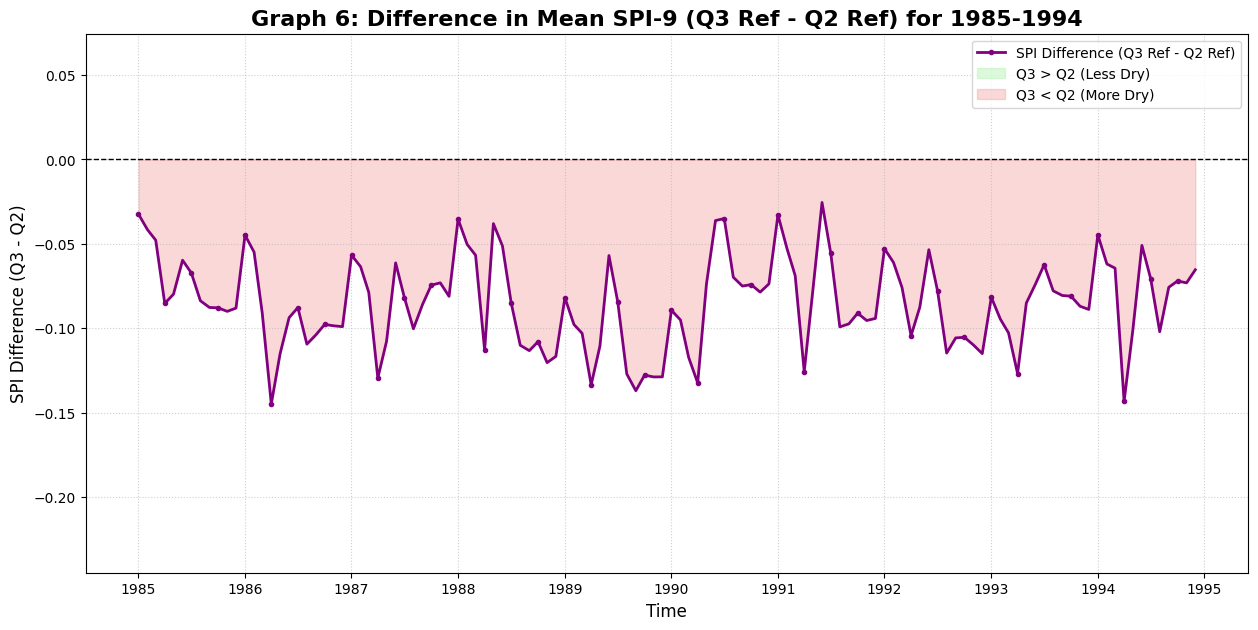

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("5단계: Q3-Q2 SPI 차이 시계열 그래프 (1985-1994) 생성 시작...")

try:
    # --- 1. 겹치는 기간 정의 ---
    START_OVERLAP = '1985-01-01'
    END_OVERLAP = '1994-12-31'

    # --- 2. 겹치는 기간 데이터 슬라이싱 ---
    # TIME_DIM 변수는 1단계 로드 코드에서 'valid_time'으로 정의됨
    da_q2_overlap = da_spi_mean_EA.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})
    da_q3_overlap = da_spi_mean_EA_q3.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})

    # --- 3. SPI 값 차이 계산 (Q3 - Q2) ---
    da_spi_diff_overlap = da_q3_overlap - da_q2_overlap

    # --- 4. 시각화 ---
    fig, ax = plt.subplots(figsize=(15, 7))

    # 차이 시계열 플롯
    ax.plot(da_spi_diff_overlap[TIME_DIM], da_spi_diff_overlap.values,
            label='SPI Difference (Q3 Ref - Q2 Ref)',
            color='purple',
            linewidth=2,
            marker='o', markersize=3, markevery=3) # 3개월마다 마커 표시

    # 기준선 (0) 플롯
    ax.axhline(0, color='black', linestyle='--', linewidth=1)

    # 양수/음수 영역 음영 처리 (선택 사항: 차이를 더 강조)
    ax.fill_between(da_spi_diff_overlap[TIME_DIM].values, da_spi_diff_overlap.values, 0,
                    where=(da_spi_diff_overlap.values >= 0),
                    color='lightgreen', alpha=0.3, interpolate=True, label='Q3 > Q2 (Less Dry)')
    ax.fill_between(da_spi_diff_overlap[TIME_DIM].values, da_spi_diff_overlap.values, 0,
                    where=(da_spi_diff_overlap.values < 0),
                    color='lightcoral', alpha=0.3, interpolate=True, label='Q3 < Q2 (More Dry)')


    # 스타일 및 레이블 설정
    ax.set_title('Graph 6: Difference in Mean SPI-9 (Q3 Ref - Q2 Ref) for 1985-1994',
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('SPI Difference (Q3 - Q2)', fontsize=12)
    ax.legend(loc='upper right', frameon=True, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    # y축 범위 자동 조절 또는 수동 설정 (예: ax.set_ylim(-0.5, 0.5))
    ax.set_ylim(min(da_spi_diff_overlap.values)-0.1, max(da_spi_diff_overlap.values)+0.1)


    # --- 5. 파일 저장 ---
    output_filename = 'Graph6_SPI_Difference_TimeSeries_Overlap.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')

    print(f"\n'{output_filename}'에 그래프 6 (차이 시계열) 저장 완료.")
    plt.show()

except NameError:
    print("오류: 'da_spi_mean_EA', 'da_spi_mean_EA_q3' 또는 'TIME_DIM' 변수가 없습니다.")
    print("  - 1단계 로드 코드를 먼저 실행하십시오.")
except Exception as e:
    print(f"시각화 중 오류 발생: {e}")

6단계: Q2 vs Q3 SPI 산점도 (1985-1994) 생성 시작...

'Graph7_SPI_Scatter_Plot_Overlap.png'에 그래프 7 (산점도) 저장 완료.


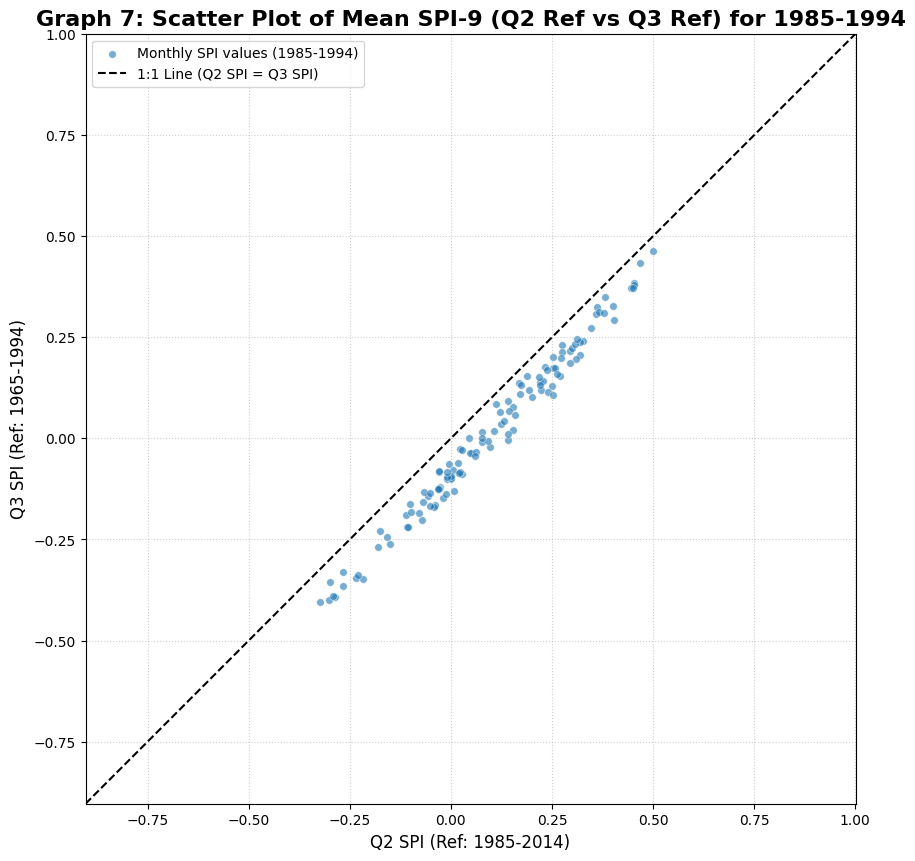

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("6단계: Q2 vs Q3 SPI 산점도 (1985-1994) 생성 시작...")

try:
    # --- 1. 겹치는 기간 정의 (차이 시계열과 동일) ---
    START_OVERLAP = '1985-01-01'
    END_OVERLAP = '1994-12-31'

    # --- 2. 겹치는 기간 데이터 슬라이싱 ---
    da_q2_overlap = da_spi_mean_EA.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})
    da_q3_overlap = da_spi_mean_EA_q3.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})

    # --- 3. 시각화 ---
    fig, ax = plt.subplots(figsize=(10, 10)) # 정사각형 형태로 설정하여 1:1 선 강조

    # 산점도 플롯
    ax.scatter(da_q2_overlap.values, da_q3_overlap.values,
               s=30, alpha=0.6, edgecolors='w', linewidths=0.5,
               label='Monthly SPI values (1985-1994)')

    # 1:1 기준선 플롯
    # x, y 축의 최소/최대값 중 더 작은 값과 더 큰 값을 찾아 대칭적인 범위 설정
    min_val = min(da_q2_overlap.values.min(), da_q3_overlap.values.min())
    max_val = max(da_q2_overlap.values.max(), da_q3_overlap.values.max())
    plot_range = np.linspace(min_val - 0.5, max_val + 0.5, 100)

    ax.plot(plot_range, plot_range, color='black', linestyle='--',
            label='1:1 Line (Q2 SPI = Q3 SPI)')

    # 스타일 및 레이블 설정
    ax.set_title('Graph 7: Scatter Plot of Mean SPI-9 (Q2 Ref vs Q3 Ref) for 1985-1994',
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Q2 SPI (Ref: 1985-2014)', fontsize=12)
    ax.set_ylabel('Q3 SPI (Ref: 1965-1994)', fontsize=12)
    ax.legend(loc='upper left', frameon=True, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    # x, y 축 범위 동일하게 설정
    ax.set_xlim(min_val - 0.5, max_val + 0.5)
    ax.set_ylim(min_val - 0.5, max_val + 0.5)
    ax.set_aspect('equal', adjustable='box') # x, y 축 비율을 1:1로 유지

    # --- 4. 파일 저장 ---
    output_filename = 'Graph7_SPI_Scatter_Plot_Overlap.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')

    print(f"\n'{output_filename}'에 그래프 7 (산점도) 저장 완료.")
    plt.show()

except NameError:
    print("오류: 'da_spi_mean_EA', 'da_spi_mean_EA_q3' 또는 'TIME_DIM' 변수가 없습니다.")
    print("  - 1단계 로드 코드를 먼저 실행하십시오.")
except Exception as e:
    print(f"시각화 중 오류 발생: {e}")

7단계: Q2 vs Q3 SPI 산점도 (1985-1994) [색상 수정] 생성 시작...

'Graph7_SPI_Scatter_Plot_Overlap_Color_Adjusted.png'에 그래프 7 (SPI 산점도, 색상 수정) 저장 완료.


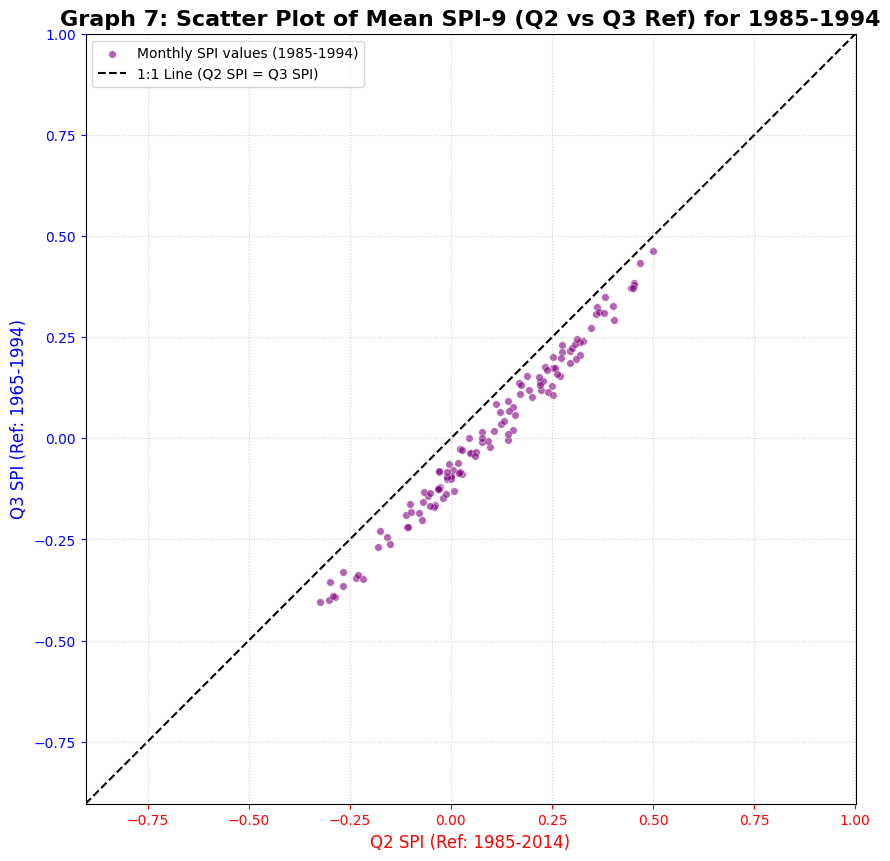

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("7단계: Q2 vs Q3 SPI 산점도 (1985-1994) [색상 수정] 생성 시작...")

try:
    # --- 1. 겹치는 기간 정의 (1985-1994) ---
    START_OVERLAP = '1985-01-01'
    END_OVERLAP = '1994-12-31'

    # --- 2. 겹치는 기간 SPI 데이터 슬라이싱 ---
    # da_spi_mean_EA (Q2), da_spi_mean_EA_q3 (Q3) 변수가 로드되어 있어야 함
    da_q2_overlap = da_spi_mean_EA.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})
    da_q3_overlap = da_spi_mean_EA_q3.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})

    # --- 3. 시각화 ---
    fig, ax = plt.subplots(figsize=(10, 10))

    # [수정] 산점도 플롯 (중립색 'purple'로 변경)
    ax.scatter(da_q2_overlap.values, da_q3_overlap.values,
               s=30, alpha=0.6, edgecolors='w', linewidths=0.5,
               color='purple', # 중립색으로 변경
               label='Monthly SPI values (1985-1994)')

    # 1:1 기준선 플롯
    min_val = min(da_q2_overlap.values.min(), da_q3_overlap.values.min())
    max_val = max(da_q2_overlap.values.max(), da_q3_overlap.values.max())
    plot_range = np.linspace(min_val - 0.5, max_val + 0.5, 100)
    ax.plot(plot_range, plot_range, color='black', linestyle='--',
            label='1:1 Line (Q2 SPI = Q3 SPI)')

    # --- 4. [핵심 수정] 스타일 및 레이블 색상 변경 ---
    ax.set_title('Graph 7: Scatter Plot of Mean SPI-9 (Q2 vs Q3 Ref) for 1985-1994',
                 fontsize=16, fontweight='bold')

    # X축 (Q2) = 빨간색
    ax.set_xlabel('Q2 SPI (Ref: 1985-2014)', fontsize=12, color='red')
    ax.tick_params(axis='x', colors='red')

    # Y축 (Q3) = 파란색
    ax.set_ylabel('Q3 SPI (Ref: 1965-1994)', fontsize=12, color='blue')
    ax.tick_params(axis='y', colors='blue')

    ax.legend(loc='upper left', frameon=True, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(min_val - 0.5, max_val + 0.5)
    ax.set_ylim(min_val - 0.5, max_val + 0.5)
    ax.set_aspect('equal', adjustable='box')

    # --- 5. 파일 저장 ---
    output_filename = 'Graph7_SPI_Scatter_Plot_Overlap_Color_Adjusted.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')

    print(f"\n'{output_filename}'에 그래프 7 (SPI 산점도, 색상 수정) 저장 완료.")
    plt.show()

except NameError:
    print("오류: 'da_spi_mean_EA' 또는 'da_spi_mean_EA_q3' 변수가 로드되지 않았습니다.")
    print("  - 1단계 로드 코드를 먼저 실행하십시오.")
except Exception as e:
    print(f"시각화 중 오류 발생: {e}")

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

# 경고 메시지 숨기기
warnings.filterwarnings('ignore')

print("1단계 (수정): 데이터 로드 및 모든 시계열(평균 SPI + 가뭄 면적) 재생성 시작...")

try:
    # --- 1. 기본 설정 (모든 파일 경로 포함) ---
    BASE_DATA_DIR = '/content/drive/MyDrive/MIDTERM/ERA5_data/'
    Q2_OUTPUT_FILE = BASE_DATA_DIR + 'Q2_SPI9_global_1965-2024.nc'
    Q3_OUTPUT_FILE = BASE_DATA_DIR + 'Q3_SPI9_global_1965-2024.nc'

    # 가뭄 면적 계산을 위해 원본 강수량 파일(격자 정보용)과 LSM 파일이 필요합니다.
    PRECIP_FILE = BASE_DATA_DIR + 'total_precipitation_ERA5_globe_1965-2024_regridded.nc'
    LSM_FILE = BASE_DATA_DIR + 'land_sea_mask_ERA5.nc'

    TIME_DIM = 'valid_time'
    LAT_DIM = 'latitude'
    LON_DIM = 'longitude'
    VAR_LSM = 'lsm'

    EA_LON_SLICE = slice(75, 150)
    EA_LAT_SLICE = slice(60, 15) # 60N ~ 15N

    # --- 2. [추가] LSM 로드 및 동아시아 육지 픽셀 수 계산 ---
    print("  - LSM 로드 및 격자 보간 중...")
    ds_lsm_all = xr.open_dataset(LSM_FILE)
    ds_precip_grid_info = xr.open_dataset(PRECIP_FILE) # 격자 정보만 사용

    da_lsm_regridded = ds_lsm_all[VAR_LSM].squeeze(drop=True).interp(
        {LAT_DIM: ds_precip_grid_info[LAT_DIM],
         LON_DIM: ds_precip_grid_info[LON_DIM]},
        method='nearest'
    )

    da_lsm_EA = da_lsm_regridded.sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})
    num_lands_EA = (da_lsm_EA > 0.5).sum().item()
    print(f"  - 동아시아 육지 픽셀 수 (num_lands_EA) 계산 완료: {num_lands_EA}")

    ds_lsm_all.close()
    ds_precip_grid_info.close()

    # --- 3. Q2 SPI 데이터 로드 및 시계열 (평균 + 가뭄 면적) 재생성 ---
    print(f"  - Q2 데이터 로드 중... ({Q2_OUTPUT_FILE})")
    ds_spi_q2 = xr.open_dataset(Q2_OUTPUT_FILE)
    ds_spi_EA_q2 = ds_spi_q2['spi'].sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})

    # Q2 평균 SPI
    da_spi_mean_EA = ds_spi_EA_q2.mean(dim=[LAT_DIM, LON_DIM])
    da_spi_mean_EA[:8] = np.nan
    print("  - Q2 평균 SPI (da_spi_mean_EA) 생성 완료.")

    # [추가] Q2 가뭄 면적 비율
    da_drought_pixels_q2 = (ds_spi_EA_q2 < -1.3).sum(dim=[LAT_DIM, LON_DIM])
    da_drought_frac_EA = (da_drought_pixels_q2 / num_lands_EA) * 100
    da_drought_frac_EA[:8] = np.nan
    print("  - Q2 가뭄 면적 비율 (da_drought_frac_EA) 생성 완료.")

    # --- 4. Q3 SPI 데이터 로드 및 시계열 (평균 + 가뭄 면적) 재생성 ---
    print(f"  - Q3 데이터 로드 중... ({Q3_OUTPUT_FILE})")
    ds_spi_q3 = xr.open_dataset(Q3_OUTPUT_FILE)
    ds_spi_EA_q3 = ds_spi_q3['spi'].sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})

    # Q3 평균 SPI
    da_spi_mean_EA_q3 = ds_spi_EA_q3.mean(dim=[LAT_DIM, LON_DIM])
    da_spi_mean_EA_q3[:8] = np.nan
    print("  - Q3 평균 SPI (da_spi_mean_EA_q3) 생성 완료.")

    # [추가] Q3 가뭄 면적 비율
    da_drought_pixels_q3 = (ds_spi_EA_q3 < -1.3).sum(dim=[LAT_DIM, LON_DIM])
    da_drought_frac_EA_q3 = (da_drought_pixels_q3 / num_lands_EA) * 100
    da_drought_frac_EA_q3[:8] = np.nan
    print("  - Q3 가뭄 면적 비율 (da_drought_frac_EA_q3) 생성 완료.")

    # --- 5. 로드 완료 ---
    ds_spi_q2.close()
    ds_spi_q3.close()

    print("\n[성공] 1단계 (수정): 모든 필수 변수(평균 SPI 2개, 가뭄 면적 2개) 로드 완료.")
    print("이제 8단계 (가뭄 면적 산점도) 코드를 다시 실행하십시오.")

except FileNotFoundError as e:
    print(f"오류: 파일 경로를 확인하십시오. {e}")
    print("  - Q2/Q3 SPI 파일 및 LSM, PRECIP 파일이 모두 필요합니다.")
except Exception as e:
    print(f"데이터 로드 중 오류 발생: {e}")

1단계 (수정): 데이터 로드 및 모든 시계열(평균 SPI + 가뭄 면적) 재생성 시작...
  - LSM 로드 및 격자 보간 중...
  - 동아시아 육지 픽셀 수 (num_lands_EA) 계산 완료: 2284
  - Q2 데이터 로드 중... (/content/drive/MyDrive/MIDTERM/ERA5_data/Q2_SPI9_global_1965-2024.nc)
  - Q2 평균 SPI (da_spi_mean_EA) 생성 완료.
  - Q2 가뭄 면적 비율 (da_drought_frac_EA) 생성 완료.
  - Q3 데이터 로드 중... (/content/drive/MyDrive/MIDTERM/ERA5_data/Q3_SPI9_global_1965-2024.nc)
  - Q3 평균 SPI (da_spi_mean_EA_q3) 생성 완료.
  - Q3 가뭄 면적 비율 (da_drought_frac_EA_q3) 생성 완료.

[성공] 1단계 (수정): 모든 필수 변수(평균 SPI 2개, 가뭄 면적 2개) 로드 완료.
이제 8단계 (가뭄 면적 산점도) 코드를 다시 실행하십시오.


8단계: Q2 vs Q3 가뭄 면적 비율(%) 산점도 (1985-1994) [신규] 생성 시작...

'Graph8_Drought_Area_Scatter_Plot_Overlap.png'에 그래프 8 (가뭄 면적 산점도) 저장 완료.


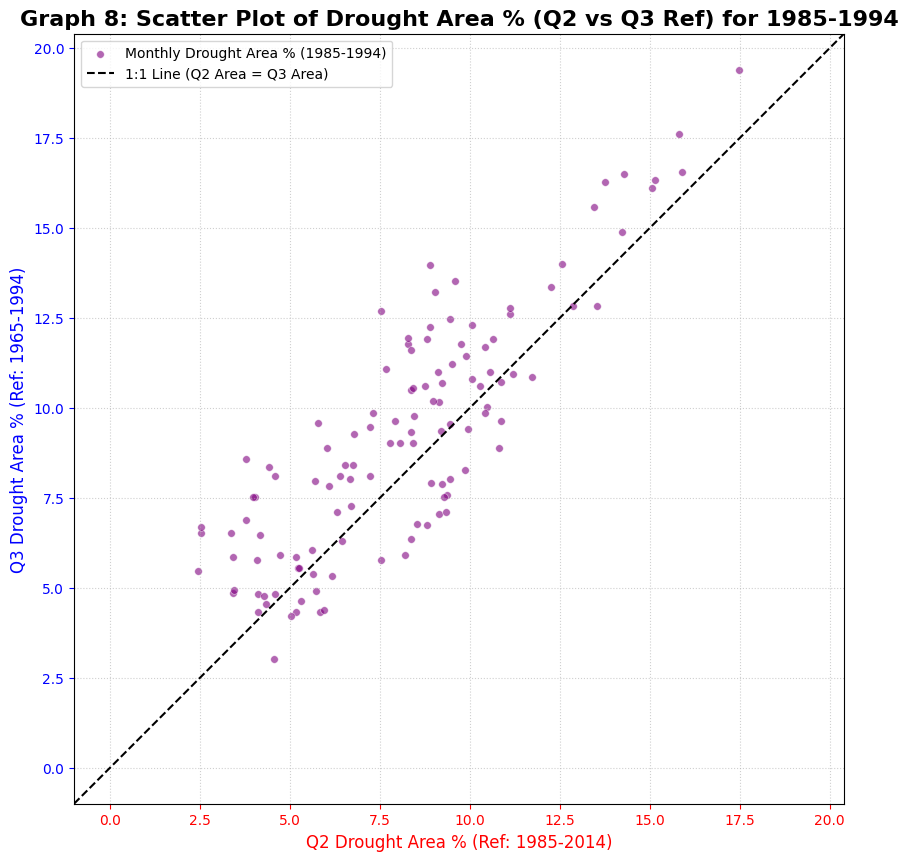

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("8단계: Q2 vs Q3 가뭄 면적 비율(%) 산점도 (1985-1994) [신규] 생성 시작...")

try:
    # --- 1. 겹치는 기간 정의 (1985-1994) ---
    START_OVERLAP = '1985-01-01'
    END_OVERLAP = '1994-12-31'

    # --- 2. 겹치는 기간 '가뭄 면적' 데이터 슬라이싱 ---
    # 1단계 로드 코드에서 'da_drought_frac_EA' (Q2)와 'da_drought_frac_EA_q3' (Q3) 변수도 생성했어야 함
    # 만약 1단계에서 이 변수들을 생성하지 않았다면, 1단계 코드를 수정하여 재생성해야 함

    # Q2/Q3 가뭄 면적 비율 시계열 재생성 (1단계 코드에 이미 포함되어 있어야 함)
    # ds_spi_EA_q2 = ds_spi_q2['spi'].sel({LAT_DIM: EA_LAT_SLICE, LON_DIM: EA_LON_SLICE})
    # da_drought_pixels_q2 = (ds_spi_EA_q2 < -1.3).sum(dim=[LAT_DIM, LON_DIM])
    # da_drought_frac_EA = (da_drought_pixels_q2 / num_lands_EA) * 100 # num_lands_EA도 1단계에서 계산 필요

    # da_drought_frac_EA, da_drought_frac_EA_q3 변수가 이미 로드되었다고 가정
    da_q2_drought_overlap = da_drought_frac_EA.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})
    da_q3_drought_overlap = da_drought_frac_EA_q3.sel({TIME_DIM: slice(START_OVERLAP, END_OVERLAP)})

    # --- 3. 시각화 ---
    fig, ax = plt.subplots(figsize=(10, 10))

    # 산점도 플롯 (중립색 'purple')
    ax.scatter(da_q2_drought_overlap.values, da_q3_drought_overlap.values,
               s=30, alpha=0.6, edgecolors='w', linewidths=0.5,
               color='purple',
               label='Monthly Drought Area % (1985-1994)')

    # 1:1 기준선 플롯
    min_val = 0 # 가뭄 면적은 0%부터 시작
    max_val = max(da_q2_drought_overlap.values.max(), da_q3_drought_overlap.values.max())
    plot_range = np.linspace(min_val - 1, max_val + 1, 100)

    ax.plot(plot_range, plot_range, color='black', linestyle='--',
            label='1:1 Line (Q2 Area = Q3 Area)')

    # --- 4. 스타일 및 레이블 (Q2=빨강, Q3=파랑) ---
    ax.set_title('Graph 8: Scatter Plot of Drought Area % (Q2 vs Q3 Ref) for 1985-1994',
                 fontsize=16, fontweight='bold')

    # X축 (Q2) = 빨간색
    ax.set_xlabel('Q2 Drought Area % (Ref: 1985-2014)', fontsize=12, color='red')
    ax.tick_params(axis='x', colors='red')

    # Y축 (Q3) = 파란색
    ax.set_ylabel('Q3 Drought Area % (Ref: 1965-1994)', fontsize=12, color='blue')
    ax.tick_params(axis='y', colors='blue')

    ax.legend(loc='upper left', frameon=True, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    # x, y 축 범위 0부터 시작
    ax.set_xlim(min_val - 1, max_val + 1)
    ax.set_ylim(min_val - 1, max_val + 1)
    ax.set_aspect('equal', adjustable='box')

    # --- 5. 파일 저장 ---
    output_filename = 'Graph8_Drought_Area_Scatter_Plot_Overlap.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')

    print(f"\n'{output_filename}'에 그래프 8 (가뭄 면적 산점도) 저장 완료.")
    plt.show()

except NameError as e:
    print(f"오류: {e}. 'da_drought_frac_EA' 또는 'da_drought_frac_EA_q3' 변수가 로드되지 않았습니다.")
    print("  - [1단계: 데이터 로드] 코드 블록에 가뭄 면적 계산이 포함되어 있는지 확인하십시오.")
    print("  - (1단계 코드가 'da_spi_mean_EA'만 생성했다면, 1단계 코드를 수정하여 'da_drought_frac_EA' 등도 생성해야 합니다.)")
except Exception as e:
    print(f"시각화 중 오류 발생: {e}")

**추가적인 질문 및 생각**


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import gamma, norm

def calculate_spi(data, scale):
    """
    SPI를 계산하는 핵심 함수입니다.
    :param data: 월별 강수량 시계열 (Pandas Series)
    :param scale: SPI 지속기간 (예: 12)
    :return: SPI 시계열 (Pandas Series)
    """
    # 1. 누적 강수량 (Rolling Sum) 계산
    # SPI-12를 위해 12개월 이동합을 구합니다.
    df_rolling = data.rolling(window=scale, min_periods=scale).sum()

    # 2. 감마 분포 적합 (Fitting Gamma Distribution)
    # 0인 강수량은 제외하고 적합합니다.
    non_zero_data = df_rolling[df_rolling > 0].dropna()

    # 감마 분포의 매개변수 (shape, loc, scale)를 추정합니다.
    # 'a'는 형상 매개변수(shape), 'loc'는 위치, 'scale'은 척도입니다.
    params = gamma.fit(non_zero_data.values, loc=0)

    # 3. 누적 확률 (Cumulative Probability) 계산
    # 전체 데이터(0 포함)에 대한 누적 확률을 구합니다.
    gamma_cdf = df_rolling.apply(
        lambda x: gamma.cdf(x, *params) if x > 0 else (data.size - non_zero_data.size) / data.size
    )

    # 4. 표준정규분포로 변환하여 SPI 산출
    # 근사 표준정규분포의 PPF (Percent Point Function)를 사용하여 최종 SPI를 구합니다.
    spi = pd.Series(norm.ppf(gamma_cdf.values), index=df_rolling.index)

    return spi

# --- 사용 예시 ---
# data_in = pd.read_csv('your_monthly_precipitation.csv', index_col=0, parse_dates=True)['PRCP']
# spi_12 = calculate_spi(data_in, scale=12)

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (12.6 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126718 files and direc

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

In [ ]:
pip install cartopy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 52.0 MB/s eta 0:00:00


>>> 1. Global (Land Only) SPI-12 Analysis Start (Drought Threshold: -0.8)...

--- Global (Land Only) Monthly Mean Drought Severity (SPI < -0.8) ---
Month
1    -1.468975
2    -1.347735
3    -1.402299
4    -1.370861
5    -1.362323
6    -1.284537
7    -1.334754
8    -1.284106
9    -1.342386
10   -1.399749
11   -1.436882
12   -1.436758
Name: SPI, dtype: float64

--- Global (Land Only) Monthly Drought Frequency (%) (SPI < -0.8) ---
Month
1     20.338983
2     25.423729
3     25.423729
4     25.423729
5     22.033898
6     23.728814
7     20.338983
8     22.033898
9     22.033898
10    20.338983
11    18.644068
12    21.666667
Name: SPI, dtype: float64

--- Global (Land Only) SPI-12 Significant Long-Term Periods (Years) ---
Period: 709.0 months (approx. 59.1 years)
Period: 236.3 months (approx. 19.7 years)
Period: 141.8 months (approx. 11.8 years)


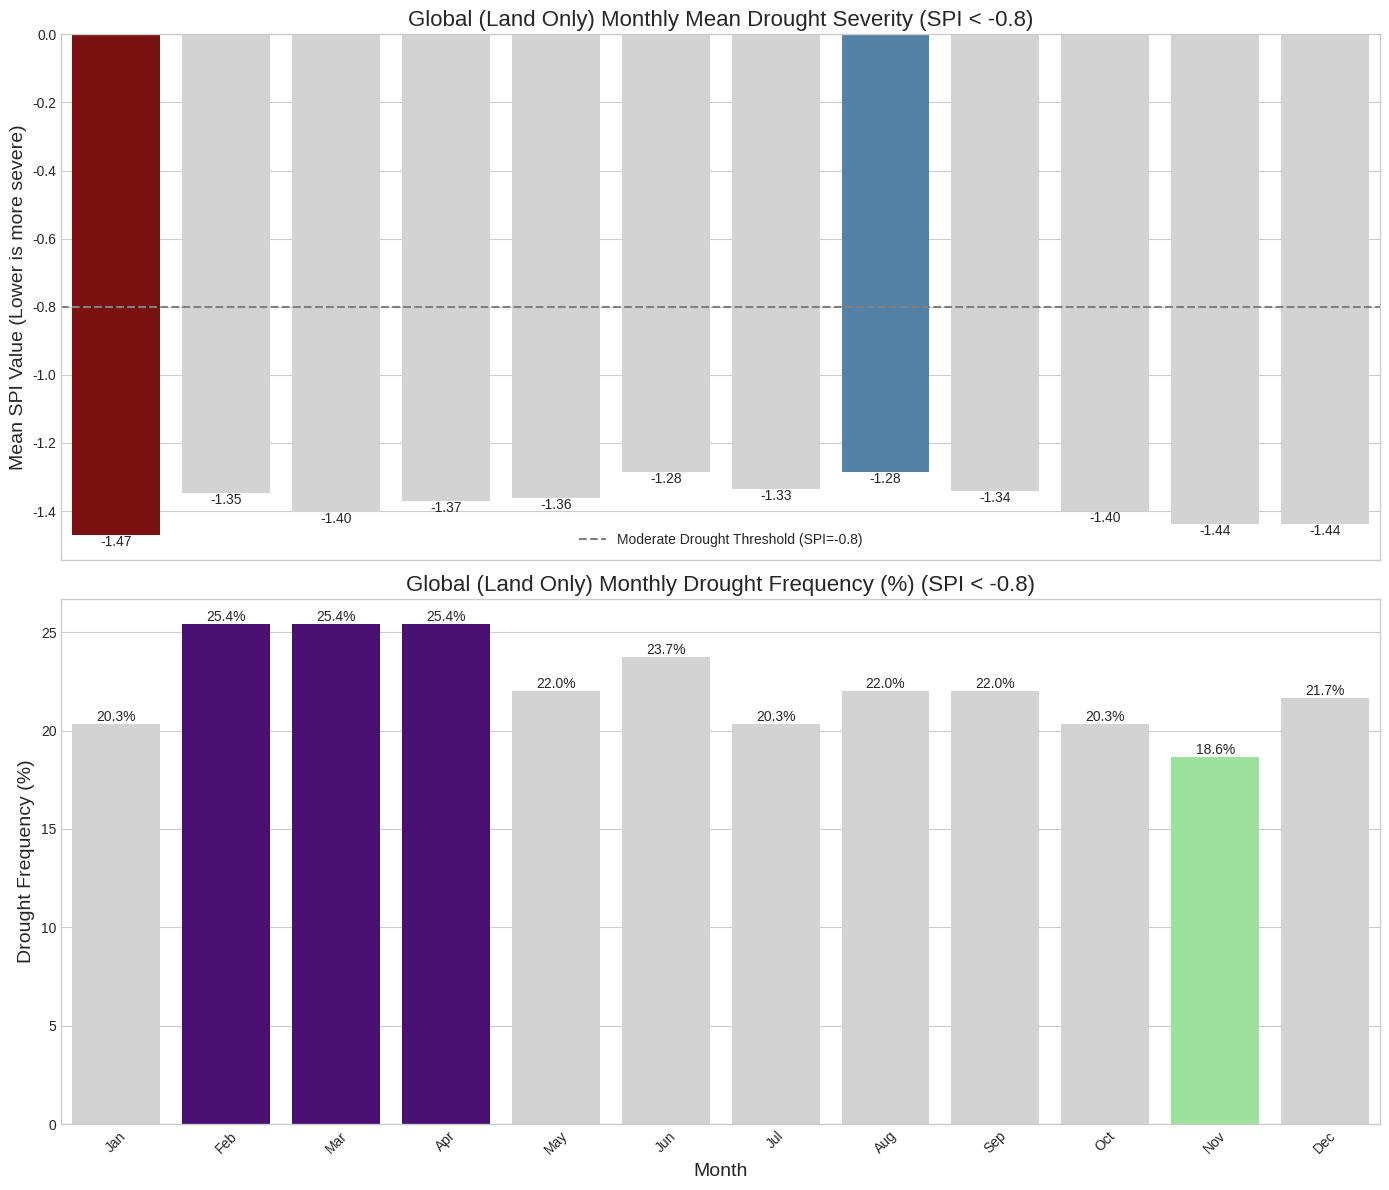

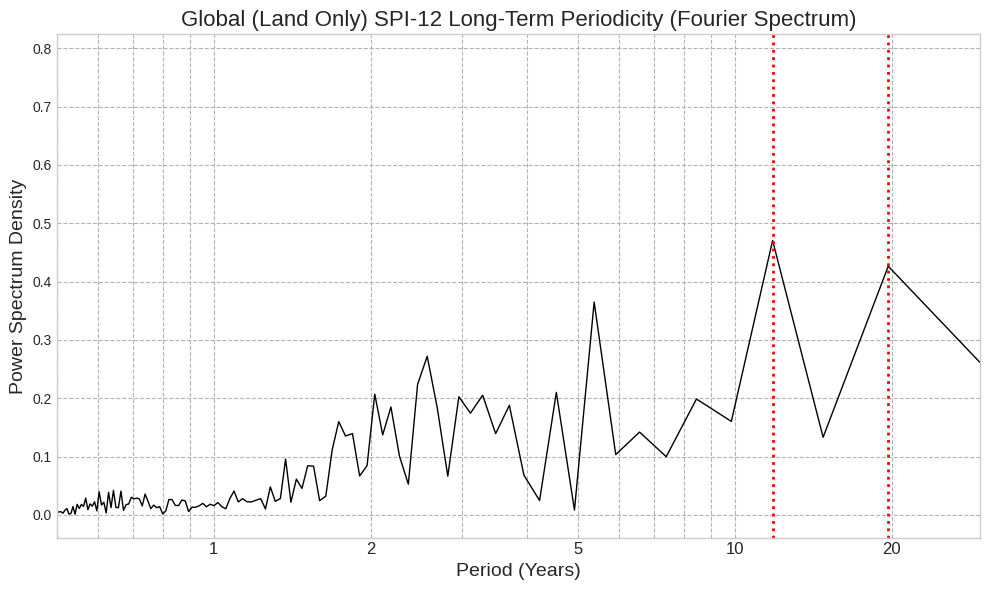

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
from scipy.stats import gamma, norm
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 환경 및 함수 설정 ---
# 파일 경로 (tp 및 lsm)
TP_FILE_PATH = '/content/drive/MyDrive/MIDTERM/ERA5_data/total_precipitation_ERA5_globe_1965-2024_regridded.nc'
#  'land_sea_mask_ERA5.nc' 파일을 사용합니다.
LSM_FILE_PATH = '/content/drive/MyDrive/MIDTERM/ERA5_data/land_sea_mask_ERA5.nc'

# SPI 계산 함수 (변화 없음)
def calculate_spi(data, scale):
    df_rolling = data.rolling(window=scale, min_periods=scale).sum()
    non_zero_data = df_rolling[df_rolling > 0].dropna()
    if non_zero_data.empty: return pd.Series(np.nan, index=data.index)
    params = gamma.fit(non_zero_data.values, loc=0)
    prob_zero = 1.0 - (non_zero_data.size / df_rolling.dropna().size)
    def cdf_func(x):
        if x > 0:
            return prob_zero + (1.0 - prob_zero) * gamma.cdf(x, *params)
        else:
            return prob_zero
    gamma_cdf = df_rolling.dropna().apply(cdf_func)
    spi = pd.Series(norm.ppf(np.clip(gamma_cdf.values, 1e-6, 1.0 - 1e-6)), index=gamma_cdf.index)
    return spi

# --- 2. 세계 (Global - Land Only) 분석 실행 ---
print(f">>> 1. Global (Land Only) SPI-12 Analysis Start (Drought Threshold: -0.8)...")
try:
    plt.rcParams['axes.unicode_minus'] = False
    plt.style.use('seaborn-v0_8-whitegrid')

    # 1. 데이터 로드 (tp 및 lsm)
    ds_tp = xr.open_dataset(TP_FILE_PATH)
    ds_lsm = xr.open_dataset(LSM_FILE_PATH)

    # 2. 마스크(lsm) 선택 (전 지구)
    da_global_lsm = ds_lsm['lsm'].squeeze()

    # 3. 마스크 적용 (해역 제외, lsm > 0.5)
    da_global_tp_m_day_land = ds_tp['tp'].where(da_global_lsm > 0.5)

    # 4. 공간 평균 (육지 격자만 평균)
    da_global_m_day = da_global_tp_m_day_land.mean(dim=['latitude', 'longitude'])

    # 5. 단위 변환: '일 평균 강수량 (m/day)' -> '월 총 강수량 (mm/month)'
    days_in_month = da_global_m_day.valid_time.dt.days_in_month
    monthly_precipitation_gl = (da_global_m_day * days_in_month * 1000.0).to_series()

    # 6. SPI-12 계산
    spi_12_gl = calculate_spi(monthly_precipitation_gl, scale=12)

    df_spi_gl = spi_12_gl.to_frame(name='SPI')
    df_spi_gl['Month'] = df_spi_gl.index.month
    drought_condition_gl = df_spi_gl['SPI'] < -0.8

    # --- 3. 분석 결과 출력 (영문) ---
    seasonal_severity_gl = df_spi_gl[drought_condition_gl].groupby('Month')['SPI'].mean()
    print("\n--- Global (Land Only) Monthly Mean Drought Severity (SPI < -0.8) ---")
    print(seasonal_severity_gl)

    total_months_gl = df_spi_gl.groupby('Month')['SPI'].count()
    drought_months_gl = df_spi_gl[drought_condition_gl].groupby('Month')['SPI'].count().fillna(0)
    seasonal_frequency_gl = (drought_months_gl / total_months_gl) * 100
    print("\n--- Global (Land Only) Monthly Drought Frequency (%) (SPI < -0.8) ---")
    print(seasonal_frequency_gl)

    data_for_fft_gl = spi_12_gl.dropna().values
    N_gl = len(data_for_fft_gl)
    if N_gl > 100:
        yf_gl = fft(data_for_fft_gl)
        xf_gl = fftfreq(N_gl, 1.0)[:N_gl//2]
        power_spectrum_gl = 2.0/N_gl * np.abs(yf_gl[0:N_gl//2])
        top_indices_gl = np.argsort(power_spectrum_gl)[-3:]
        # 주파수가 0인 경우(평균값 성분) 제외하고 상위 3개 찾기
        valid_indices = top_indices_gl[xf_gl[top_indices_gl] > 0]
        if len(valid_indices) > 0:
            top_periods_months_gl = 1 / xf_gl[valid_indices]
            print("\n--- Global (Land Only) SPI-12 Significant Long-Term Periods (Years) ---")
            for period in sorted(top_periods_months_gl, reverse=True):
                print(f"Period: {period:.1f} months (approx. {period/12:.1f} years)")
        else:
             print("\nWarning: No significant periodicities found after excluding the mean.")
             top_periods_months_gl = []
    else:
        print("\nWarning: Not enough valid data for periodicity analysis.")
        top_periods_months_gl = []

except Exception as e:
    print(f"\nAn exception occurred during Global (Land Only) analysis: {e}")

# --- 4. 시각화 (Visualization - English, Extremes Highlighted) ---
# (이하 시각화 코드 동일)
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
severity_data = seasonal_severity_gl.map(lambda x: x).rename(index=month_names)
frequency_data = seasonal_frequency_gl.map(lambda x: x).rename(index=month_names)
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# 심도 그래프
sev_min_val = severity_data.min()
sev_max_val = severity_data.max()
sev_colors = ['darkred' if v == sev_min_val else 'steelblue' if v == sev_max_val else 'lightgray' for v in severity_data]
ax1 = sns.barplot(x=severity_data.index, y=severity_data.values, palette=sev_colors, ax=axes[0], hue=severity_data.index, legend=False)
axes[0].set_title('Global (Land Only) Monthly Mean Drought Severity (SPI < -0.8)', fontsize=16)
axes[0].set_ylabel('Mean SPI Value (Lower is more severe)', fontsize=14)
axes[0].axhline(y=-0.8, color='gray', linestyle='--', linewidth=1.5, label='Moderate Drought Threshold (SPI=-0.8)')
axes[0].legend()
for container in ax1.containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=10)

# 빈도 그래프
freq_max_val = frequency_data.max()
freq_min_val = frequency_data.min()
freq_colors = ['indigo' if v == freq_max_val else 'lightgreen' if v == freq_min_val else 'lightgray' for v in frequency_data]
ax2 = sns.barplot(x=frequency_data.index, y=frequency_data.values, palette=freq_colors, ax=axes[1], hue=frequency_data.index, legend=False)
axes[1].set_title('Global (Land Only) Monthly Drought Frequency (%) (SPI < -0.8)', fontsize=16)
axes[1].set_ylabel('Drought Frequency (%)', fontsize=14)
axes[1].set_xlabel('Month', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
for container in ax2.containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=10)

plt.tight_layout()
plt.show()

# 주기성 시각화
if N_gl > 100 and len(top_periods_months_gl) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(1/xf_gl[xf_gl > 0]/12, power_spectrum_gl[xf_gl > 0], color='black', linewidth=1)
    plt.xscale('log')
    plt.xticks(ticks=[1, 2, 5, 10, 20, 50], labels=[1, 2, 5, 10, 20, 50], fontsize=12)
    plt.xlabel('Period (Years)', fontsize=14)
    plt.ylabel('Power Spectrum Density', fontsize=14)
    plt.title('Global (Land Only) SPI-12 Long-Term Periodicity (Fourier Spectrum)', fontsize=16)
    plt.grid(True, which="both", ls="--", c='0.7')
    for period_month in top_periods_months_gl:
        period_year = period_month / 12
        plt.axvline(period_year, color='red', linestyle=':', linewidth=2)
    plt.xlim(0.5, N_gl/12/2)
    plt.tight_layout()
    plt.show()
else:
    print("\n**Periodicity analysis visualization skipped due to insufficient valid data or no significant periods found.**")

>>> 2. East Asia (Land Only) [75°-150°E, 15°-60°N] SPI-12 Analysis Start (Drought Threshold: -0.8)...

--- East Asia (Land Only) Monthly Mean Drought Severity (SPI < -0.8) ---
Month
1    -1.313961
2    -1.296339
3    -1.369609
4    -1.250271
5    -1.213908
6    -1.278241
7    -1.319127
8    -1.420911
9    -1.366449
10   -1.363554
11   -1.385108
12   -1.421221
Name: SPI, dtype: float64

--- East Asia (Land Only) Monthly Drought Frequency (%) (SPI < -0.8) ---
Month
1     25.423729
2     27.118644
3     22.033898
4     23.728814
5     25.423729
6     22.033898
7     23.728814
8     18.644068
9     22.033898
10    25.423729
11    25.423729
12    23.333333
Name: SPI, dtype: float64

--- East Asia (Land Only) SPI-12 Significant Long-Term Periods (Years) ---
Period: 709.0 months (approx. 59.1 years)
Period: 354.5 months (approx. 29.5 years)
Period: 54.5 months (approx. 4.5 years)


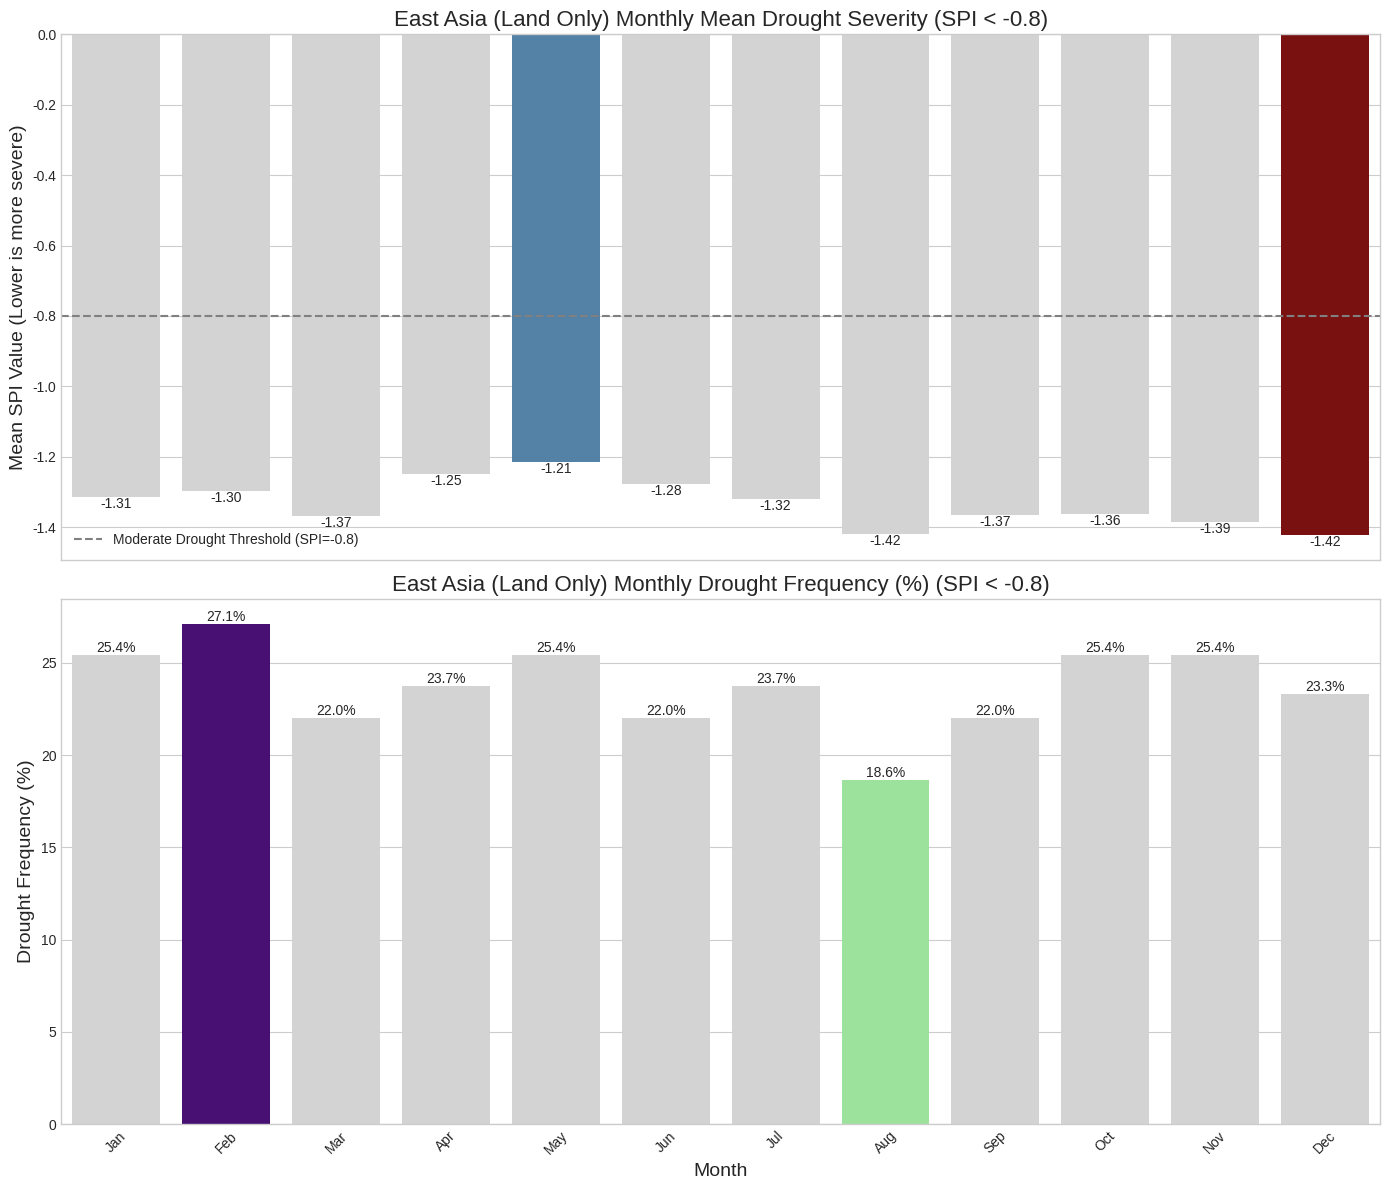

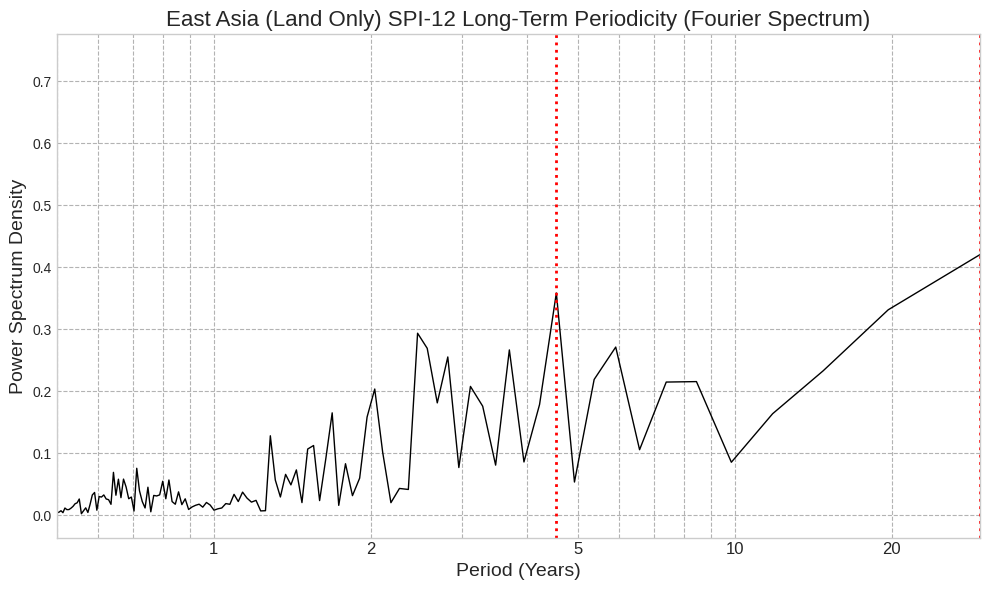

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
from scipy.stats import gamma, norm
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 환경 및 함수 설정 ---
# 파일 경로 (tp 및 lsm)
TP_FILE_PATH = '/content/drive/MyDrive/MIDTERM/ERA5_data/total_precipitation_ERA5_globe_1965-2024_regridded.nc'
LSM_FILE_PATH = '/content/drive/MyDrive/MIDTERM/ERA5_data/land_sea_mask_ERA5.nc'
# 동아시아 경계 설정
LON_MIN_EA, LON_MAX_EA = 75, 150
LAT_MIN_EA, LAT_MAX_EA = 15, 60

# SPI 계산 함수 (변화 없음)
def calculate_spi(data, scale):
    df_rolling = data.rolling(window=scale, min_periods=scale).sum()
    non_zero_data = df_rolling[df_rolling > 0].dropna()
    if non_zero_data.empty: return pd.Series(np.nan, index=data.index)
    params = gamma.fit(non_zero_data.values, loc=0)
    prob_zero = 1.0 - (non_zero_data.size / df_rolling.dropna().size)
    def cdf_func(x):
        if x > 0:
            return prob_zero + (1.0 - prob_zero) * gamma.cdf(x, *params)
        else:
            return prob_zero
    gamma_cdf = df_rolling.dropna().apply(cdf_func)
    spi = pd.Series(norm.ppf(np.clip(gamma_cdf.values, 1e-6, 1.0 - 1e-6)), index=gamma_cdf.index)
    return spi

# --- 2. 동아시아 (East Asia - Land Only) 분석 실행 ---
print(f">>> 2. East Asia (Land Only) [{LON_MIN_EA}°-{LON_MAX_EA}°E, {LAT_MIN_EA}°-{LAT_MAX_EA}°N] SPI-12 Analysis Start (Drought Threshold: -0.8)...")
try:
    plt.rcParams['axes.unicode_minus'] = False
    plt.style.use('seaborn-v0_8-whitegrid')

    # 1. 데이터 로드 (tp 및 lsm)
    ds_tp = xr.open_dataset(TP_FILE_PATH)
    ds_lsm = xr.open_dataset(LSM_FILE_PATH)

    # 2. 지역 선택 (tp)
    da_east_asia_tp_m_day_full = ds_tp['tp'].sel(
        longitude=slice(LON_MIN_EA, LON_MAX_EA),
        latitude=slice(LAT_MAX_EA, LAT_MIN_EA) # [60, 15]
    )

    # 3. 마스크(lsm) 선택
    da_east_asia_lsm = ds_lsm['lsm'].sel(
        longitude=slice(LON_MIN_EA, LON_MAX_EA),
        latitude=slice(LAT_MAX_EA, LAT_MIN_EA)
    ).squeeze()

    # 4. 마스크 적용 (해역 제외, lsm > 0.5)
    da_east_asia_tp_m_day_land = da_east_asia_tp_m_day_full.where(da_east_asia_lsm > 0.5)

    # 5. 공간 평균 (육지 격자만 평균)
    da_east_asia_m_day = da_east_asia_tp_m_day_land.mean(dim=['latitude', 'longitude'])

    # 6. 단위 변환: '일 평균 강수량 (m/day)' -> '월 총 강수량 (mm/month)'
    days_in_month = da_east_asia_m_day.valid_time.dt.days_in_month
    monthly_precipitation_ea = (da_east_asia_m_day * days_in_month * 1000.0).to_series()

    # 7. SPI-12 계산
    spi_12_ea = calculate_spi(monthly_precipitation_ea, scale=12)

    df_spi_ea = spi_12_ea.to_frame(name='SPI')
    df_spi_ea['Month'] = df_spi_ea.index.month
    drought_condition_ea = df_spi_ea['SPI'] < -0.8

    # --- 3. 분석 결과 출력 (영문) ---
    seasonal_severity_ea = df_spi_ea[drought_condition_ea].groupby('Month')['SPI'].mean()
    print("\n--- East Asia (Land Only) Monthly Mean Drought Severity (SPI < -0.8) ---")
    print(seasonal_severity_ea)

    total_months_ea = df_spi_ea.groupby('Month')['SPI'].count()
    drought_months_ea = df_spi_ea[drought_condition_ea].groupby('Month')['SPI'].count().fillna(0)
    seasonal_frequency_ea = (drought_months_ea / total_months_ea) * 100
    print("\n--- East Asia (Land Only) Monthly Drought Frequency (%) (SPI < -0.8) ---")
    print(seasonal_frequency_ea)

    data_for_fft_ea = spi_12_ea.dropna().values
    N_ea = len(data_for_fft_ea)
    if N_ea > 100:
        yf_ea = fft(data_for_fft_ea)
        xf_ea = fftfreq(N_ea, 1.0)[:N_ea//2]
        power_spectrum_ea = 2.0/N_ea * np.abs(yf_ea[0:N_ea//2])
        top_indices_ea = np.argsort(power_spectrum_ea)[-3:]
        # 주파수가 0인 경우(평균값 성분) 제외하고 상위 3개 찾기
        valid_indices = top_indices_ea[xf_ea[top_indices_ea] > 0]
        if len(valid_indices) > 0:
            top_periods_months_ea = 1 / xf_ea[valid_indices]
            print("\n--- East Asia (Land Only) SPI-12 Significant Long-Term Periods (Years) ---")
            for period in sorted(top_periods_months_ea, reverse=True):
                print(f"Period: {period:.1f} months (approx. {period/12:.1f} years)")
        else:
             print("\nWarning: No significant periodicities found after excluding the mean.")
             top_periods_months_ea = []
    else:
        print("\nWarning: Not enough valid data for periodicity analysis.")
        top_periods_months_ea = []

except Exception as e:
    print(f"\nAn exception occurred during East Asia (Land Only) analysis: {e}")

# --- 4. 시각화 (Visualization - English, Extremes Highlighted) ---
# (이하 시각화 코드 동일, 제목만 변경)
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
severity_data = seasonal_severity_ea.map(lambda x: x).rename(index=month_names)
frequency_data = seasonal_frequency_ea.map(lambda x: x).rename(index=month_names)
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# 심도 그래프
sev_min_val = severity_data.min()
sev_max_val = severity_data.max()
sev_colors = ['darkred' if v == sev_min_val else 'steelblue' if v == sev_max_val else 'lightgray' for v in severity_data]
ax1 = sns.barplot(x=severity_data.index, y=severity_data.values, palette=sev_colors, ax=axes[0], hue=severity_data.index, legend=False)
axes[0].set_title('East Asia (Land Only) Monthly Mean Drought Severity (SPI < -0.8)', fontsize=16) # 제목 변경
axes[0].set_ylabel('Mean SPI Value (Lower is more severe)', fontsize=14)
axes[0].axhline(y=-0.8, color='gray', linestyle='--', linewidth=1.5, label='Moderate Drought Threshold (SPI=-0.8)')
axes[0].legend()
for container in ax1.containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=10)

# 빈도 그래프
freq_max_val = frequency_data.max()
freq_min_val = frequency_data.min()
freq_colors = ['indigo' if v == freq_max_val else 'lightgreen' if v == freq_min_val else 'lightgray' for v in frequency_data]
ax2 = sns.barplot(x=frequency_data.index, y=frequency_data.values, palette=freq_colors, ax=axes[1], hue=frequency_data.index, legend=False)
axes[1].set_title('East Asia (Land Only) Monthly Drought Frequency (%) (SPI < -0.8)', fontsize=16) # 제목 변경
axes[1].set_ylabel('Drought Frequency (%)', fontsize=14)
axes[1].set_xlabel('Month', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
for container in ax2.containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=10)

plt.tight_layout()
plt.show()

# 주기성 시각화
if N_ea > 100 and len(top_periods_months_ea) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(1/xf_ea[xf_ea > 0]/12, power_spectrum_ea[xf_ea > 0], color='black', linewidth=1)
    plt.xscale('log')
    plt.xticks(ticks=[1, 2, 5, 10, 20, 50], labels=[1, 2, 5, 10, 20, 50], fontsize=12)
    plt.xlabel('Period (Years)', fontsize=14)
    plt.ylabel('Power Spectrum Density', fontsize=14)
    plt.title('East Asia (Land Only) SPI-12 Long-Term Periodicity (Fourier Spectrum)', fontsize=16) # 제목 변경
    plt.grid(True, which="both", ls="--", c='0.7')
    for period_month in top_periods_months_ea:
        period_year = period_month / 12
        plt.axvline(period_year, color='red', linestyle=':', linewidth=2)
    plt.xlim(0.5, N_ea/12/2)
    plt.tight_layout()
    plt.show()
else:
    print("\n**Periodicity analysis visualization skipped due to insufficient valid data or no significant periods found.**")

>>> 3. South Korea (Land Only) [125.06°-131.88°E, 33.11°-38.45°N] SPI-12 Analysis Start (Drought Threshold: -0.8)...

--- South Korea (Land Only) Monthly Mean Drought Severity (SPI < -0.8) ---
Month
1    -1.318140
2    -1.402666
3    -1.263626
4    -1.353122
5    -1.344304
6    -1.495826
7    -1.377377
8    -1.133254
9    -1.267241
10   -1.330131
11   -1.372419
12   -1.382947
Name: SPI, dtype: float64

--- South Korea (Land Only) Monthly Drought Frequency (%) (SPI < -0.8) ---
Month
1     25.423729
2     20.338983
3     27.118644
4     23.728814
5     23.728814
6     20.338983
7     16.949153
8     20.338983
9     23.728814
10    22.033898
11    23.728814
12    23.333333
Name: SPI, dtype: float64

--- South Korea (Land Only) SPI-12 Significant Long-Term Periods (Years) ---
Period: 709.0 months (approx. 59.1 years)
Period: 118.2 months (approx. 9.8 years)
Period: 78.8 months (approx. 6.6 years)


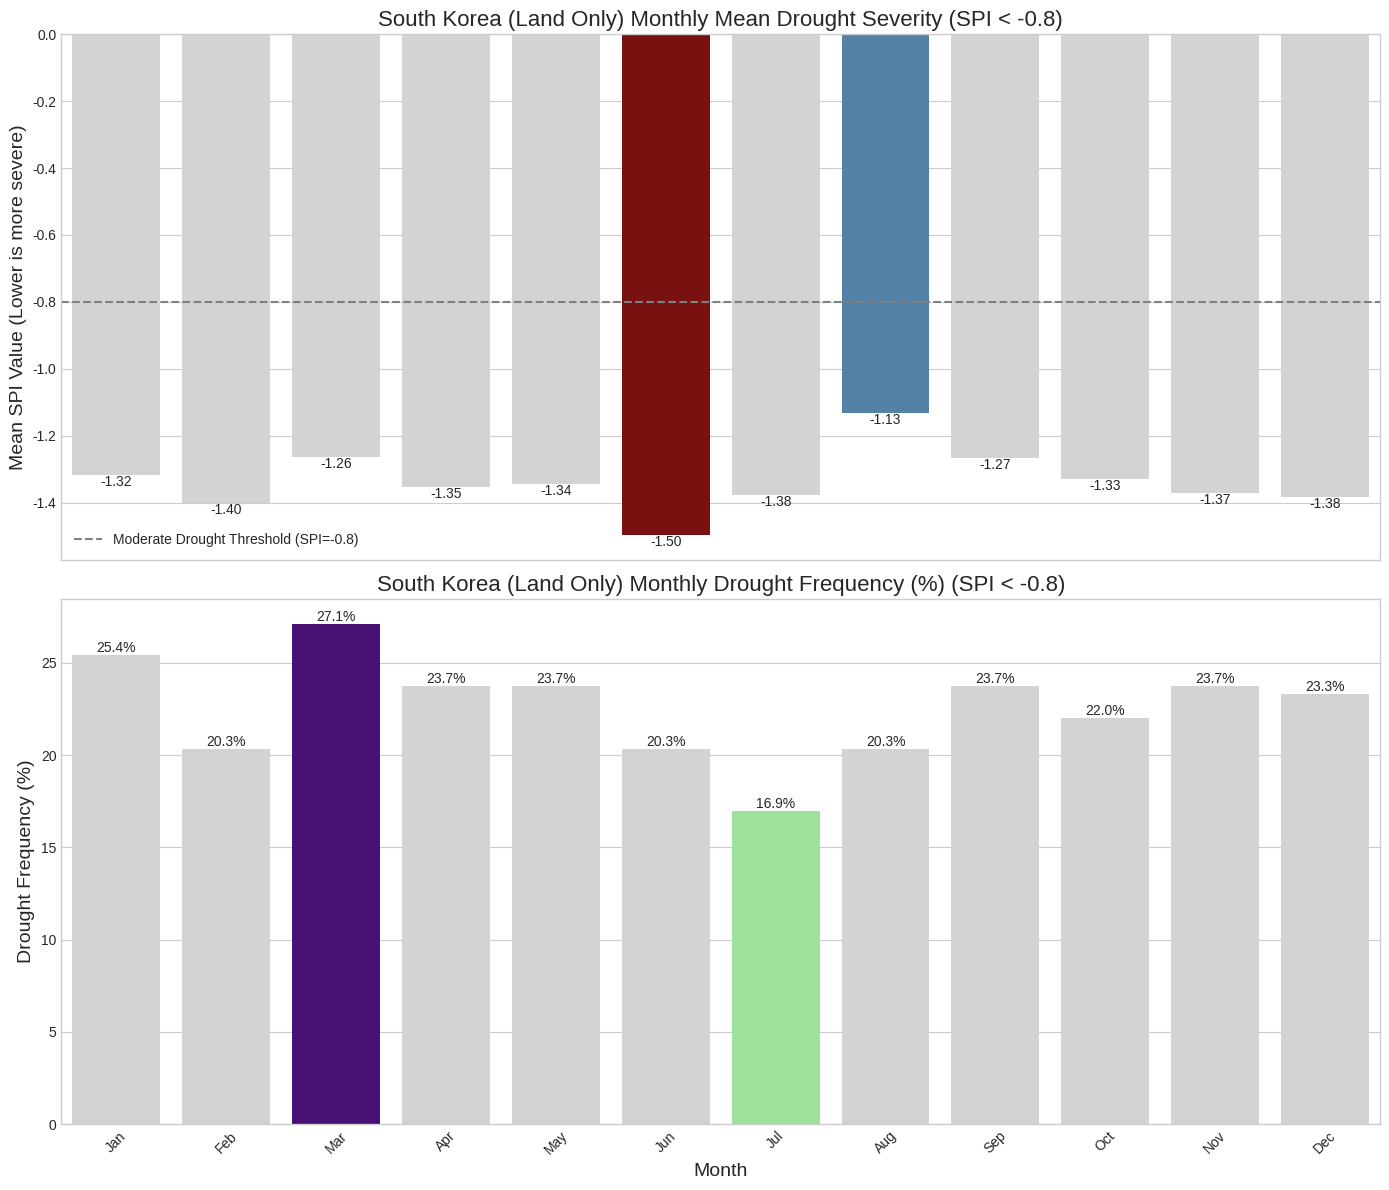

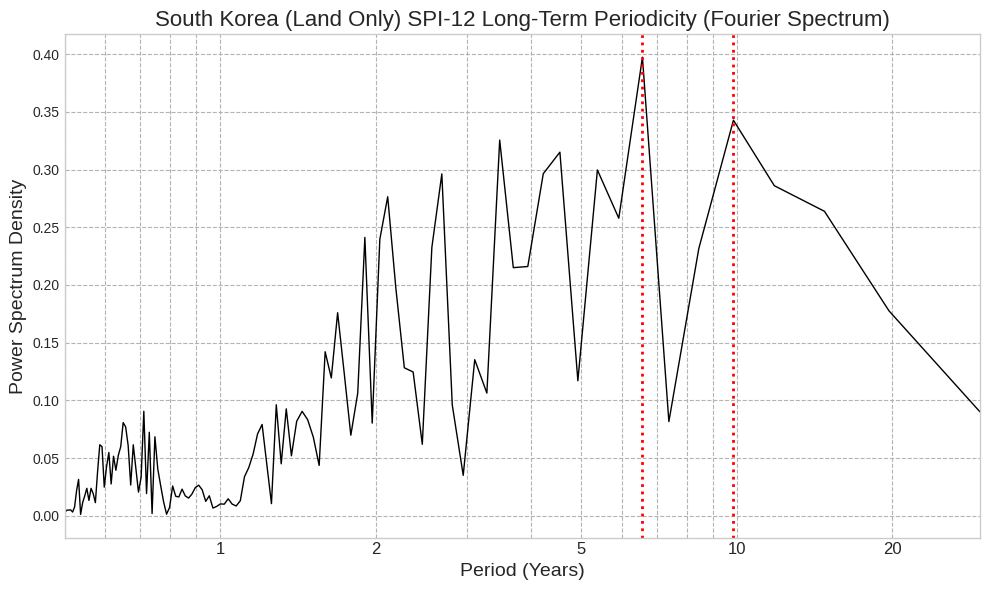

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
from scipy.stats import gamma, norm
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 환경 및 함수 설정 ---
# 파일 경로 (tp 및 lsm)
TP_FILE_PATH = '/content/drive/MyDrive/MIDTERM/ERA5_data/total_precipitation_ERA5_globe_1965-2024_regridded.nc'
LSM_FILE_PATH = '/content/drive/MyDrive/MIDTERM/ERA5_data/land_sea_mask_ERA5.nc'
# 남한 지역 경계 (십진수 변환)
LON_MIN_KR, LON_MAX_KR = 125.06, 131.88
LAT_MIN_KR, LAT_MAX_KR = 33.11, 38.45

# SPI 계산 함수 (변화 없음)
def calculate_spi(data, scale):
    df_rolling = data.rolling(window=scale, min_periods=scale).sum()
    non_zero_data = df_rolling[df_rolling > 0].dropna()
    if non_zero_data.empty: return pd.Series(np.nan, index=data.index)
    params = gamma.fit(non_zero_data.values, loc=0)
    prob_zero = 1.0 - (non_zero_data.size / df_rolling.dropna().size)
    def cdf_func(x):
        if x > 0:
            return prob_zero + (1.0 - prob_zero) * gamma.cdf(x, *params)
        else:
            return prob_zero
    gamma_cdf = df_rolling.dropna().apply(cdf_func)
    spi = pd.Series(norm.ppf(np.clip(gamma_cdf.values, 1e-6, 1.0 - 1e-6)), index=gamma_cdf.index)
    return spi

# --- 2. 남한 (South Korea - Land Only) 분석 실행 ---
print(f">>> 3. South Korea (Land Only) [{LON_MIN_KR}°-{LON_MAX_KR}°E, {LAT_MIN_KR}°-{LAT_MAX_KR}°N] SPI-12 Analysis Start (Drought Threshold: -0.8)...")
try:
    plt.rcParams['axes.unicode_minus'] = False
    plt.style.use('seaborn-v0_8-whitegrid')

    # 1. 데이터 로드 (tp 및 lsm)
    ds_tp = xr.open_dataset(TP_FILE_PATH)
    ds_lsm = xr.open_dataset(LSM_FILE_PATH)

    # 2. 지역 선택 (tp)
    da_korea_tp_m_day_full = ds_tp['tp'].sel(
        longitude=slice(LON_MIN_KR, LON_MAX_KR),
        latitude=slice(LAT_MAX_KR, LAT_MIN_KR) # [38.45, 33.11]
    )

    # 3. 마스크(lsm) 선택
    da_korea_lsm = ds_lsm['lsm'].sel(
        longitude=slice(LON_MIN_KR, LON_MAX_KR),
        latitude=slice(LAT_MAX_KR, LAT_MIN_KR)
    ).squeeze()

    # 4. 마스크 적용 (해역 제외, lsm > 0.5)
    da_korea_tp_m_day_land = da_korea_tp_m_day_full.where(da_korea_lsm > 0.5)

    # 5. 공간 평균 (육지 격자만 평균)
    da_korea_m_day = da_korea_tp_m_day_land.mean(dim=['latitude', 'longitude'])

    # 6. 단위 변환: '일 평균 강수량 (m/day)' -> '월 총 강수량 (mm/month)'
    days_in_month = da_korea_m_day.valid_time.dt.days_in_month
    monthly_precipitation_kr = (da_korea_m_day * days_in_month * 1000.0).to_series()

    # 7. SPI-12 계산
    spi_12_kr = calculate_spi(monthly_precipitation_kr, scale=12)

    df_spi_kr = spi_12_kr.to_frame(name='SPI')
    df_spi_kr['Month'] = df_spi_kr.index.month
    drought_condition_kr = df_spi_kr['SPI'] < -0.8

    # --- 3. 분석 결과 출력 (영문) ---
    seasonal_severity_kr = df_spi_kr[drought_condition_kr].groupby('Month')['SPI'].mean()
    print("\n--- South Korea (Land Only) Monthly Mean Drought Severity (SPI < -0.8) ---")
    print(seasonal_severity_kr)

    total_months_kr = df_spi_kr.groupby('Month')['SPI'].count()
    drought_months_kr = df_spi_kr[drought_condition_kr].groupby('Month')['SPI'].count().fillna(0)
    seasonal_frequency_kr = (drought_months_kr / total_months_kr) * 100
    print("\n--- South Korea (Land Only) Monthly Drought Frequency (%) (SPI < -0.8) ---")
    print(seasonal_frequency_kr)

    data_for_fft_kr = spi_12_kr.dropna().values
    N_kr = len(data_for_fft_kr)
    if N_kr > 100:
        yf_kr = fft(data_for_fft_kr)
        xf_kr = fftfreq(N_kr, 1.0)[:N_kr//2]
        power_spectrum_kr = 2.0/N_kr * np.abs(yf_kr[0:N_kr//2])
        top_indices_kr = np.argsort(power_spectrum_kr)[-3:]
        # 주파수가 0인 경우(평균값 성분) 제외하고 상위 3개 찾기
        valid_indices = top_indices_kr[xf_kr[top_indices_kr] > 0]
        if len(valid_indices) > 0:
            top_periods_months_kr = 1 / xf_kr[valid_indices]
            print("\n--- South Korea (Land Only) SPI-12 Significant Long-Term Periods (Years) ---")
            for period in sorted(top_periods_months_kr, reverse=True):
                print(f"Period: {period:.1f} months (approx. {period/12:.1f} years)")
        else:
             print("\nWarning: No significant periodicities found after excluding the mean.")
             top_periods_months_kr = []
    else:
        print("\nWarning: Not enough valid data for periodicity analysis.")
        top_periods_months_kr = []

except Exception as e:
    print(f"\nAn exception occurred during South Korea (Land Only) analysis: {e}")

# --- 4. 시각화 (Visualization - English, Extremes Highlighted) ---
# (이하 시각화 코드 동일)
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
severity_data = seasonal_severity_kr.map(lambda x: x).rename(index=month_names)
frequency_data = seasonal_frequency_kr.map(lambda x: x).rename(index=month_names)
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# 심도 그래프
sev_min_val = severity_data.min()
sev_max_val = severity_data.max()
sev_colors = ['darkred' if v == sev_min_val else 'steelblue' if v == sev_max_val else 'lightgray' for v in severity_data]
ax1 = sns.barplot(x=severity_data.index, y=severity_data.values, palette=sev_colors, ax=axes[0], hue=severity_data.index, legend=False)
axes[0].set_title('South Korea (Land Only) Monthly Mean Drought Severity (SPI < -0.8)', fontsize=16)
axes[0].set_ylabel('Mean SPI Value (Lower is more severe)', fontsize=14)
axes[0].axhline(y=-0.8, color='gray', linestyle='--', linewidth=1.5, label='Moderate Drought Threshold (SPI=-0.8)')
axes[0].legend()
for container in ax1.containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=10)

# 빈도 그래프
freq_max_val = frequency_data.max()
freq_min_val = frequency_data.min()
freq_colors = ['indigo' if v == freq_max_val else 'lightgreen' if v == freq_min_val else 'lightgray' for v in frequency_data]
ax2 = sns.barplot(x=frequency_data.index, y=frequency_data.values, palette=freq_colors, ax=axes[1], hue=frequency_data.index, legend=False)
axes[1].set_title('South Korea (Land Only) Monthly Drought Frequency (%) (SPI < -0.8)', fontsize=16)
axes[1].set_ylabel('Drought Frequency (%)', fontsize=14)
axes[1].set_xlabel('Month', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
for container in ax2.containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=10)

plt.tight_layout()
plt.show()

# 주기성 시각화
if N_kr > 100 and len(top_periods_months_kr) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(1/xf_kr[xf_kr > 0]/12, power_spectrum_kr[xf_kr > 0], color='black', linewidth=1)
    plt.xscale('log')
    plt.xticks(ticks=[1, 2, 5, 10, 20, 50], labels=[1, 2, 5, 10, 20, 50], fontsize=12)
    plt.xlabel('Period (Years)', fontsize=14)
    plt.ylabel('Power Spectrum Density', fontsize=14)
    plt.title('South Korea (Land Only) SPI-12 Long-Term Periodicity (Fourier Spectrum)', fontsize=16)
    plt.grid(True, which="both", ls="--", c='0.7')
    for period_month in top_periods_months_kr:
        period_year = period_month / 12
        plt.axvline(period_year, color='red', linestyle=':', linewidth=2)
    plt.xlim(0.5, N_kr/12/2)
    plt.tight_layout()
    plt.show()
else:
    print("\n**Periodicity analysis visualization skipped due to insufficient valid data or no significant periods found.**")

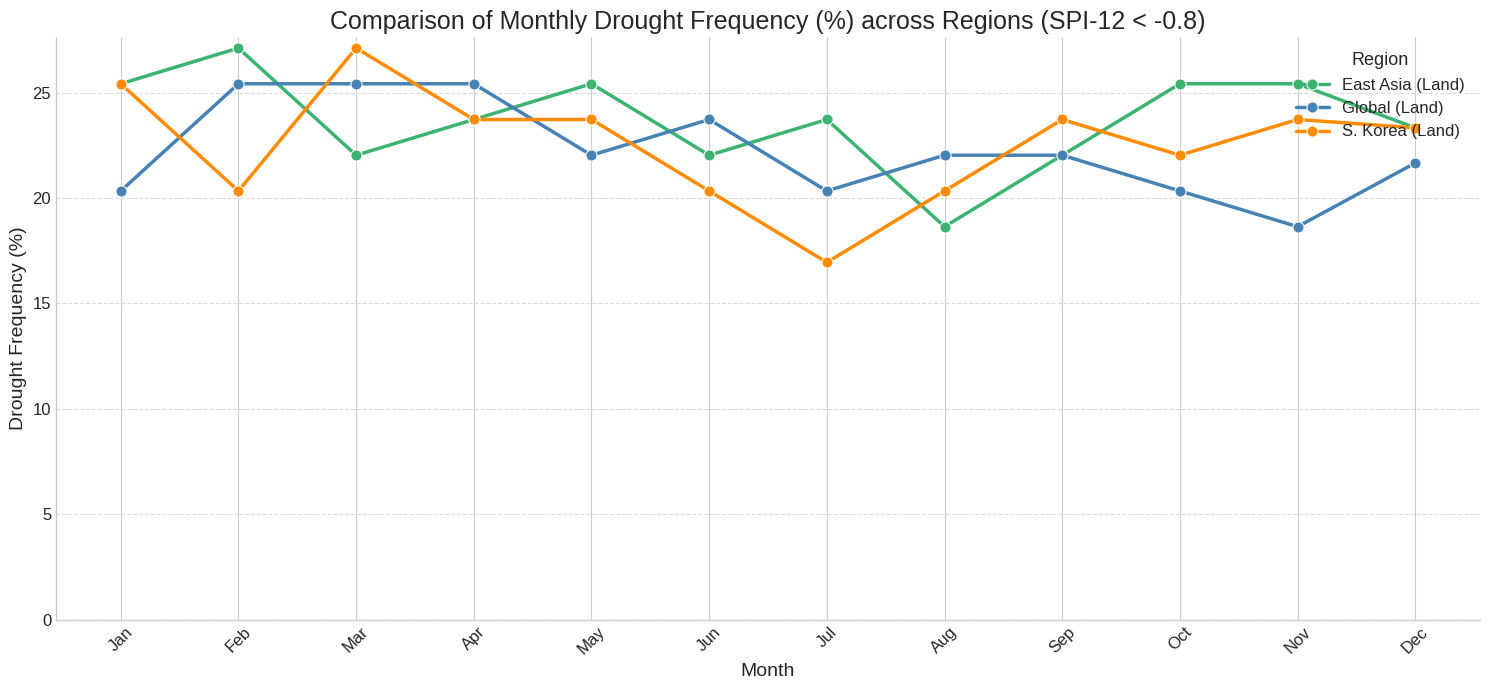

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 이전 단계에서 계산된 결과 변수 로드 가정 ---
# spi_12_gl, spi_12_ea, spi_12_kr 변수가 메모리에 있다고 가정합니다.

try:
    # (데이터 준비 코드는 이전과 동일)
    df_spi_gl = spi_12_gl.to_frame(name='SPI')
    df_spi_gl['Month'] = df_spi_gl.index.month
    df_spi_gl['Region'] = 'Global (Land)'

    df_spi_ea = spi_12_ea.to_frame(name='SPI')
    df_spi_ea['Month'] = df_spi_ea.index.month
    df_spi_ea['Region'] = 'East Asia (Land)'

    df_spi_kr = spi_12_kr.to_frame(name='SPI')
    df_spi_kr['Month'] = df_spi_kr.index.month
    df_spi_kr['Region'] = 'S. Korea (Land)'

    df_spi_combined = pd.concat([df_spi_gl, df_spi_ea, df_spi_kr], ignore_index=False)
    drought_condition = df_spi_combined['SPI'] < -0.8

    total_months_by_region = df_spi_combined.groupby(['Region', 'Month'])['SPI'].count()
    drought_months_by_region = df_spi_combined[drought_condition].groupby(['Region', 'Month'])['SPI'].count().fillna(0)

    seasonal_frequency_combined = (drought_months_by_region / total_months_by_region).unstack(level='Region') * 100
    seasonal_frequency_combined = seasonal_frequency_combined.fillna(0)

    df_plot = seasonal_frequency_combined.reset_index().melt(id_vars='Month', var_name='Region', value_name='Frequency')

    # 월 이름을 영문 약자로 변경 (순서 유지를 위해 필요)
    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    df_plot['Month_Num'] = df_plot['Month'] # 정렬을 위해 숫자 월 유지
    df_plot['Month'] = df_plot['Month'].map(month_names)
    df_plot = df_plot.sort_values(by='Month_Num') # 월 순서대로 정렬


except NameError as e:
    print(f"오류: {e}. 이전 단계의 SPI 변수(spi_12_gl, spi_12_ea, spi_12_kr)가 정의되지 않았습니다.")
    exit()
except Exception as e:
    print(f"데이터 준비 중 오류 발생: {e}")
    exit()

# --- 3. 시각화 (Line Plot - 눈이 편한 색상) ---

# !!! 색상 지정: 눈이 편한 색상 조합 !!!
custom_palette = {
    'Global (Land)': 'steelblue',      # 차분한 파란색
    'East Asia (Land)': 'mediumseagreen', # 중간 녹색
    'S. Korea (Land)': 'darkorange'       # 어두운 주황색
}

plt.figure(figsize=(15, 7))
# !!! lineplot 사용 !!!
ax = sns.lineplot(data=df_plot, x='Month', y='Frequency', hue='Region', palette=custom_palette,
                  marker='o', markersize=8, linewidth=2.5) # 마커와 선 굵기 추가

# 스타일 및 레이블 설정
ax.set_title('Comparison of Monthly Drought Frequency (%) across Regions (SPI-12 < -0.8)', fontsize=18)
ax.set_ylabel('Drought Frequency (%)', fontsize=14)
ax.set_xlabel('Month', fontsize=14)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Region', title_fontsize='13', fontsize='12', loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
# Y축 범위를 0부터 시작하도록 설정
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

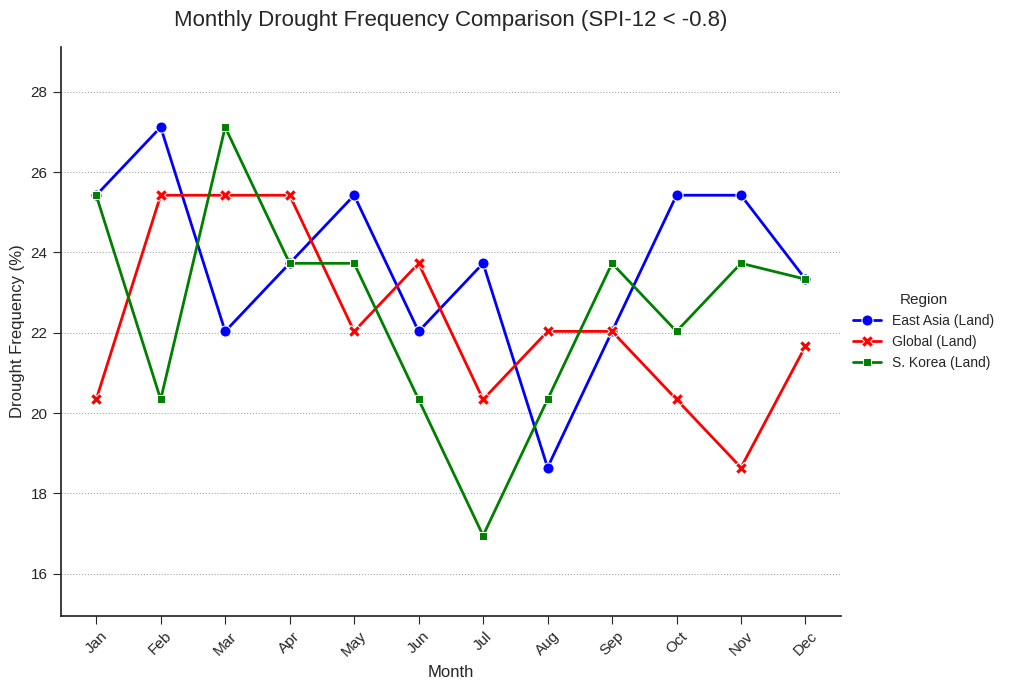

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 이전 단계에서 계산된 결과 변수 로드 가정 ---
# spi_12_gl, spi_12_ea, spi_12_kr 변수가 메모리에 있다고 가정합니다.

try:
    # (데이터 준비 코드는 이전과 동일)
    df_spi_gl = spi_12_gl.to_frame(name='SPI')
    df_spi_gl['Month'] = df_spi_gl.index.month
    df_spi_gl['Region'] = 'Global (Land)'

    df_spi_ea = spi_12_ea.to_frame(name='SPI')
    df_spi_ea['Month'] = df_spi_ea.index.month
    df_spi_ea['Region'] = 'East Asia (Land)'

    df_spi_kr = spi_12_kr.to_frame(name='SPI')
    df_spi_kr['Month'] = df_spi_kr.index.month
    df_spi_kr['Region'] = 'S. Korea (Land)'

    df_spi_combined = pd.concat([df_spi_gl, df_spi_ea, df_spi_kr], ignore_index=False)
    drought_condition = df_spi_combined['SPI'] < -0.8

    total_months_by_region = df_spi_combined.groupby(['Region', 'Month'])['SPI'].count()
    drought_months_by_region = df_spi_combined[drought_condition].groupby(['Region', 'Month'])['SPI'].count().fillna(0)

    seasonal_frequency_combined = (drought_months_by_region / total_months_by_region).unstack(level='Region') * 100
    seasonal_frequency_combined = seasonal_frequency_combined.fillna(0)

    df_plot = seasonal_frequency_combined.reset_index().melt(id_vars='Month', var_name='Region', value_name='Frequency')

    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    df_plot['Month_Num'] = df_plot['Month']
    df_plot['Month'] = df_plot['Month'].map(month_names)
    df_plot = df_plot.sort_values(by='Month_Num')

except NameError as e:
    print(f"Error: {e}. Required SPI variables (spi_12_gl, spi_12_ea, spi_12_kr) are not defined.")
    exit()
except Exception as e:
    print(f"Error during data preparation: {e}")
    exit()

# --- 3. 시각화 (Line Plot - 요청 색상 및 Y축 조정) ---

# !!! 색상 지정: 빨강, 파랑, 초록 !!!
custom_palette = {
    'Global (Land)': 'red',
    'East Asia (Land)': 'blue',
    'S. Korea (Land)': 'green' # <-- 초록색으로 변경
}

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-ticks')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 7)) # 크기 조정
ax = sns.lineplot(
    data=df_plot, x='Month', y='Frequency',
    hue='Region', style='Region', # 색상과 선 스타일 구분
    palette=custom_palette,
    dashes=False,               # 선 스타일은 사용 안 함 (색상으로 충분히 구분됨)
    markers=True, markersize=8, # 마커 사용
    linewidth=2.0
)

# 제목 및 레이블
ax.set_title('Monthly Drought Frequency Comparison (SPI-12 < -0.8)', fontsize=16, pad=15)
ax.set_ylabel('Drought Frequency (%)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)

# 축 눈금 스타일
ax.tick_params(axis='x', rotation=45, labelsize=11) # X축 레이블 회전
ax.tick_params(axis='y', labelsize=11)

# 범례 위치 조정
ax.legend(title='Region', title_fontsize='11', fontsize='10',
          loc='center left', bbox_to_anchor=(1, 0.5))

# 배경 격자
ax.grid(axis='y', linestyle=':', alpha=0.7, color='gray')
ax.grid(axis='x', visible=False)

# !!! Y축 범위 조정: 최소값보다 약간 낮게 시작 !!!
min_freq = df_plot['Frequency'].min()
max_freq = df_plot['Frequency'].max()
ax.set_ylim(min_freq - 2, max_freq + 2) # 최소값 -2 부터 시작 (공백 제거)

# 상단/우측 테두리 제거
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 1]) # 범례 공간 확보
plt.show()

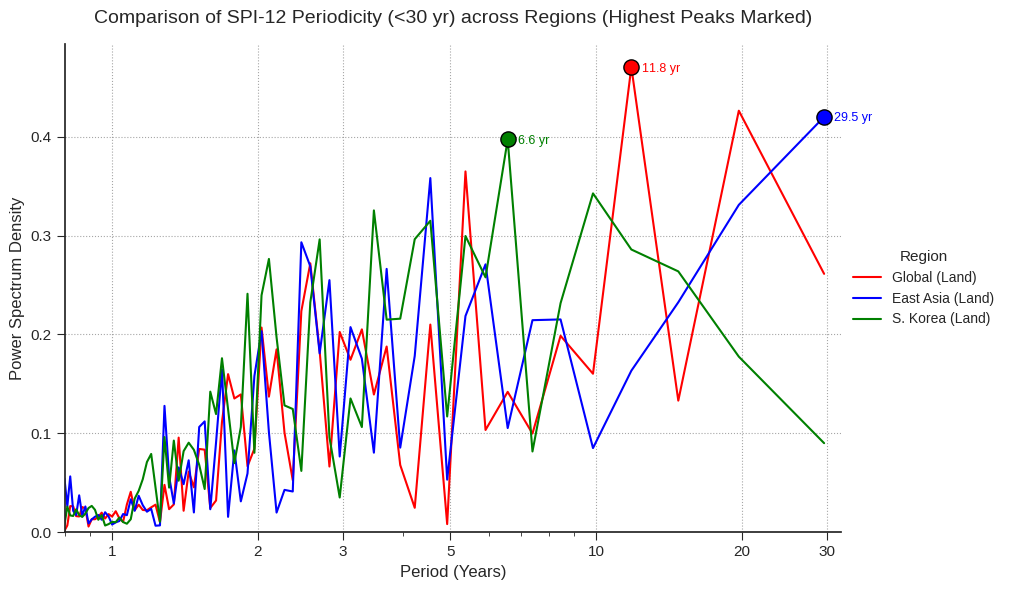

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 이전 단계에서 계산된 주기 분석 결과 변수 로드 가정 ---
# xf_gl, power_spectrum_gl
# xf_ea, power_spectrum_ea
# xf_kr, power_spectrum_kr
# 변수가 메모리에 있다고 가정합니다.

try:
    # (데이터 준비: 전체 스펙트럼 데이터)
    plot_data = []
    # (데이터 준비: 지역별 최고 피크 < 30년 찾기)
    peak_data = []
    period_limit = 30 # 주기 제한 (년)

    # Global
    if 'xf_gl' in locals() and xf_gl is not None and len(xf_gl) > 1:
        valid_idx = xf_gl > 0
        period_years = 1 / xf_gl[valid_idx] / 12
        power = power_spectrum_gl[valid_idx]
        for p, pow_val in zip(period_years, power):
            if p <= period_limit: # 30년 이하 주기만 추가
                plot_data.append({'Region': 'Global (Land)', 'Period (Years)': p, 'Power': pow_val})
        # 30년 이하 피크 찾기
        df_region = pd.DataFrame(plot_data).query("Region == 'Global (Land)'")
        if not df_region.empty:
            highest_peak = df_region.loc[df_region['Power'].idxmax()]
            peak_data.append(highest_peak.to_dict())

    # East Asia
    if 'xf_ea' in locals() and xf_ea is not None and len(xf_ea) > 1:
        valid_idx = xf_ea > 0
        period_years = 1 / xf_ea[valid_idx] / 12
        power = power_spectrum_ea[valid_idx]
        for p, pow_val in zip(period_years, power):
             if p <= period_limit: # 30년 이하 주기만 추가
                plot_data.append({'Region': 'East Asia (Land)', 'Period (Years)': p, 'Power': pow_val})
        # 30년 이하 피크 찾기
        df_region = pd.DataFrame(plot_data).query("Region == 'East Asia (Land)'")
        if not df_region.empty:
            highest_peak = df_region.loc[df_region['Power'].idxmax()]
            peak_data.append(highest_peak.to_dict())


    # S. Korea
    if 'xf_kr' in locals() and xf_kr is not None and len(xf_kr) > 1:
        valid_idx = xf_kr > 0
        period_years = 1 / xf_kr[valid_idx] / 12
        power = power_spectrum_kr[valid_idx]
        for p, pow_val in zip(period_years, power):
             if p <= period_limit: # 30년 이하 주기만 추가
                plot_data.append({'Region': 'S. Korea (Land)', 'Period (Years)': p, 'Power': pow_val})
        # 30년 이하 피크 찾기
        df_region = pd.DataFrame(plot_data).query("Region == 'S. Korea (Land)'")
        if not df_region.empty:
            highest_peak = df_region.loc[df_region['Power'].idxmax()]
            peak_data.append(highest_peak.to_dict())


    if not plot_data:
        print("오류: 주기성 분석 결과 변수가 정의되지 않았거나 유효 데이터가 없습니다.")
        exit()

    df_plot_periods = pd.DataFrame(plot_data)
    df_peaks = pd.DataFrame(peak_data) # 지역별 최고 피크 (<= 30년)

except NameError as e:
    print(f"오류: {e}. 이전 단계의 주기성 분석 결과 변수가 정의되지 않았습니다.")
    exit()
except Exception as e:
    print(f"데이터 준비 중 오류 발생: {e}")
    exit()

# --- 2. 시각화 (Combined Line Plot - 빨강/파랑/초록, 얇은 선, 지역별 최고 피크(<=30년) 표시 및 라벨링) ---

# !!! 색상 지정: 빨강, 파랑, 초록 !!!
custom_palette = {
    'Global (Land)': 'red',
    'East Asia (Land)': 'blue',
    'S. Korea (Land)': 'green'
}

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-ticks')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# !!! lineplot: 선 굵기(linewidth) 조정 !!!
ax = sns.lineplot(
    data=df_plot_periods, # 30년 이하 데이터만 사용
    x='Period (Years)', y='Power', hue='Region',
    palette=custom_palette,
    linewidth=1.5 # <-- 선 굵기 얇게 유지
)

# !!! scatterplot & text: 각 지역별 최고 피크(<=30년) 표시 및 라벨링 !!!
for index, peak in df_peaks.iterrows():
    region = peak['Region']
    period = peak['Period (Years)']
    power = peak['Power']
    color = custom_palette[region]

    # 마커 표시
    ax.scatter(period, power, color=color, s=120, edgecolor='black', marker='o', zorder=5)
    # 텍스트 라벨 표시
    ax.text(period * 1.05, power, f'{period:.1f} yr',
            color=color, fontsize=9, verticalalignment='center_baseline')


# X축 로그 스케일 및 눈금 설정 (30년까지만 표시)
ax.set_xscale('log')
# X축 틱을 1, 2, 3, 5, 10, 20, 30 으로 조정
x_ticks = [1, 2, 3, 5, 10, 20, 30]
ax.set_xticks(ticks=x_ticks, minor=False)
ax.set_xticklabels(x_ticks)
ax.tick_params(axis='x', labelsize=11)
ax.set_xlabel('Period (Years)', fontsize=12)
ax.set_xlim(0.8, period_limit + 2) # X축 범위 설정 (0.8 ~ 32년)

# Y축 설정
ax.set_ylabel('Power Spectrum Density', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(bottom=0)

# 제목 및 범례
ax.set_title('Comparison of SPI-12 Periodicity (<30 yr) across Regions (Highest Peaks Marked)', fontsize=14, pad=15) # 제목 수정
ax.legend(title='Region', title_fontsize='11', fontsize='10', loc='center left', bbox_to_anchor=(1, 0.5))

# 배경 격자
ax.grid(axis='both', linestyle=':', alpha=0.7, color='gray')

# 테두리 정리
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 1]) # 범례 공간 확보
plt.show()

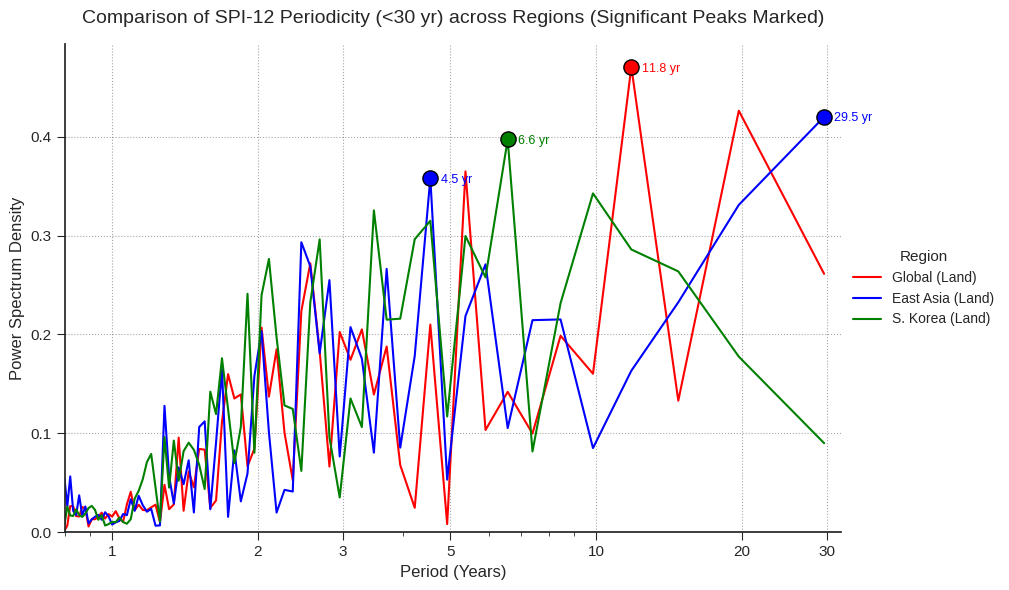

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 이전 단계에서 계산된 주기 분석 결과 변수 로드 가정 ---
# xf_gl, power_spectrum_gl
# xf_ea, power_spectrum_ea
# xf_kr, power_spectrum_kr
# 변수가 메모리에 있다고 가정합니다.

try:
    # (데이터 준비: 전체 스펙트럼 데이터)
    plot_data = []
    # (데이터 준비: 지역별 상위 피크 < 30년 찾기)
    peaks_to_plot = [] # 최종적으로 플롯할 피크 저장
    period_limit = 30 # 주기 제한 (년)
    peak_proximity_threshold = 28 # 30년에 가깝다고 판단할 기준 (년)

    # 각 지역별로 처리
    regions_data = {
        'Global (Land)': {'xf': xf_gl, 'power': power_spectrum_gl} if 'xf_gl' in locals() and xf_gl is not None else None,
        'East Asia (Land)': {'xf': xf_ea, 'power': power_spectrum_ea} if 'xf_ea' in locals() and xf_ea is not None else None,
        'S. Korea (Land)': {'xf': xf_kr, 'power': power_spectrum_kr} if 'xf_kr' in locals() and xf_kr is not None else None
    }

    for region, data in regions_data.items():
        if data is None or len(data['xf']) <= 1:
            continue # 데이터 없으면 건너뛰기

        valid_idx = data['xf'] > 0
        period_years = 1 / data['xf'][valid_idx] / 12
        power = data['power'][valid_idx]

        # 전체 스펙트럼 데이터 추가 (30년 이하)
        for p, pow_val in zip(period_years, power):
            if p <= period_limit:
                plot_data.append({'Region': region, 'Period (Years)': p, 'Power': pow_val})

        # 30년 이하 피크 찾기
        df_region_periods = pd.DataFrame({'Period (Years)': period_years, 'Power': power})
        df_region_periods_under_limit = df_region_periods[df_region_periods['Period (Years)'] <= period_limit]

        if not df_region_periods_under_limit.empty:
            # 상위 2개 피크 찾기
            top_two_peaks = df_region_periods_under_limit.nlargest(2, 'Power')

            # 1. 가장 높은 피크는 항상 추가
            highest_peak = top_two_peaks.iloc[0]
            peaks_to_plot.append({'Region': region, **highest_peak.to_dict()})

            # 2. 가장 높은 피크가 28~30년 사이이고, 두 번째 피크가 존재하면 추가
            if (highest_peak['Period (Years)'] >= peak_proximity_threshold and
                highest_peak['Period (Years)'] <= period_limit and
                len(top_two_peaks) > 1):
                second_peak = top_two_peaks.iloc[1]
                peaks_to_plot.append({'Region': region, **second_peak.to_dict()})


    if not plot_data:
        print("오류: 주기성 분석 결과 변수가 정의되지 않았거나 유효 데이터가 없습니다.")
        exit()

    df_plot_periods = pd.DataFrame(plot_data)
    df_peaks_final = pd.DataFrame(peaks_to_plot) # 플롯할 최종 피크 리스트

except NameError as e:
    print(f"오류: {e}. 이전 단계의 주기성 분석 결과 변수가 정의되지 않았습니다.")
    exit()
except Exception as e:
    print(f"데이터 준비 중 오류 발생: {e}")
    exit()

# --- 2. 시각화 (Combined Line Plot - 조건부 피크 표시) ---

# !!! 색상 지정: 빨강, 파랑, 초록 !!!
custom_palette = {
    'Global (Land)': 'red',
    'East Asia (Land)': 'blue',
    'S. Korea (Land)': 'green'
}

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-ticks')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# !!! lineplot: 선 굵기(linewidth) 조정 !!!
ax = sns.lineplot(
    data=df_plot_periods, # 30년 이하 데이터만 사용
    x='Period (Years)', y='Power', hue='Region',
    palette=custom_palette,
    linewidth=1.5 # <-- 선 굵기 얇게 유지
)

# !!! scatterplot & text: df_peaks_final 에 있는 피크만 표시 !!!
for index, peak in df_peaks_final.iterrows():
    region = peak['Region']
    period = peak['Period (Years)']
    power = peak['Power']
    color = custom_palette[region]

    # 마커 표시
    ax.scatter(period, power, color=color, s=120, edgecolor='black', marker='o', zorder=5)
    # 텍스트 라벨 표시
    ax.text(period * 1.05, power, f'{period:.1f} yr',
            color=color, fontsize=9, verticalalignment='center_baseline')


# X축 로그 스케일 및 눈금 설정 (30년까지만 표시)
ax.set_xscale('log')
x_ticks = [1, 2, 3, 5, 10, 20, 30]
ax.set_xticks(ticks=x_ticks, minor=False)
ax.set_xticklabels(x_ticks)
ax.tick_params(axis='x', labelsize=11)
ax.set_xlabel('Period (Years)', fontsize=12)
ax.set_xlim(0.8, period_limit + 2) # X축 범위 설정 (0.8 ~ 32년)

# Y축 설정
ax.set_ylabel('Power Spectrum Density', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(bottom=0)

# 제목 및 범례
ax.set_title('Comparison of SPI-12 Periodicity (<30 yr) across Regions (Significant Peaks Marked)', fontsize=14, pad=15) # 제목 수정
ax.legend(title='Region', title_fontsize='11', fontsize='10', loc='center left', bbox_to_anchor=(1, 0.5))

# 배경 격자
ax.grid(axis='both', linestyle=':', alpha=0.7, color='gray')

# 테두리 정리
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 1]) # 범례 공간 확보
plt.show()

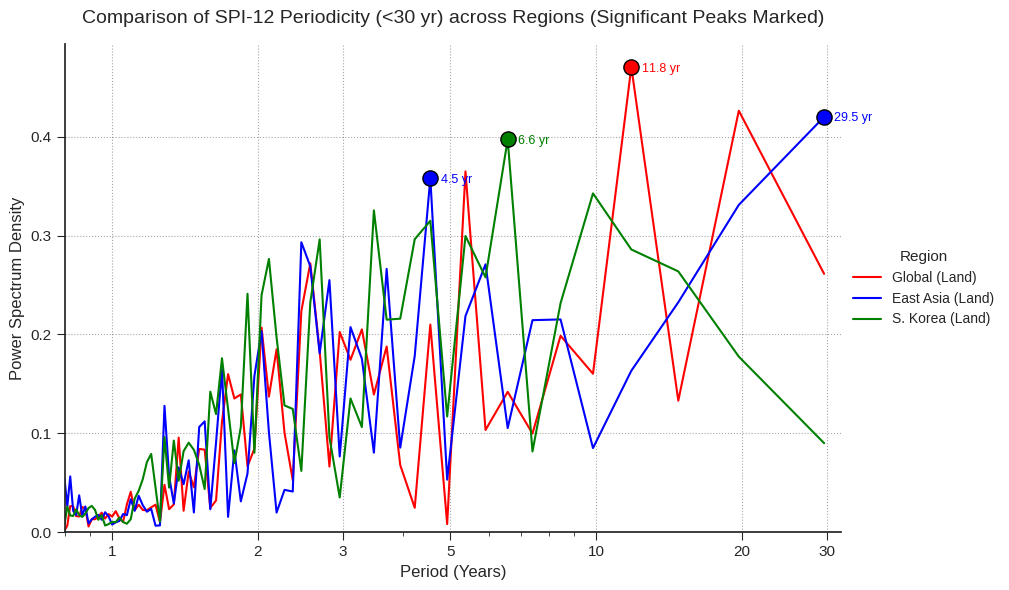

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 이전 단계에서 계산된 주기 분석 결과 변수 로드 가정 ---
# xf_gl, power_spectrum_gl
# xf_ea, power_spectrum_ea
# xf_kr, power_spectrum_kr
# 변수가 메모리에 있다고 가정합니다.

try:
    # (데이터 준비: 전체 스펙트럼 데이터)
    plot_data = []
    # (데이터 준비: 지역별 상위 피크 < 30년 찾기)
    peaks_to_plot = [] # 최종적으로 플롯할 피크 저장
    period_limit = 30 # 주기 제한 (년)
    peak_proximity_threshold = 28 # 30년에 가깝다고 판단할 기준 (년)

    # 각 지역별로 처리
    regions_data = {
        'Global (Land)': {'xf': xf_gl, 'power': power_spectrum_gl} if 'xf_gl' in locals() and xf_gl is not None else None,
        'East Asia (Land)': {'xf': xf_ea, 'power': power_spectrum_ea} if 'xf_ea' in locals() and xf_ea is not None else None,
        'S. Korea (Land)': {'xf': xf_kr, 'power': power_spectrum_kr} if 'xf_kr' in locals() and xf_kr is not None else None
    }

    for region, data in regions_data.items():
        if data is None or len(data['xf']) <= 1:
            continue # 데이터 없으면 건너뛰기

        valid_idx = data['xf'] > 0
        period_years = 1 / data['xf'][valid_idx] / 12
        power = data['power'][valid_idx]

        # 전체 스펙트럼 데이터 추가 (30년 이하)
        for p, pow_val in zip(period_years, power):
            if p <= period_limit:
                plot_data.append({'Region': region, 'Period (Years)': p, 'Power': pow_val})

        # 30년 이하 피크 찾기
        df_region_periods = pd.DataFrame({'Period (Years)': period_years, 'Power': power})
        df_region_periods_under_limit = df_region_periods[df_region_periods['Period (Years)'] <= period_limit]

        if not df_region_periods_under_limit.empty:
            # 상위 2개 피크 찾기
            top_two_peaks = df_region_periods_under_limit.nlargest(2, 'Power')

            # 1. 가장 높은 피크는 항상 추가
            highest_peak = top_two_peaks.iloc[0]
            peaks_to_plot.append({'Region': region, **highest_peak.to_dict()})

            # 2. 가장 높은 피크가 28~30년 사이이고, 두 번째 피크가 존재하면 추가
            if (highest_peak['Period (Years)'] >= peak_proximity_threshold and
                highest_peak['Period (Years)'] <= period_limit and
                len(top_two_peaks) > 1):
                second_peak = top_two_peaks.iloc[1]
                peaks_to_plot.append({'Region': region, **second_peak.to_dict()})


    if not plot_data:
        print("오류: 주기성 분석 결과 변수가 정의되지 않았거나 유효 데이터가 없습니다.")
        exit()

    df_plot_periods = pd.DataFrame(plot_data)
    df_peaks_final = pd.DataFrame(peaks_to_plot) # 플롯할 최종 피크 리스트

except NameError as e:
    print(f"오류: {e}. 이전 단계의 주기성 분석 결과 변수가 정의되지 않았습니다.")
    exit()
except Exception as e:
    print(f"데이터 준비 중 오류 발생: {e}")
    exit()

# --- 2. 시각화 (Combined Line Plot - 조건부 피크 표시) ---

# !!! 색상 지정: 빨강, 파랑, 초록 !!!
custom_palette = {
    'Global (Land)': 'red',
    'East Asia (Land)': 'blue',
    'S. Korea (Land)': 'green'
}

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-ticks')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# !!! lineplot: 선 굵기(linewidth) 조정 !!!
ax = sns.lineplot(
    data=df_plot_periods, # 30년 이하 데이터만 사용
    x='Period (Years)', y='Power', hue='Region',
    palette=custom_palette,
    linewidth=1.5 # <-- 선 굵기 얇게 유지
)

# !!! scatterplot & text: df_peaks_final 에 있는 피크만 표시 !!!
for index, peak in df_peaks_final.iterrows():
    region = peak['Region']
    period = peak['Period (Years)']
    power = peak['Power']
    color = custom_palette[region]

    # 마커 표시
    ax.scatter(period, power, color=color, s=120, edgecolor='black', marker='o', zorder=5)
    # 텍스트 라벨 표시
    ax.text(period * 1.05, power, f'{period:.1f} yr',
            color=color, fontsize=9, verticalalignment='center_baseline')


# X축 로그 스케일 및 눈금 설정 (30년까지만 표시)
ax.set_xscale('log')
x_ticks = [1, 2, 3, 5, 10, 20, 30]
ax.set_xticks(ticks=x_ticks, minor=False)
ax.set_xticklabels(x_ticks)
ax.tick_params(axis='x', labelsize=11)
ax.set_xlabel('Period (Years)', fontsize=12)
ax.set_xlim(0.8, period_limit + 2) # X축 범위 설정 (0.8 ~ 32년)

# Y축 설정
ax.set_ylabel('Power Spectrum Density', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(bottom=0)

# 제목 및 범례
ax.set_title('Comparison of SPI-12 Periodicity (<30 yr) across Regions (Significant Peaks Marked)', fontsize=14, pad=15) # 제목 수정
ax.legend(title='Region', title_fontsize='11', fontsize='10', loc='center left', bbox_to_anchor=(1, 0.5))

# 배경 격자
ax.grid(axis='both', linestyle=':', alpha=0.7, color='gray')

# 테두리 정리
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 1]) # 범례 공간 확보
plt.show()

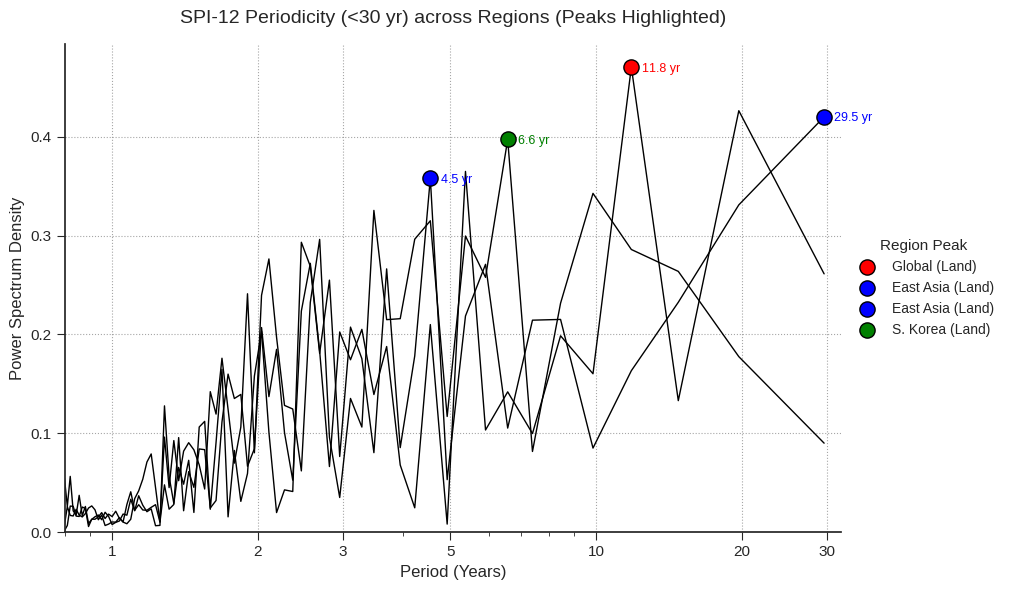

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 이전 단계에서 계산된 주기 분석 결과 변수 로드 가정 ---
# xf_gl, power_spectrum_gl
# xf_ea, power_spectrum_ea
# xf_kr, power_spectrum_kr
# df_peaks_final (플롯할 피크 데이터프레임)
# 변수가 메모리에 있다고 가정합니다.

try:
    # (데이터 준비: 전체 스펙트럼 데이터 - 이전과 동일)
    plot_data = []
    period_limit = 30 # 주기 제한 (년)

    # Global
    if 'xf_gl' in locals() and xf_gl is not None and len(xf_gl) > 1:
        valid_idx = xf_gl > 0
        period_years = 1 / xf_gl[valid_idx] / 12
        power = power_spectrum_gl[valid_idx]
        for p, pow_val in zip(period_years, power):
            if p <= period_limit:
                plot_data.append({'Region': 'Global (Land)', 'Period (Years)': p, 'Power': pow_val})

    # East Asia
    if 'xf_ea' in locals() and xf_ea is not None and len(xf_ea) > 1:
        valid_idx = xf_ea > 0
        period_years = 1 / xf_ea[valid_idx] / 12
        power = power_spectrum_ea[valid_idx]
        for p, pow_val in zip(period_years, power):
             if p <= period_limit:
                plot_data.append({'Region': 'East Asia (Land)', 'Period (Years)': p, 'Power': pow_val})

    # S. Korea
    if 'xf_kr' in locals() and xf_kr is not None and len(xf_kr) > 1:
        valid_idx = xf_kr > 0
        period_years = 1 / xf_kr[valid_idx] / 12
        power = power_spectrum_kr[valid_idx]
        for p, pow_val in zip(period_years, power):
             if p <= period_limit:
                plot_data.append({'Region': 'S. Korea (Land)', 'Period (Years)': p, 'Power': pow_val})

    if not plot_data:
        print("Error: Periodicity analysis result variables are not defined or empty.")
        exit()

    df_plot_periods = pd.DataFrame(plot_data)
    # df_peaks_final 변수는 이전 코드에서 이미 생성되었다고 가정

except NameError as e:
    print(f"Error: {e}. Periodicity variables from previous steps are not defined.")
    exit()
except Exception as e:
    print(f"Error during data preparation: {e}")
    exit()

# --- 2. 시각화 (기본 검은선 + 피크만 컬러 마커) ---

# !!! 색상 지정: 피크 강조용 !!!
custom_peak_palette = {
    'Global (Land)': 'red',
    'East Asia (Land)': 'blue',
    'S. Korea (Land)': 'green'
}

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-ticks')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# !!! lineplot: 모든 선을 검은색(또는 회색)으로, 범례 없이 그리기 !!!
ax = sns.lineplot(
    data=df_plot_periods, # 30년 이하 데이터
    x='Period (Years)', y='Power', hue='Region',
    palette=['black'] * 3, # 모든 선을 검은색으로
    linewidth=1.0,        # 선을 더 얇게
    legend=False          # 기본 범례 숨김
)

# !!! scatterplot & text: df_peaks_final 에 있는 피크만 지역별 색상으로 표시 !!!
for index, peak in df_peaks_final.iterrows():
    region = peak['Region']
    period = peak['Period (Years)']
    power = peak['Power']
    color = custom_peak_palette[region] # 지역별 피크 색상

    # 마커 표시
    ax.scatter(period, power, color=color, s=120, edgecolor='black', marker='o', zorder=5,
               label=f"{region} Peak") # 범례용 라벨 추가
    # 텍스트 라벨 표시
    ax.text(period * 1.05, power, f'{period:.1f} yr',
            color=color, fontsize=9, verticalalignment='center_baseline')


# X축 로그 스케일 및 눈금 설정 (30년까지만 표시)
ax.set_xscale('log')
x_ticks = [1, 2, 3, 5, 10, 20, 30]
ax.set_xticks(ticks=x_ticks, minor=False)
ax.set_xticklabels(x_ticks)
ax.tick_params(axis='x', labelsize=11)
ax.set_xlabel('Period (Years)', fontsize=12)
ax.set_xlim(0.8, period_limit + 2) # X축 범위 설정 (0.8 ~ 32년)

# Y축 설정
ax.set_ylabel('Power Spectrum Density', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(bottom=0)

# 제목 및 범례 (마커에 대한 범례만 표시)
ax.set_title('SPI-12 Periodicity (<30 yr) across Regions (Peaks Highlighted)', fontsize=14, pad=15) # 제목 수정
# 핸들과 라벨을 가져와서 마커에 대한 범례만 생성
handles, labels = ax.get_legend_handles_labels()
# scatter plot에서 생성된 라벨만 필터링 (선 라벨 제외)
peak_handles = [h for h, l in zip(handles, labels) if "Peak" in l]
peak_labels = [l.replace(" Peak", "") for l in labels if "Peak" in l] # 라벨 정리
ax.legend(peak_handles, peak_labels, title='Region Peak', title_fontsize='11', fontsize='10', loc='center left', bbox_to_anchor=(1, 0.5))


# 배경 격자
ax.grid(axis='both', linestyle=':', alpha=0.7, color='gray')

# 테두리 정리
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 1]) # 범례 공간 확보
plt.show()

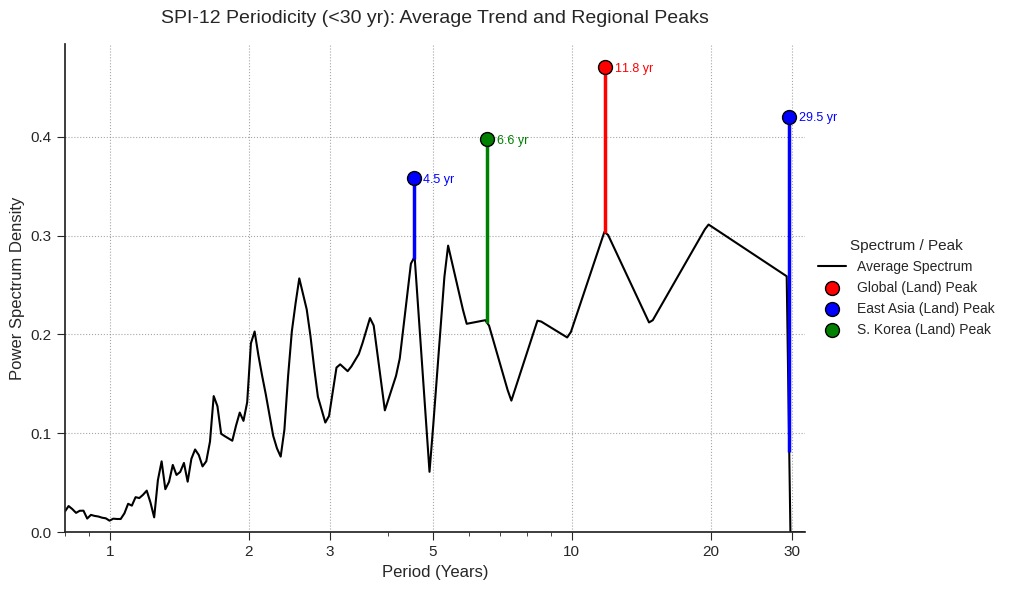

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

# --- 1. 이전 단계에서 계산된 주기 분석 결과 변수 로드 가정 ---
# df_plot_periods (전체 스펙트럼 데이터)
# df_peaks_final (플롯할 피크 데이터)
# 변수가 메모리에 있다고 가정합니다.

try:
    if 'df_plot_periods' not in locals() or 'df_peaks_final' not in locals():
        raise NameError("Required DataFrames (df_plot_periods, df_peaks_final) not found.")

    # --- 2. 평균 스펙트럼 계산 ---
    # 로그 스케일 X축에 맞춰 보간하기 위해 로그 주기 값 사용
    df_plot_periods['Log Period'] = np.log10(df_plot_periods['Period (Years)'])

    # 보간을 위한 공통 로그 주기 축 생성 (0.8 ~ 32년 범위, 200개 지점)
    common_log_periods = np.linspace(np.log10(0.8), np.log10(32), 200)
    common_periods = 10**common_log_periods

    interpolated_data = {'Period (Years)': common_periods}
    regions = df_plot_periods['Region'].unique()

    for region in regions:
        region_data = df_plot_periods[df_plot_periods['Region'] == region].sort_values('Log Period')
        # interp1d 함수로 보간 함수 생성 (선형 보간, 경계값 처리)
        interp_func = interp1d(region_data['Log Period'], region_data['Power'],
                               bounds_error=False, fill_value=0) # 범위 밖은 0으로 채움
        interpolated_data[region] = interp_func(common_log_periods)

    df_interpolated = pd.DataFrame(interpolated_data)

    # 평균 스펙트럼 계산
    df_interpolated['Average Power'] = df_interpolated[regions].mean(axis=1)

except NameError as e:
    print(f"Error: {e}. Required variables from previous steps are not defined.")
    exit()
except Exception as e:
    print(f"Error during data preparation: {e}")
    exit()

# --- 3. 시각화 (평균 검은선 + 지역별 피크 막대 강조) ---

# 색상 지정
custom_palette = {
    'Global (Land)': 'red',
    'East Asia (Land)': 'blue',
    'S. Korea (Land)': 'green'
}

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-ticks')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))
ax = plt.gca() # 현재 축 가져오기

# !!! 1. 평균 스펙트럼을 검은색 실선으로 그리기 !!!
ax.plot(df_interpolated['Period (Years)'], df_interpolated['Average Power'],
        color='black', linewidth=1.5, label='Average Spectrum')

# !!! 2. 각 지역별 피크를 평균선에서 뻗어나가는 막대(수직선)로 표시 !!!
for index, peak in df_peaks_final.iterrows():
    region = peak['Region']
    period = peak['Period (Years)']
    power = peak['Power']
    color = custom_palette[region]

    # 해당 주기 위치에서 평균 파워 값 찾기 (보간된 값 사용)
    avg_power_at_peak = np.interp(np.log10(period), common_log_periods, df_interpolated['Average Power'])

    # 평균선부터 피크까지 수직선 그리기
    ax.vlines(x=period, ymin=avg_power_at_peak, ymax=power, color=color, linewidth=2.5, zorder=4)

    # 피크 지점에 마커 표시
    ax.scatter(period, power, color=color, s=100, edgecolor='black', marker='o', zorder=5, label=f"{region} Peak")
    # 텍스트 라벨 표시
    ax.text(period * 1.05, power, f'{period:.1f} yr',
            color=color, fontsize=9, verticalalignment='center_baseline')


# X축 로그 스케일 및 눈금 설정 (30년까지만 표시)
ax.set_xscale('log')
x_ticks = [1, 2, 3, 5, 10, 20, 30]
ax.set_xticks(ticks=x_ticks, minor=False)
ax.set_xticklabels(x_ticks)
ax.tick_params(axis='x', labelsize=11)
ax.set_xlabel('Period (Years)', fontsize=12)
ax.set_xlim(0.8, 32) # X축 범위 설정

# Y축 설정
ax.set_ylabel('Power Spectrum Density', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(bottom=0)

# 제목 및 범례 조정
ax.set_title('SPI-12 Periodicity (<30 yr): Average Trend and Regional Peaks', fontsize=14, pad=15) # 제목 수정
# 범례 핸들/라벨 재구성 (평균선 + 각 지역 피크)
handles, labels = ax.get_legend_handles_labels()
# 중복 제거 및 순서 조정
unique_labels = list(dict.fromkeys(labels))
unique_handles = [handles[labels.index(lbl)] for lbl in unique_labels]
ax.legend(unique_handles, unique_labels, title='Spectrum / Peak', title_fontsize='11', fontsize='10', loc='center left', bbox_to_anchor=(1, 0.5))


# 배경 격자
ax.grid(axis='both', linestyle=':', alpha=0.7, color='gray')

# 테두리 정리
sns.despine()

plt.tight_layout(rect=[0, 0, 0.85, 1]) # 범례 공간 확보
plt.show()

In [ ]:
# --- [오류 해결] Q4 분석을 위한 데이터 로드 ---
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import warnings

# 경고 메시지 숨기기
warnings.filterwarnings('ignore')

# 1. 기본 경로 및 파일명 설정 (이전과 동일)
BASE_DATA_DIR = '/content/drive/MyDrive/MIDTERM/ERA5_data/'
Q2_OUTPUT_FILE = BASE_DATA_DIR + 'Q2_SPI9_global_1965-2024.nc'
Q3_OUTPUT_FILE = BASE_DATA_DIR + 'Q3_SPI9_global_1965-2024.nc'
TIME_DIM = 'valid_time'

try:
    # 2. 이전 단계에서 저장한 Q2, Q3 분석 결과(.nc 파일) 로드
    print("Q2 및 Q3 분석 결과 파일을 로드합니다...")
    ds_spi_q2 = xr.open_dataset(Q2_OUTPUT_FILE)
    ds_spi_q3 = xr.open_dataset(Q3_OUTPUT_FILE)
    print("  - 데이터 로드 완료.")

    # --- [재실행] Q4 최종 분석: SPI 차이 지도 생성 ---
    print("Q4 최종 분석: 기준 기간에 따른 SPI 차이 지도 생성을 시작합니다...")

    # 3. Q2, Q3 데이터에서 1994년 8월 시점 데이터 추출
    da_spi_aug1994_q2 = ds_spi_q2['spi'].sel({TIME_DIM: '1994-08-01'}, method='nearest')
    da_spi_aug1994_q3 = ds_spi_q3['spi'].sel({TIME_DIM: '1994-08-01'}, method='nearest')
    print("  - Q2 및 Q3의 1994년 8월 SPI 데이터 준비 완료.")

    # 4. SPI 차이 계산 (Q3 기준 - Q2 기준)
    da_spi_diff = da_spi_aug1994_q3 - da_spi_aug1994_q2
    da_spi_diff.attrs['long_name'] = 'SPI Difference (Ref_1965-1994 minus Ref_1985-2014)'
    da_spi_diff.attrs['units'] = 'z-score diff.'
    print("  - SPI 차이 계산 완료.")

    # 5. 차이 지도 시각화
    plt.figure(figsize=(15, 7))
    cmap = plt.get_cmap('RdBu', 20)
    cbar_kwargs = {
        'label': 'SPI Difference (z-score)',
        'orientation': 'vertical',
        'shrink': 0.8,
        'pad': 0.05,
        'extend': 'both'
    }

    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    da_spi_diff.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        cbar_kwargs=cbar_kwargs,
        vmin=-1.5,
        vmax=1.5
    )

    ax.set_title('Q4: SPI Difference Map (Aug 1994) due to Reference Period Change', fontsize=14)
    ax.set_global()
    ax.set_ylim([-60, 90])

    # 6. 파일로 저장
    output_filename_q4_diff_map = BASE_DATA_DIR + 'Q4_SPI9_Diff_Map_Aug1994.png'
    plt.savefig(output_filename_q4_diff_map, dpi=300, bbox_inches='tight')

    print(f"\\n[산출물 Q4] SPI 차이 지도를 '{output_filename_q4_diff_map}' 파일로 저장했습니다.")
    plt.show()

except FileNotFoundError as e:
    print(f"치명적 오류: 필요한 분석 파일이 없습니다: {e}")
    print("Q2 및 Q3 분석을 먼저 실행하여 결과 파일(.nc)을 저장했는지 확인하십시오.")
except Exception as e:
    print(f"분석 중 오류가 발생했습니다: {e}")

Q2 및 Q3 분석 결과 파일을 로드합니다...
치명적 오류: 필요한 분석 파일이 없습니다: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/MIDTERM/ERA5_data/Q2_SPI9_global_1965-2024.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Q2 및 Q3 분석을 먼저 실행하여 결과 파일(.nc)을 저장했는지 확인하십시오.


In [ ]:
# --- 0. 필수 라이브러리 및 환경 설정 ---
import xarray as xr
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings

# R 및 rpy2 관련 라이브러리
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.vectors import FloatVector
from rpy2.robjects import pandas2ri

# 경고 메시지 숨기기
warnings.filterwarnings('ignore')

print("--- 0단계: 환경 설정 시작 ---")

# --- 1. 경로 및 변수 설정 ---
BASE_DATA_DIR = '/content/drive/MyDrive/MIDTERM/ERA5_data/'
PRECIP_FILE = BASE_DATA_DIR + 'total_precipitation_ERA5_globe_1965-2024_regridded.nc'
LSM_FILE = BASE_DATA_DIR + 'land_sea_mask_ERA5.nc'
Q2_OUTPUT_FILE = BASE_DATA_DIR + 'Q2_SPI9_global_1965-2024.nc'
Q3_OUTPUT_FILE = BASE_DATA_DIR + 'Q3_SPI9_global_1965-2024.nc'

VAR_PRECIP = 'tp'
VAR_LSM = 'lsm'
TIME_DIM = 'valid_time'
LAT_DIM = 'latitude'
LON_DIM = 'longitude'

# 기준 기간 정의
Q2_REF_START = '1985-01-01'
Q2_REF_END = '2014-12-31'
Q3_REF_START = '1965-01-01'
Q3_REF_END = '1994-12-31'

print("  - 경로 및 변수 설정 완료.")

# --- 2. 데이터 로드 및 전처리 ---
try:
    ds_precip_all = xr.open_dataset(PRECIP_FILE)
    ds_lsm_all = xr.open_dataset(LSM_FILE)

    da_lsm_regridded = ds_lsm_all.squeeze(drop=True).interp(
        {LAT_DIM: ds_precip_all, LON_DIM: ds_precip_all},
        method='nearest'
    )

    da_precip_m_day = ds_precip_all
    days_in_month = da_precip_m_day.dt.days_in_month
    da_precip_mm_month = da_precip_m_day * days_in_month * 1000

    tp_vals_mm = da_precip_mm_month.values
    time_coords = ds_precip_all.values
    lsm_vals = da_lsm_regridded.values

    print("  - 데이터 로드 및 전처리 완료.")

except Exception as e:
    print(f"오류: 데이터 로드 실패. 파일 경로를 확인하십시오: {e}")
    raise

# --- 3. R 환경 및 SPI 래퍼 함수 정의 ---
try:
    %load_ext rpy2.ipython
    pandas2ri.activate()
    speiR = importr("SPEI")

    def spi(P, scale=1, distribution="Gamma", fit="ub-pwm", na_rm=False, ref_idx=None):
        P_arr = np.asarray(P, float).ravel()
        n = P_arr.size
        def _base_kwargs(data_vector):
            return {'data': data_vector, 'scale': int(scale), 'distribution': distribution, 'fit': fit, 'na_rm': bool(na_rm), 'verbose': False}
        if ref_idx is not None:
            calib_mask = np.zeros(n, dtype=bool)
            calib_mask[ref_idx] = True
            P_fit = P_arr.copy(); P_fit[~calib_mask] = np.nan
            res_fit = speiR.spi(**_base_kwargs(FloatVector(P_fit)), na_rm=True)
            coeff_R = res_fit.rx2('coefficients')
            res = speiR.spi(**_base_kwargs(FloatVector(P_arr)), params=coeff_R)
        else:
            res = speiR.spi(**_base_kwargs(FloatVector(P_arr)))
        return {'fitted': np.array(res.rx2('fitted'))}

    print("  - R/rpy2 및 SPI 래퍼 함수 'spi()' 정의 완료.")

except Exception as e:
    print(f"오류: R 환경 설정 실패. R 패키지 설치를 확인하십시오: {e}")
    raise

print("--- 0단계: 환경 설정 완료 ---")

# --- 4. Q2 SPI-9 계산 및 저장 (시간 소요) ---
print("\n--- 4단계: Q2 SPI-9 계산 시작 (기준: 1985-2014) ---")
ref_idx_q2 = np.where((time_coords >= np.datetime64(Q2_REF_START)) & (time_coords <= np.datetime64(Q2_REF_END)))
spi_vals_q2 = np.empty(tp_vals_mm.shape); spi_vals_q2[:] = np.nan
n_lats, n_lons = lsm_vals.shape

for j in tqdm(range(n_lats), desc="Q2 Latitude"):
    for i in range(n_lons):
        if lsm_vals[j, i] > 0.5:
            spi_vals_q2[:, j, i] = spi(tp_vals_mm[:, j, i], scale=9, ref_idx=ref_idx_q2)['fitted']

ds_spi_q2 = xr.Dataset(
    {'spi': ((TIME_DIM, LAT_DIM, LON_DIM), spi_vals_q2.astype('float32'))},
    coords={TIME_DIM: time_coords, LAT_DIM: ds_precip_all, LON_DIM: ds_precip_all}
)
ds_spi_q2.to_netcdf(Q2_OUTPUT_FILE)
print(f"  - Q2 SPI 데이터 계산 완료. '{Q2_OUTPUT_FILE}'에 저장되었습니다.")

# --- 5. Q3 SPI-9 계산 및 저장 (시간 소요) ---
print("\n--- 5단계: Q3 SPI-9 계산 시작 (기준: 1965-1994) ---")
ref_idx_q3 = np.where((time_coords >= np.datetime64(Q3_REF_START)) & (time_coords <= np.datetime64(Q3_REF_END)))
spi_vals_q3 = np.empty(tp_vals_mm.shape); spi_vals_q3[:] = np.nan

for j in tqdm(range(n_lats), desc="Q3 Latitude"):
    for i in range(n_lons):
        if lsm_vals[j, i] > 0.5:
            spi_vals_q3[:, j, i] = spi(tp_vals_mm[:, j, i], scale=9, ref_idx=ref_idx_q3)['fitted']

ds_spi_q3 = xr.Dataset(
    {'spi': ((TIME_DIM, LAT_DIM, LON_DIM), spi_vals_q3.astype('float32'))},
    coords={TIME_DIM: time_coords, LAT_DIM: ds_precip_all, LON_DIM: ds_precip_all}
)
ds_spi_q3.to_netcdf(Q3_OUTPUT_FILE)
print(f"  - Q3 SPI 데이터 계산 완료. '{Q3_OUTPUT_FILE}'에 저장되었습니다.")

print("\n--- 모든 계산 및 파일 생성이 완료되었습니다. ---")

--- 0단계: 환경 설정 시작 ---
  - 경로 및 변수 설정 완료.
오류: 데이터 로드 실패. 파일 경로를 확인하십시오: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/MIDTERM/ERA5_data/total_precipitation_ERA5_globe_1965-2024_regridded.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/MIDTERM/ERA5_data/total_precipitation_ERA5_globe_1965-2024_regridded.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)